In [3]:
!curl -L -o esnli_train_1.csv https://raw.githubusercontent.com/OanaMariaCamburu/e-SNLI/master/dataset/esnli_train_1.csv


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 85.9M  100 85.9M    0     0  1842k      0  0:00:47  0:00:47 --:--:-- 2456k


In [7]:
import pandas as pd

# Load full training chunk
df = pd.read_csv("esnli_train_1.csv")

# Select 800 random examples
subset = df.sample(800, random_state=42)

# Keep only the columns you need
subset = subset[["Sentence1", "Sentence2", "gold_label","Explanation_1"]]

# Rename columns
subset = subset.rename(columns={
    "Sentence1": "Premise",
    "Sentence2": "Hypothesis",
    "Explanation_1": "Explanation"
})

# Add incremental ID starting from 1
subset.insert(0, "id", range(1, len(subset) + 1))

# Save
subset.to_csv("esnli_800.csv", index=False)

subset.head()



,id,Premise,Hypothesis,gold_label,Explanation
21138,1,A woman in a blue apron cooking in a kitchen.,A woman in a pink apron sitting in a kitchen.,contradiction,The apron is either blue or pink. The woman ca...
250485,2,This young man smiles as he discovers a horses...,The young man is at school taking a math test.,contradiction,The young man is either at school or in the sand.
186188,3,Three young boys playing with the mud on a beach.,Three young girls are at the beach.,contradiction,Boys and girls are different people.
117856,4,A lock box on a pole with the keys in it.,A blue lock box attached to the side of the h...,contradiction,A pole is not the same as a house.
95555,5,A man pours water on plants in a vast field of...,A man waters plants,entailment,A man gave the plants water.


**Gemini**

In [10]:
!pip install google-cloud-aiplatform


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 700.0 kB/s eta 0:00:0031m2.3 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 kB 2.3 MB/s eta 0:00:00
  Using cached tenacity-9.1.2-py3-none-any.whl.metadata (1.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 4.0 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.7/173.7 kB 4.0 MB/s eta 0:00:005.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.1/223.1 kB 4.1 MB/s eta 0:00:005.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.3/259.3 kB 3.4 MB/s eta 0:00:000:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.2/397.2 kB 4.1 MB/s eta 0:00:00 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.0/299.0 kB 3.5 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.0/262.0 kB 3.5 MB/s eta 0:00:000:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 k

In [11]:
import os
import json
import pathlib
import pandas as pd
from tqdm import tqdm
import csv
import time

# ---------------------------
# GOOGLE AUTHENTICATION (LOCAL)
# ---------------------------
# 🔥 Change this path to where your JSON file is stored:
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"

assert os.path.exists(SERVICE_ACCOUNT_PATH), f"❌ JSON file not found: {SERVICE_ACCOUNT_PATH}"

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH
print("✅ Google service account loaded from:", SERVICE_ACCOUNT_PATH)


# ---------------------------
# INITIALIZE GEMINI (Vertex AI)
# ---------------------------
from vertexai.generative_models import GenerativeModel
import vertexai

vertexai.init(project="llm-reasoning-475315", location="us-central1")
model = GenerativeModel("gemini-2.5-flash")

print("✅ Gemini model initialized.")


# ---------------------------
# LOAD INPUT CSV (LOCAL)
# ---------------------------
# 🔥 Change this to YOUR local CSV path:
INPUT_PATH = "esnli_800_with_perturbations.csv"

assert os.path.exists(INPUT_PATH), f"❌ Input CSV not found: {INPUT_PATH}"

df = pd.read_csv(INPUT_PATH)
print("Loaded", len(df), "rows.")


# ---------------------------
# PROMPT TEMPLATE
# ---------------------------
TEMPLATE = """
You are an expert NLI reasoning engine. Your task is to classify the logical relationship between a Premise and a Hypothesis.

### INSTRUCTIONS (STRICT):

1. **FUNDAMENTAL RULE**:
   - You must assume the Premise is an indisputable fact in a closed logical world.
   - **Do NOT** evaluate realism. Base your reasoning ONLY on the logical consequences of the premise being true.

2. Determine the correct label:
   - **ENTAILMENT**: The hypothesis MUST be true given the premise.
   - **CONTRADICTION**: The hypothesis CANNOT be true given the premise.
   - **NEUTRAL**: The hypothesis MIGHT be true, but is not guaranteed.
     *(Self-Check: If a logically consistent scenario exists where Premise=True and Hypothesis=False, choose NEUTRAL.)*

3. Write a concise "Chain of Thought" (1–3 sentences).
   - **Focus on Definitions:** Analyze the concepts abstractly (e.g., "X implies Y"). Do NOT retell the story or describe the specific scene.
   - **Deterministic Language:** Avoid hedging ("likely", "possibly", "could"). Use categorical terms ("guarantees", "excludes", "does not ensure").
   - **No Meta-Talk:** Do NOT use phrases like "The premise states..." or "According to the text...".

### EXAMPLES (Imitate this exact abstract style):

Premise: A soccer player is running across the field.
Hypothesis: A person is moving.
Chain of Thought: The category "soccer player" falls under the category "person", and "running" is a specific type of "movement". Therefore, the premise logically entails the hypothesis.
Final Answer: ENTAILMENT

Premise: A black dog is sleeping on the couch.
Hypothesis: A dog is running outside.
Chain of Thought: The states of "sleeping" and "running" are mutually exclusive; an entity cannot perform both simultaneously. The premise excludes the hypothesis.
Final Answer: CONTRADICTION

Premise: A woman is buying vegetables at the market.
Hypothesis: The woman is preparing dinner.
Chain of Thought: The act of "buying vegetables" does not logically compel "preparing dinner"; acquisition is distinct from preparation. Since the outcome is not guaranteed, the relationship is inconclusive.
Final Answer: NEUTRAL

---

Now solve this one:

Premise: {premise}
Hypothesis: {hypothesis}
Chain of Thought:
"""


# ---------------------------
# FUNCTION TO GET LLM RATIONALE
# ---------------------------
def get_rationale(premise, hypothesis):
    prompt = TEMPLATE.format(premise=premise, hypothesis=hypothesis)
    try:
        response = model.generate_content(prompt)
        return response.text.strip()
    except Exception as e:
        print("ERROR:", e)
        return "ERROR"


# ---------------------------
# PREPARE OUTPUT FILE
# ---------------------------
OUTPUT_PATH = "esnli_gemini_rationales.csv"

with open(OUTPUT_PATH, "w", newline='', encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "id",
        "rationale_original",
        "rationale_pert1",
        "rationale_pert2",
        "rationale_pert3"
    ])

print("🚀 Output file initialized:", OUTPUT_PATH)


# ---------------------------
# PROCESS ROWS ONE BY ONE
# ---------------------------
with open(OUTPUT_PATH, "a", newline='', encoding="utf-8") as f:
    writer = csv.writer(f)

    for _, row in tqdm(df.iterrows(), total=len(df)):
        pid = row["id"]
        premise = row["Premise"]

        h0 = row["Hypothesis"]
        h1 = row["perturbation_1_lexical"]
        h2 = row["perturbation_2_syntactic"]
        h3 = row["perturbation_3_pragmatic"]

        rationale_0 = get_rationale(premise, h0)
        rationale_1 = get_rationale(premise, h1)
        rationale_2 = get_rationale(premise, h2)
        rationale_3 = get_rationale(premise, h3)

        writer.writerow([pid, rationale_0, rationale_1, rationale_2, rationale_3])
        f.flush()

print("✅ DONE — all rows written.")
print("📁 Output saved locally at:", OUTPUT_PATH)


✅ Google service account loaded from: llm-reasoning-475315-b0391b898b58.json


/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


✅ Gemini model initialized.
Loaded 800 rows.
🚀 Output file initialized: esnli_gemini_rationales.csv


100%|███████████████████████████████████████| 800/800 [4:12:22<00:00, 18.93s/it]

✅ DONE — all rows written.
📁 Output saved locally at: esnli_gemini_rationales.csv


**extract final answers of gemini**

In [ ]:
import pandas as pd

# Load results
df = pd.read_csv("esnli_800_perturbation_consistency_results.csv")

# Convert columns to boolean safely (in case they were saved as strings)
for col in ["p1_meaning_preserved", "p2_meaning_preserved", "p3_meaning_preserved"]:
    df[col] = df[col].astype(str).str.lower().map({"true": True, "false": False})

# Identify rows where ANY meaning_preserved == False
df_false = df[
    (df["p1_meaning_preserved"] == False) |
    (df["p2_meaning_preserved"] == False) |
    (df["p3_meaning_preserved"] == False)
]

# Print IDs
false_ids = df_false["id"].tolist()

print("❌ IDs with at least one perturbation that does NOT preserve meaning:")
print(false_ids)

print(f"\nTotal problematic rows: {len(false_ids)}")


In [25]:
import pandas as pd

# Load results
df = pd.read_csv("esnli_800_perturbation_consistency_results.csv")

# Convert columns to boolean safely (in case they were saved as strings)
for col in ["p1_meaning_preserved", "p2_meaning_preserved", "p3_meaning_preserved"]:
    df[col] = df[col].astype(str).str.lower().map({"true": True, "false": False})

# Identify rows where ANY meaning_preserved == False
df_false = df[
    (df["p1_meaning_preserved"] == False) |
    (df["p2_meaning_preserved"] == False) |
    (df["p3_meaning_preserved"] == False)
]

# Print IDs
false_ids = df_false["id"].tolist()

print("❌ IDs with at least one perturbation that does NOT preserve meaning:")
print(false_ids)

print(f"\nTotal problematic rows: {len(false_ids)}")


❌ IDs with at least one perturbation that does NOT preserve meaning:
[3, 4, 5, 9, 40, 43, 47, 49, 57, 60, 61, 62, 72, 73, 76, 94, 96, 98, 100, 105, 113, 115, 116, 118, 121, 129, 139, 140, 145, 147, 149, 153, 155, 158, 162, 163, 166, 172, 176, 178, 192, 197, 201, 203, 216, 221, 222, 226, 233, 239, 240, 241, 244, 246, 248, 254, 257, 266, 268, 273, 278, 283, 287, 292, 293, 296, 303, 304, 309, 313, 317, 325, 331, 336, 344, 350, 354, 359, 363, 364, 380, 391, 392, 396, 398, 406, 408, 418, 419, 423, 426, 427, 428, 436, 438, 439, 440, 441, 451, 455, 464, 465, 466, 469, 471, 477, 478, 480, 482, 488, 494, 498, 515, 518, 520, 521, 522, 523, 525, 527, 528, 533, 534, 536, 537, 552, 554, 566, 571, 572, 576, 582, 585, 595, 601, 608, 621, 630, 638, 645, 651, 653, 658, 663, 669, 675, 678, 682, 686, 687, 688, 690, 696, 710, 716, 717, 730, 732, 735, 739, 750, 756, 758, 766, 773, 778, 783, 785, 787, 788, 789, 791, 792]

Total problematic rows: 173


In [97]:
import pandas as pd

# IDs to remove
ids_to_remove = [
    3, 4, 5, 9, 40, 43, 47, 49, 57, 60, 61, 62, 72, 73, 76, 94, 96, 98, 100, 
    105, 113, 115, 116, 118, 121, 129, 139, 140, 145, 147, 149, 153, 155, 158, 
    162, 163, 166, 172, 176, 178, 192, 197, 201, 203, 216, 221, 222, 226, 233, 
    239, 240, 241, 244, 246, 248, 254, 257, 266, 268, 273, 278, 283, 287, 292, 
    293, 296, 303, 304, 309, 313, 317, 325, 331, 336, 344, 350, 354, 359, 363, 
    364, 380, 391, 392, 396, 398, 406, 408, 418, 419, 423, 426, 427, 428, 436, 
    438, 439, 440, 441, 451, 455, 464, 465, 466, 469, 471, 477, 478, 480, 482, 
    488, 494, 498, 515, 518, 520, 521, 522, 523, 525, 527, 528, 533, 534, 536, 
    537, 552, 554, 566, 571, 572, 576, 582, 585, 595, 601, 608, 621, 630, 638, 
    645, 651, 653, 658, 663, 669, 675, 678, 682, 686, 687, 688, 690, 696, 710, 
    716, 717, 730, 732, 735, 739, 750, 756, 758, 766, 773, 778, 783, 785, 787, 
    788, 789, 791, 792
]

# Load original file
df = pd.read_csv("esnli_gemini_rationales.csv")

# Filter out rows where id is in ids_to_remove
df_filtered = df[~df["id"].isin(ids_to_remove)]

# Save the result
output_file = "esnli_gemini_rationales_filtered.csv"
df_filtered.to_csv(output_file, index=False)

print(f"✅ Filtering complete.")
print(f"🔢 Original rows: {len(df)}")
print(f"🔢 Rows removed: {len(ids_to_remove)}")
print(f"🔢 Final rows: {len(df_filtered)}")
print(f"💾 Saved to: {output_file}")


✅ Filtering complete.
🔢 Original rows: 800
🔢 Rows removed: 173
🔢 Final rows: 627
💾 Saved to: esnli_gemini_rationales_filtered.csv


**extract final answers of gemini rationales**

In [98]:
import pandas as pd
import re

def extract_final_answers(input_csv="esnli_gemini_rationales_filtered.csv",
                          output_csv="esnli_gemini_final_answers.csv"):
    """
    Loads the e-SNLI Gemini rationales file, extracts the 'Final Answer' label
    from each rationale column, and saves a new CSV with only those answers.
    
    Assumes input columns: 
        id, rationale_original, rationale_pert1, rationale_pert2, rationale_pert3
    """

    # Load dataset
    df = pd.read_csv(input_csv)

    # Regex to capture: Final Answer: LABEL
    pattern = r"Final Answer:\s*([A-Z]+)"

    # Columns that contain rationales
    rationale_cols = ["rationale_original", "rationale_pert1", "rationale_pert2", "rationale_pert3"]

    # Create new columns with extracted labels
    for col in rationale_cols:
        df[col + "_final"] = df[col].apply(
            lambda x: re.search(pattern, x).group(1) if isinstance(x, str) and re.search(pattern, x) else None
        )

    # Create final dataframe with only id + extracted answers
    final_cols = ["id"] + [col + "_final" for col in rationale_cols]
    df_final = df[final_cols]

    # Save to new CSV
    df_final.to_csv(output_csv, index=False)

    return df_final

# Run the function (creates the new CSV)
df_results = extract_final_answers()
df_results.head()


,id,rationale_original_final,rationale_pert1_final,rationale_pert2_final,rationale_pert3_final
0,1,CONTRADICTION,CONTRADICTION,CONTRADICTION,CONTRADICTION
1,2,CONTRADICTION,CONTRADICTION,CONTRADICTION,CONTRADICTION
2,6,NEUTRAL,NEUTRAL,NEUTRAL,NEUTRAL
3,7,ENTAILMENT,ENTAILMENT,ENTAILMENT,ENTAILMENT
4,8,ENTAILMENT,ENTAILMENT,ENTAILMENT,ENTAILMENT


**Gemini - Accuracy**

In [99]:
import pandas as pd

def compute_row_accuracy(
    pred_csv="esnli_gemini_final_answers.csv",
    gold_csv="esnli_800_with_perturbations.csv",
    output_csv="esnli_gemini_accuracy.csv"
):
    """
    Loads prediction CSV + gold label CSV, merges on id,
    compares each predicted answer to gold_label (case-insensitive),
    and computes per-row mean accuracy across the 4 rationale versions.
    """

    # Load files
    preds = pd.read_csv(pred_csv)
    gold = pd.read_csv(gold_csv)

    # Normalize gold labels to lowercase
    gold["gold_label"] = gold["gold_label"].str.lower()

    # Merge on id
    df = preds.merge(gold[["id", "gold_label"]], on="id", how="inner")

    # Prediction columns
    pred_cols = [
        "rationale_original_final",
        "rationale_pert1_final",
        "rationale_pert2_final",
        "rationale_pert3_final"
    ]

    # Normalize predicted answers to lowercase
    for col in pred_cols:
        df[col] = df[col].str.lower()

    # Compute correctness (1 = correct, 0 = incorrect)
    for col in pred_cols:
        df[col + "_correct"] = (df[col] == df["gold_label"]).astype(int)

    # Mean accuracy across the four versions
    df["row_accuracy"] = df[[c + "_correct" for c in pred_cols]].mean(axis=1)

    # Output columns
    output_cols = ["id"] + pred_cols + ["gold_label", "row_accuracy"]
    df_output = df[output_cols]

    # Save file
    df_output.to_csv(output_csv, index=False)

    return df_output

# Run the updated function
df_accuracy = compute_row_accuracy()
df_accuracy.head()


,id,rationale_original_final,rationale_pert1_final,rationale_pert2_final,rationale_pert3_final,gold_label,row_accuracy
0,1,contradiction,contradiction,contradiction,contradiction,contradiction,1.0
1,2,contradiction,contradiction,contradiction,contradiction,contradiction,1.0
2,6,neutral,neutral,neutral,neutral,contradiction,0.0
3,7,entailment,entailment,entailment,entailment,entailment,1.0
4,8,entailment,entailment,entailment,entailment,entailment,1.0


**Gemini-ECS**

In [100]:
!pip -q install sentence-transformers tqdm

import pandas as pd
import numpy as np
from itertools import combinations
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer

# =====================================================
# STEP 1: Load the file
# =====================================================
input_file = "esnli_gemini_rationales_filtered.csv"
output_file = "esnli_gemini_rationales_with_ecs.csv"

df = pd.read_csv(input_file)
print(f"📄 Loaded {len(df)} rows from {input_file}")


# =====================================================
# STEP 2: Define CLEANING function
# =====================================================
def clean_rationale(text):
    """
    Removes boilerplate such as 'Chain of Thought:' and 
    everything after 'Final Answer:'.
    """
    if not isinstance(text, str):
        return ""

    text = text.replace("Chain of Thought:", "").strip()

    if "Final Answer:" in text:
        text = text.split("Final Answer:")[0].strip()

    return text


# =====================================================
# STEP 3: Clean all rationales BEFORE computing ECS
# =====================================================
print("✨ Cleaning rationales before ECS computation...")

df["rationale_original_clean"] = df["rationale_original"].apply(clean_rationale)
df["rationale_pert1_clean"] = df["rationale_pert1"].apply(clean_rationale)
df["rationale_pert2_clean"] = df["rationale_pert2"].apply(clean_rationale)
df["rationale_pert3_clean"] = df["rationale_pert3"].apply(clean_rationale)


# =====================================================
# STEP 4: Initialize embedding model
# =====================================================
print("🚀 Loading embedding model: all-MiniLM-L6-v2 ...")
model = SentenceTransformer("all-MiniLM-L6-v2")


# =====================================================
# STEP 5: Semantic ECS computation function
# =====================================================
def compute_ecs_semantic(rationales):
    """
    Compute Explanation Consistency Score (semantic meaning)
    = mean cosine similarity between all pairs of cleaned explanations.
    """
    texts = [t for t in rationales if isinstance(t, str) and t.strip()]
    if len(texts) < 2:
        return np.nan

    pairs = list(combinations(texts, 2))
    sim_scores = []

    for a, b in pairs:
        emb = model.encode([a, b], normalize_embeddings=True)
        sim = float(np.dot(emb[0], emb[1]))
        sim_scores.append(sim)

    return np.mean(sim_scores)


# =====================================================
# STEP 6: Compute ECS using CLEANED rationales
# =====================================================
ecs_values = []

print("🧮 Computing ECS (semantic consistency) for each example...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    ecs = compute_ecs_semantic([
        row["rationale_original_clean"],
        row["rationale_pert1_clean"],
        row["rationale_pert2_clean"],
        row["rationale_pert3_clean"],
    ])
    ecs_values.append(ecs)

df["ECS"] = ecs_values


# =====================================================
# STEP 7: Print overall ECS
# =====================================================
overall_ecs = np.nanmean(df["ECS"])
print(f"\n🔍 Average Explanation Consistency Score (ECS): {overall_ecs:.4f}")


# =====================================================
# STEP 8: Save results
# =====================================================
df.to_csv(output_file, index=False)
print(f"💾 Saved ECS-annotated file to {output_file}")



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
📄 Loaded 627 rows from esnli_gemini_rationales_filtered.csv
✨ Cleaning rationales before ECS computation...
🚀 Loading embedding model: all-MiniLM-L6-v2 ...
🧮 Computing ECS (semantic consistency) for each example...


  0%|          | 0/627 [00:00<?, ?it/s]


🔍 Average Explanation Consistency Score (ECS): 0.7762
💾 Saved ECS-annotated file to esnli_gemini_rationales_with_ecs.csv


In [101]:
import pandas as pd

# ============================
# Load input files
# ============================
rationales_file = "esnli_gemini_rationales_filtered.csv"
perturb_file = "esnli_800_with_perturbations.csv"

df_r = pd.read_csv(rationales_file)
df_p = pd.read_csv(perturb_file)

print(f"📄 Loaded {len(df_r)} rows from {rationales_file}")
print(f"📄 Loaded {len(df_p)} rows from {perturb_file}")

# ============================
# Keep only id + Explanation from perturb file
# ============================
df_p = df_p[["id", "Explanation"]]

# ============================
# Merge based on id
# ============================
df_merged = df_r.merge(df_p, on="id", how="left")

print(f"🔗 Merge complete. Final rows: {len(df_merged)}")

# ============================
# Save output
# ============================
output_file = "esnli_gemini_rationales_filtered_with_explanations.csv"
df_merged.to_csv(output_file, index=False)

print(f"💾 Saved merged file to {output_file}")


📄 Loaded 627 rows from esnli_gemini_rationales_filtered.csv
📄 Loaded 800 rows from esnli_800_with_perturbations.csv
🔗 Merge complete. Final rows: 627
💾 Saved merged file to esnli_gemini_rationales_filtered_with_explanations.csv


**Gemini measure Plausibility**

In [102]:
!pip -q install sentence-transformers tqdm

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer

# ============================================================
# 1. Load the file
# ============================================================
input_file = "esnli_gemini_rationales_filtered_with_explanations.csv"
output_file = "esnli_gemini_rationales_with_plausibility.csv"

df = pd.read_csv(input_file)
print(f"📄 Loaded {len(df)} rows from {input_file}")


# ============================================================
# 2. Clean rationale function
# ============================================================
def clean_rationale(text):
    """
    Removes boilerplate such as 'Chain of Thought:' and 
    everything after 'Final Answer:'.
    """
    if not isinstance(text, str):
        return ""

    text = text.replace("Chain of Thought:", "").strip()

    if "Final Answer:" in text:
        text = text.split("Final Answer:")[0].strip()

    return text


# ============================================================
# 3. Create cleaned rationale column
# ============================================================
print("✨ Cleaning original rationales...")
df["rationale_original_cleaned"] = df["rationale_original"].apply(clean_rationale)


# ============================================================
# 4. Load embedding model
# ============================================================
print("🔍 Loading embedding model: all-MiniLM-L6-v2 ...")
model = SentenceTransformer("all-MiniLM-L6-v2")


# ============================================================
# 5. Compute plausibility (semantic similarity)
# ============================================================
def compute_plausibility(model_expl, human_expl):
    """
    Computes cosine similarity between cleaned LLM rationale
    and human-written explanation.
    """
    if not isinstance(model_expl, str) or not model_expl.strip():
        return np.nan
    if not isinstance(human_expl, str) or not human_expl.strip():
        return np.nan

    emb = model.encode([model_expl, human_expl], normalize_embeddings=True)
    return float(np.dot(emb[0], emb[1]))


print("🧮 Computing plausibility scores...")
tqdm.pandas()

df["plausibility"] = df.progress_apply(
    lambda row: compute_plausibility(row["rationale_original_cleaned"], row["Explanation"]),
    axis=1
)


# ============================================================
# 6. Keep only required columns
# ============================================================
df_output = df[["id", "rationale_original_cleaned", "Explanation", "plausibility"]]


# ============================================================
# 7. Save results
# ============================================================
df_output.to_csv(output_file, index=False)
print(f"💾 Saved cleaned + plausibility dataset to {output_file}")

# Show sample
display(df_output.head())

# ============================================================
# 8. Print average plausibility
# ============================================================
avg_plausibility = df_output["plausibility"].mean()
print(f"\n🔍 Average Plausibility Score: {avg_plausibility:.4f}")


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
📄 Loaded 627 rows from esnli_gemini_rationales_filtered_with_explanations.csv
✨ Cleaning original rationales...
🔍 Loading embedding model: all-MiniLM-L6-v2 ...
🧮 Computing plausibility scores...


  0%|          | 0/627 [00:00<?, ?it/s]

💾 Saved cleaned + plausibility dataset to esnli_gemini_rationales_with_plausibility.csv


,id,rationale_original_cleaned,Explanation,plausibility
0,1,The premise states a woman is wearing a blue a...,The apron is either blue or pink. The woman ca...,0.679493
1,2,"The implied location of ""in the sand"" is incom...",The young man is either at school or in the sand.,0.511458
2,6,The premise describes a physical setting and i...,A nightclub might include a bar but a bar is n...,0.162657
3,7,"The specific location ""indoor target range"" fa...",A young woman shoots a gun in target range,0.478577
4,8,"The verb ""jumping"" is synonymous with ""leaping...",jumping implies leaps,0.580836



🔍 Average Plausibility Score: 0.5584


**GEMINI ECS-Plausibility**

🔗 Successfully merged. Final dataset has 627 rows.


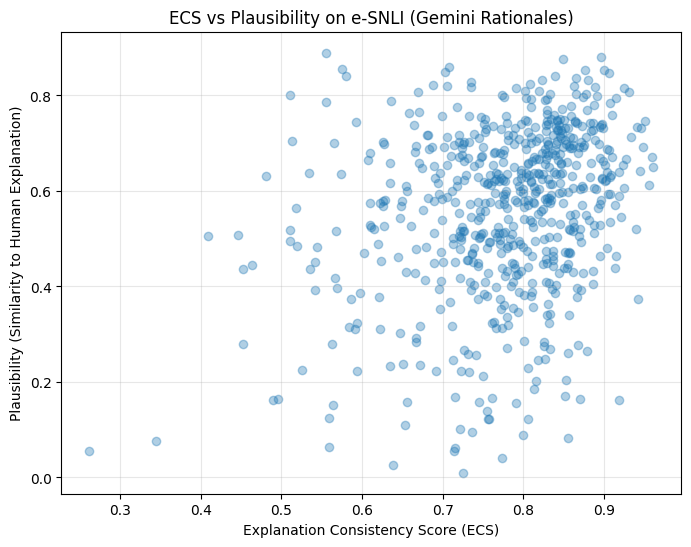

In [103]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Load the two CSV files
# ============================================================
plaus_file = "esnli_gemini_rationales_with_plausibility.csv"
ecs_file = "esnli_gemini_rationales_with_ecs.csv"

df_rationales = pd.read_csv(plaus_file)
df_ecs = pd.read_csv(ecs_file)



# ============================================================
# 2. Sanity check: make sure both contain "id"
# ============================================================
if "id" not in df_rationales.columns or "id" not in df_ecs.columns:
    raise ValueError("❌ Both CSV files must contain an 'id' column.")


# ============================================================
# 3. Merge datasets on id
# ============================================================
df = df_rationales.merge(df_ecs[["id", "ECS"]], on="id", how="inner")

print(f"🔗 Successfully merged. Final dataset has {len(df)} rows.")



# Convert numerical columns safely
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")
df["plausibility"] = pd.to_numeric(df["plausibility"], errors="coerce")

# Drop missing values
df = df.dropna(subset=["ECS", "plausibility"])


# ============================================================
# 6. Visualization A: Scatter Plot (ECS → Plausibility)
# ============================================================
plt.figure(figsize=(8, 6))
plt.scatter(df["ECS"], df["plausibility"], alpha=0.35)

plt.xlabel("Explanation Consistency Score (ECS)")
plt.ylabel("Plausibility (Similarity to Human Explanation)")
plt.title("ECS vs Plausibility on e-SNLI (Gemini Rationales)")
plt.grid(alpha=0.3)
plt.show()


📄 Loaded 627 rows from plausibility file
📄 Loaded 627 rows from ECS file
🔗 Final merged dataset: 627 rows


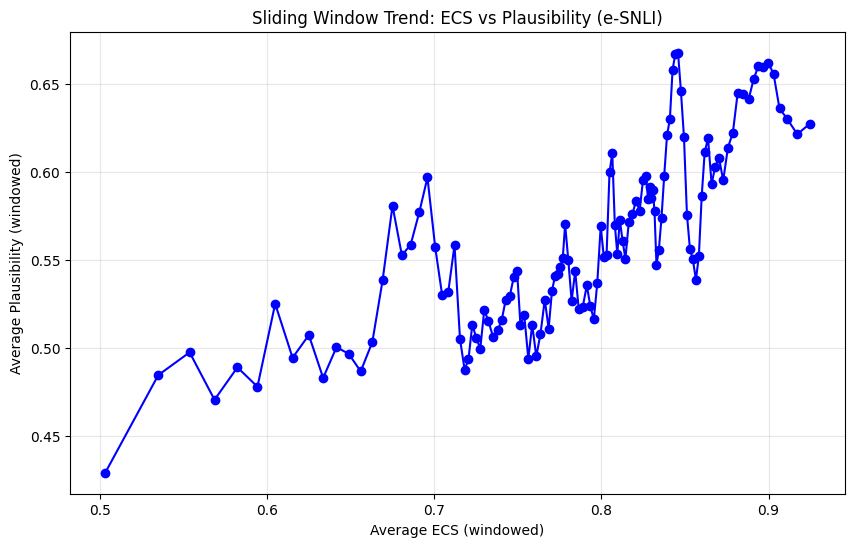

In [104]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Load files
# ============================================================
plaus_file = "esnli_gemini_rationales_with_plausibility.csv"
ecs_file = "esnli_gemini_rationales_with_ecs.csv"

plaus_df = pd.read_csv(plaus_file)
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]

print(f"📄 Loaded {len(plaus_df)} rows from plausibility file")
print(f"📄 Loaded {len(ecs_df)} rows from ECS file")


# ============================================================
# 2. Merge on id
# ============================================================
df = plaus_df.merge(ecs_df, on="id", how="inner")

# Convert numeric columns
df["plausibility"] = pd.to_numeric(df["plausibility"], errors="coerce")
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop NA
df = df.dropna(subset=["plausibility", "ECS"])

print(f"🔗 Final merged dataset: {len(df)} rows")


# ============================================================
# 3. Sort by ECS
# ============================================================
df = df.sort_values(by="ECS").reset_index(drop=True)


# ============================================================
# 4. Sliding window settings
# ============================================================
window_size = 30
step_size = 5

avg_ecs_list = []
avg_plaus_list = []


# ============================================================
# 5. Compute sliding-window averages
# ============================================================
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs = window["ECS"].mean()
    avg_plaus = window["plausibility"].mean()

    avg_ecs_list.append(avg_ecs)
    avg_plaus_list.append(avg_plaus)


# ============================================================
# 6. Visualization
# ============================================================
plt.figure(figsize=(10, 6))
plt.plot(avg_ecs_list, avg_plaus_list, marker='o', linestyle='-', color='blue')

plt.xlabel("Average ECS (windowed)")
plt.ylabel("Average Plausibility (windowed)")
plt.title("Sliding Window Trend: ECS vs Plausibility (e-SNLI)")
plt.grid(alpha=0.3)

plt.show()


**Gemini Density**

📄 Loaded 627 plausibility rows
📄 Loaded 627 ECS rows
🔗 Final merged dataset: 627 rows
📊 ECS Bin Statistics
          ecs_bin   avg_ECS  avg_plausibility  count
2  (0.322, 0.352]  0.344260          0.075905      1
4  (0.382, 0.412]  0.409161          0.506128      1
6  (0.442, 0.472]  0.454031          0.417004      4
7  (0.472, 0.502]  0.489125          0.318896      3
8  (0.502, 0.532]  0.515566          0.541886      7


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_9093/1367454801.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby("ecs_bin").agg(


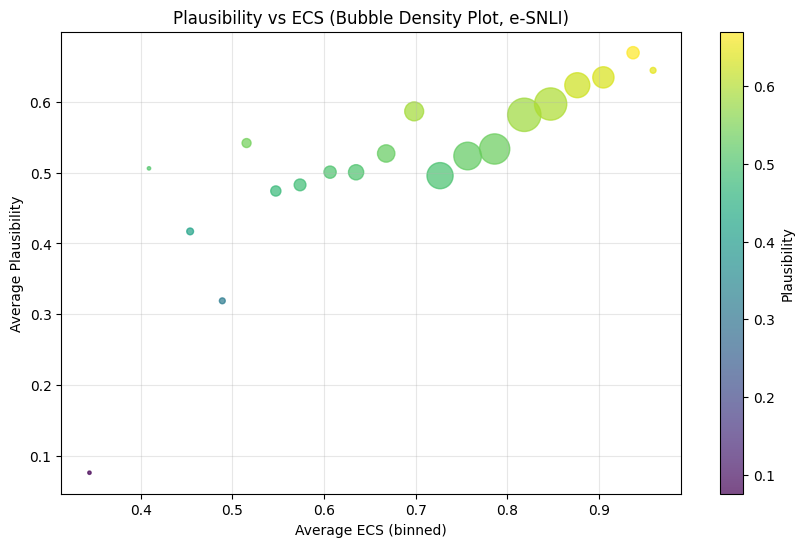

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================
# Load data
# ============================
plaus_file = "esnli_gemini_rationales_with_plausibility.csv"
ecs_file = "esnli_gemini_rationales_with_ecs.csv"

plaus_df = pd.read_csv(plaus_file)
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]

print(f"📄 Loaded {len(plaus_df)} plausibility rows")
print(f"📄 Loaded {len(ecs_df)} ECS rows")

# Merge ECS & plausibility into one dataset
df = plaus_df.merge(ecs_df, on="id", how="left")

# Convert columns to numeric
df["plausibility"] = pd.to_numeric(df["plausibility"], errors="coerce")
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop missing values
df = df.dropna(subset=["plausibility", "ECS"])

print(f"🔗 Final merged dataset: {len(df)} rows")


# ============================
# Bin ECS scores
# ============================
bin_width = 0.03 # same granularity as your original script
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

# ============================
# Compute statistics per bin
# ============================
bin_stats = df.groupby("ecs_bin").agg(
    avg_ECS=("ECS", "mean"),
    avg_plausibility=("plausibility", "mean"),
    count=("id", "count")
).reset_index()

# Remove empty bins (count = 0)
bin_stats = bin_stats.dropna(subset=["avg_ECS", "avg_plausibility", "count"])

print("📊 ECS Bin Statistics")
print(bin_stats.head())


# ============================
# Scatter Plot
# ============================
plt.figure(figsize=(10,6))
plt.scatter(
    bin_stats["avg_ECS"],
    bin_stats["avg_plausibility"],    # ⬅ REPLACED accuracy with plausibility
    s=bin_stats["count"] * 6,         # bubble size = density
    alpha=0.7,
    c=bin_stats["avg_plausibility"],   # optional: color by plausibility
    cmap="viridis"
)

plt.xlabel("Average ECS (binned)")
plt.ylabel("Average Plausibility")
plt.title("Plausibility vs ECS (Bubble Density Plot, e-SNLI)")
plt.grid(alpha=0.3)
plt.colorbar(label="Plausibility")
plt.show()



🔗 Final merged dataset: 627 rows


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_9093/1841977678.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby("ecs_bin")["id"].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_9093/1841977678.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby("ecs_bin")["ECS"].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_9093/1841977678.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend

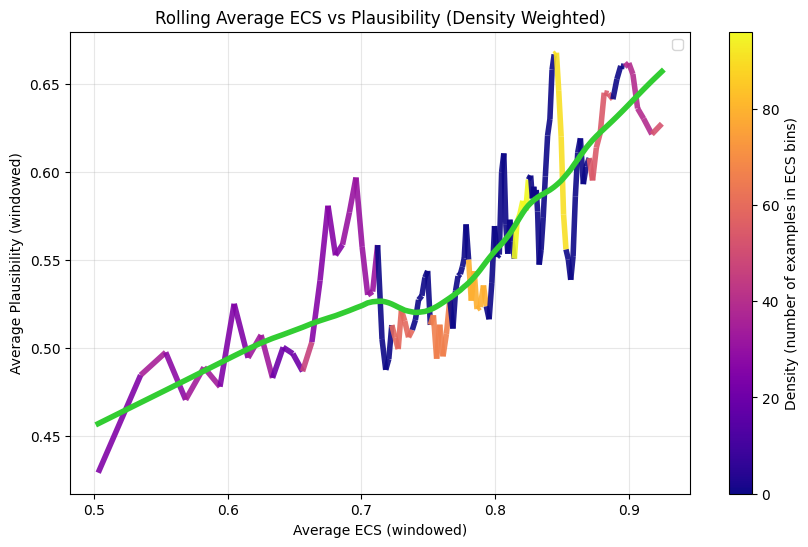

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths (YOUR FILES)
# -----------------------------
plaus_file = "esnli_gemini_rationales_with_plausibility.csv"
ecs_file   = "esnli_gemini_rationales_with_ecs.csv"

# -----------------------------
# Load data
# -----------------------------
plaus_df = pd.read_csv(plaus_file)[["id", "plausibility"]]
ecs_df   = pd.read_csv(ecs_file)[["id", "ECS"]]

# Merge into one dataset
df = plaus_df.merge(ecs_df, on="id", how="inner")
df = df.sort_values("ECS").reset_index(drop=True)

# Ensure numeric
df["plausibility"] = pd.to_numeric(df["plausibility"], errors="coerce")
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop missing rows
df = df.dropna(subset=["plausibility", "ECS"])

print(f"🔗 Final merged dataset: {len(df)} rows")

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.03
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 30
step_size = 5

avg_ecs_list = []
avg_plaus_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_plaus_list.append(window["plausibility"].mean())

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()

    overlapping_bins = bin_stats[
        (bin_stats["bin_mid"] >= ecs_min) &
        (bin_stats["bin_mid"] <= ecs_max)
    ]

    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_plaus_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average ECS (windowed)")
ax.set_ylabel("Average Plausibility (windowed)")
ax.set_title("Rolling Average ECS vs Plausibility (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# LOWESS smoothing
# -----------------------------
density_threshold = np.percentile(window_density, 0)  # keep all data
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
plaus_high = np.array(avg_plaus_list)[mask]

smooth = lowess(plaus_high, ecs_high, frac=0.40, return_sorted=True)

smooth_ecs  = smooth[:, 0]
smooth_plaus = smooth[:, 1]

ax.plot(smooth_ecs, smooth_plaus, color="#32CD32", linewidth=4)

ax.legend()

plt.show()


🔗 Final merged dataset: 627 rows


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_77105/1877554328.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby("ecs_bin")["id"].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_77105/1877554328.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby("ecs_bin")["ECS"].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_77105/1877554328.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.leg

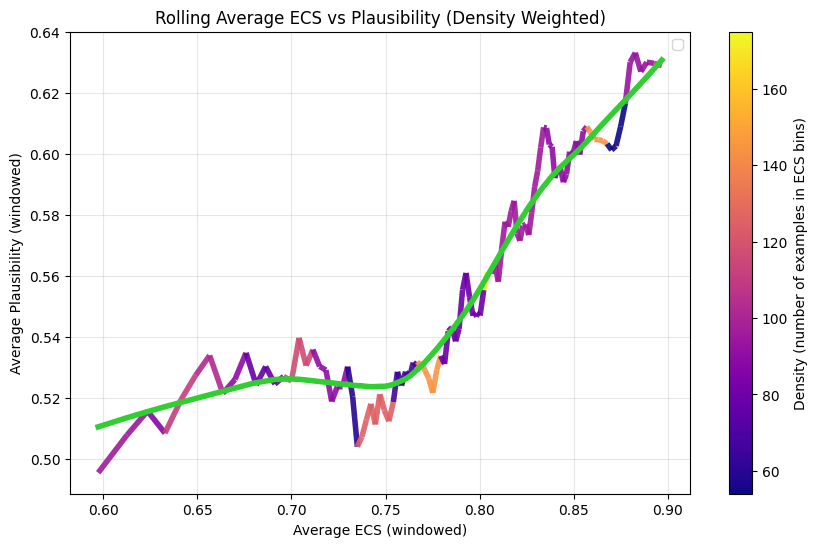

In [147]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths (YOUR FILES)
# -----------------------------
plaus_file = "esnli_gemini_rationales_with_plausibility.csv"
ecs_file   = "esnli_gemini_rationales_with_ecs.csv"

# -----------------------------
# Load data
# -----------------------------
plaus_df = pd.read_csv(plaus_file)[["id", "plausibility"]]
ecs_df   = pd.read_csv(ecs_file)[["id", "ECS"]]

# Merge into one dataset
df = plaus_df.merge(ecs_df, on="id", how="inner")
df = df.sort_values("ECS").reset_index(drop=True)

# Ensure numeric
df["plausibility"] = pd.to_numeric(df["plausibility"], errors="coerce")
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop missing rows
df = df.dropna(subset=["plausibility", "ECS"])

print(f"🔗 Final merged dataset: {len(df)} rows")

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.03
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 100
step_size = 5

avg_ecs_list = []
avg_plaus_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_plaus_list.append(window["plausibility"].mean())

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()

    overlapping_bins = bin_stats[
        (bin_stats["bin_mid"] >= ecs_min) &
        (bin_stats["bin_mid"] <= ecs_max)
    ]

    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_plaus_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average ECS (windowed)")
ax.set_ylabel("Average Plausibility (windowed)")
ax.set_title("Rolling Average ECS vs Plausibility (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# LOWESS smoothing
# -----------------------------
density_threshold = np.percentile(window_density, 0)  # keep all data
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
plaus_high = np.array(avg_plaus_list)[mask]

smooth = lowess(plaus_high, ecs_high, frac=0.40, return_sorted=True)

smooth_ecs  = smooth[:, 0]
smooth_plaus = smooth[:, 1]

ax.plot(smooth_ecs, smooth_plaus, color="#32CD32", linewidth=4)

ax.legend()

plt.show()


**Qwen 2.5**

**filter unwanted examples**

In [1]:
import pandas as pd

# IDs to remove
ids_to_remove = [
    3, 4, 5, 9, 40, 43, 47, 49, 57, 60, 61, 62, 72, 73, 76, 94, 96, 98, 100, 
    105, 113, 115, 116, 118, 121, 129, 139, 140, 145, 147, 149, 153, 155, 158, 
    162, 163, 166, 172, 176, 178, 192, 197, 201, 203, 216, 221, 222, 226, 233, 
    239, 240, 241, 244, 246, 248, 254, 257, 266, 268, 273, 278, 283, 287, 292, 
    293, 296, 303, 304, 309, 313, 317, 325, 331, 336, 344, 350, 354, 359, 363, 
    364, 380, 391, 392, 396, 398, 406, 408, 418, 419, 423, 426, 427, 428, 436, 
    438, 439, 440, 441, 451, 455, 464, 465, 466, 469, 471, 477, 478, 480, 482, 
    488, 494, 498, 515, 518, 520, 521, 522, 523, 525, 527, 528, 533, 534, 536, 
    537, 552, 554, 566, 571, 572, 576, 582, 585, 595, 601, 608, 621, 630, 638, 
    645, 651, 653, 658, 663, 669, 675, 678, 682, 686, 687, 688, 690, 696, 710, 
    716, 717, 730, 732, 735, 739, 750, 756, 758, 766, 773, 778, 783, 785, 787, 
    788, 789, 791, 792
]

# Load original file
df = pd.read_csv("qwen_esnli_rationales.csv")

# Filter out rows where id is in ids_to_remove
df_filtered = df[~df["id"].isin(ids_to_remove)]

# Save the result
output_file = "qwen_esnli_rationales_filtered.csv"
df_filtered.to_csv(output_file, index=False)

print(f"✅ Filtering complete.")
print(f"🔢 Original rows: {len(df)}")
print(f"🔢 Rows removed: {len(ids_to_remove)}")
print(f"🔢 Final rows: {len(df_filtered)}")
print(f"💾 Saved to: {output_file}")

✅ Filtering complete.
🔢 Original rows: 800
🔢 Rows removed: 173
🔢 Final rows: 627
💾 Saved to: qwen_esnli_rationales_filtered.csv


**Qwen-ECS**

In [20]:
!pip -q install sentence-transformers tqdm

import pandas as pd
import numpy as np
import re
from itertools import combinations
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer

# =====================================================
# STEP 1: Load the file
# =====================================================
input_file = "qwen_esnli_rationales_filtered.csv"
output_file = "qwen_esnli_rationales_with_ecs.csv"

df = pd.read_csv(input_file)
print(f"📄 Loaded {len(df)} rows from {input_file}")


# =====================================================
# STEP 2: Define CLEANING function
# =====================================================
def clean_rationale(text):
    """
    Cleans Qwen rationales by removing:
    - Any 'Chain of Thought:' prefix (case-insensitive)
    - Everything after ANY variant of 'Final Answer:'
    """
    if not isinstance(text, str):
        return ""

    # Remove Chain-of-Thought (any capitalization)
    text = re.sub(r"(?i)chain\s*of\s*thought\s*:", "", text).strip()

    # Remove everything AFTER Final Answer (robust regex)
    text = re.split(r"(?i)final\s*answer\s*:", text)[0].strip()

    return text


# =====================================================
# STEP 3: Clean all rationales BEFORE computing ECS
# =====================================================
print("✨ Cleaning rationales before ECS computation...")

df["rationale_original_clean"] = df["rationale_original"].apply(clean_rationale)
df["rationale_pert1_clean"] = df["rationale_perturbation_1_lexical"].apply(clean_rationale)
df["rationale_pert2_clean"] = df["rationale_perturbation_2_syntactic"].apply(clean_rationale)
df["rationale_pert3_clean"] = df["rationale_perturbation_3_pragmatic"].apply(clean_rationale)


# =====================================================
# STEP 4: Initialize embedding model
# =====================================================
print("🚀 Loading embedding model: all-MiniLM-L6-v2 ...")
model = SentenceTransformer("all-MiniLM-L6-v2")


# =====================================================
# STEP 5: Semantic ECS computation function
# =====================================================
def compute_ecs_semantic(rationales):
    """
    Compute Explanation Consistency Score (mean cosine similarity
    among all cleaned explanations).
    """
    texts = [t for t in rationales if isinstance(t, str) and t.strip()]
    if len(texts) < 2:
        return np.nan

    sim_scores = []
    for a, b in combinations(texts, 2):
        emb = model.encode([a, b], normalize_embeddings=True)
        sim_scores.append(float(np.dot(emb[0], emb[1])))

    return np.mean(sim_scores)


# =====================================================
# STEP 6: Compute ECS using CLEANED rationales
# =====================================================
ecs_values = []

print("🧮 Computing ECS (semantic consistency) for each example...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    ecs = compute_ecs_semantic([
        row["rationale_original_clean"],
        row["rationale_pert1_clean"],
        row["rationale_pert2_clean"],
        row["rationale_pert3_clean"],
    ])
    ecs_values.append(ecs)

df["ECS"] = ecs_values


# =====================================================
# STEP 7: Print overall ECS
# =====================================================
overall_ecs = np.nanmean(df["ECS"])
print(f"\n🔍 Average Explanation Consistency Score (ECS): {overall_ecs:.4f}")


# =====================================================
# STEP 8: Save CLEAN ONLY + ECS
# =====================================================
df_output = df[[
    "id",
    "rationale_original_clean",
    "rationale_pert1_clean",
    "rationale_pert2_clean",
    "rationale_pert3_clean",
    "ECS"
]]

df_output.to_csv(output_file, index=False)
print(f"💾 Saved CLEANED + ECS dataset to {output_file}")




huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
📄 Loaded 627 rows from qwen_esnli_rationales_filtered.csv
✨ Cleaning rationales before ECS computation...
🚀 Loading embedding model: all-MiniLM-L6-v2 ...
🧮 Computing ECS (semantic consistency) for each example...


  0%|          | 0/627 [00:00<?, ?it/s]


🔍 Average Explanation Consistency Score (ECS): 0.8745
💾 Saved CLEANED + ECS dataset to qwen_esnli_rationales_with_ecs.csv


**merge rationales with explanation**

In [21]:
import pandas as pd

# ============================
# Load input files
# ============================
rationales_file = "qwen_esnli_rationales_filtered.csv"
perturb_file = "esnli_800_with_perturbations.csv"

df_r = pd.read_csv(rationales_file)
df_p = pd.read_csv(perturb_file)

print(f"📄 Loaded {len(df_r)} rows from {rationales_file}")
print(f"📄 Loaded {len(df_p)} rows from {perturb_file}")

# ============================
# Keep only id + Explanation from perturb file
# ============================
df_p = df_p[["id", "Explanation"]]

# ============================
# Merge based on id
# ============================
df_merged = df_r.merge(df_p, on="id", how="left")

print(f"🔗 Merge complete. Final rows: {len(df_merged)}")

# ============================
# Save output
# ============================
output_file = "qwen_esnli_rationales_filtered_with_explanations.csv"
df_merged.to_csv(output_file, index=False)

print(f"💾 Saved merged file to {output_file}")

📄 Loaded 627 rows from qwen_esnli_rationales_filtered.csv
📄 Loaded 800 rows from esnli_800_with_perturbations.csv
🔗 Merge complete. Final rows: 627
💾 Saved merged file to qwen_esnli_rationales_filtered_with_explanations.csv


**Qwen measure Plausibility**

In [9]:
!pip -q install sentence-transformers tqdm

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer

# ============================================================
# 1. Load the file
# ============================================================
input_file = "qwen_esnli_rationales_filtered_with_explanations.csv"
output_file = "qwen_esnli_rationales_with_plausibility.csv"

df = pd.read_csv(input_file)
print(f"📄 Loaded {len(df)} rows from {input_file}")


# ============================================================
# 2. Clean rationale function
# ============================================================
def clean_rationale(text):
    """
    Removes boilerplate such as 'Chain of Thought:' and 
    everything after 'Final Answer:'.
    """
    if not isinstance(text, str):
        return ""

    text = text.replace("Chain of Thought:", "").strip()

    if "Final Answer:" in text:
        text = text.split("Final Answer:")[0].strip()

    return text


# ============================================================
# 3. Create cleaned rationale column
# ============================================================
print("✨ Cleaning original rationales...")
df["rationale_original_cleaned"] = df["rationale_original"].apply(clean_rationale)


# ============================================================
# 4. Load embedding model
# ============================================================
print("🔍 Loading embedding model: all-MiniLM-L6-v2 ...")
model = SentenceTransformer("all-MiniLM-L6-v2")


# ============================================================
# 5. Compute plausibility (semantic similarity)
# ============================================================
def compute_plausibility(model_expl, human_expl):
    """
    Computes cosine similarity between cleaned LLM rationale
    and human-written explanation.
    """
    if not isinstance(model_expl, str) or not model_expl.strip():
        return np.nan
    if not isinstance(human_expl, str) or not human_expl.strip():
        return np.nan

    emb = model.encode([model_expl, human_expl], normalize_embeddings=True)
    return float(np.dot(emb[0], emb[1]))


print("🧮 Computing plausibility scores...")
tqdm.pandas()

df["plausibility"] = df.progress_apply(
    lambda row: compute_plausibility(row["rationale_original_cleaned"], row["Explanation"]),
    axis=1
)


# ============================================================
# 6. Keep only required columns
# ============================================================
df_output = df[["id", "rationale_original_cleaned", "Explanation", "plausibility"]]


# ============================================================
# 7. Save results
# ============================================================
df_output.to_csv(output_file, index=False)
print(f"💾 Saved cleaned + plausibility dataset to {output_file}")

# Show sample
display(df_output.head())

# ============================================================
# 8. Print average plausibility
# ============================================================
avg_plausibility = df_output["plausibility"].mean()
print(f"\n🔍 Average Plausibility Score: {avg_plausibility:.4f}")


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
📄 Loaded 627 rows from qwen_esnli_rationales_filtered_with_explanations.csv
✨ Cleaning original rationales...
🔍 Loading embedding model: all-MiniLM-L6-v2 ...
🧮 Computing plausibility scores...


  0%|          | 0/627 [00:00<?, ?it/s]

💾 Saved cleaned + plausibility dataset to qwen_esnli_rationales_with_plausibility.csv


,id,rationale_original_cleaned,Explanation,plausibility
0,1,"The premise specifies a woman in a blue apron,...",The apron is either blue or pink. The woman ca...,0.649672
1,2,The premise describes a young man discovering ...,The young man is either at school or in the sand.,0.307713
2,6,The presence of chairs in a dark nightclub doe...,A nightclub might include a bar but a bar is n...,0.509930
3,7,The premise specifies that a young woman is sm...,A young woman shoots a gun in target range,0.417112
4,8,The premise describes a man in a martial arts ...,jumping implies leaps,0.550986



🔍 Average Plausibility Score: 0.5744


**Qwen ECS-Plausibility**

🔗 Successfully merged. Final dataset has 627 rows.


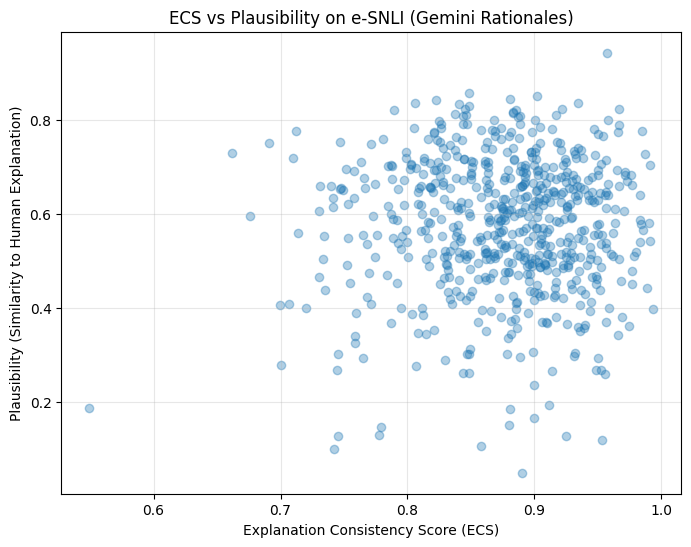

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Load the two CSV files
# ============================================================
plaus_file = "qwen_esnli_rationales_with_plausibility.csv"
ecs_file = "qwen_esnli_rationales_with_ecs.csv"

df_rationales = pd.read_csv(plaus_file)
df_ecs = pd.read_csv(ecs_file)



# ============================================================
# 2. Sanity check: make sure both contain "id"
# ============================================================
if "id" not in df_rationales.columns or "id" not in df_ecs.columns:
    raise ValueError("❌ Both CSV files must contain an 'id' column.")


# ============================================================
# 3. Merge datasets on id
# ============================================================
df = df_rationales.merge(df_ecs[["id", "ECS"]], on="id", how="inner")

print(f"🔗 Successfully merged. Final dataset has {len(df)} rows.")



# Convert numerical columns safely
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")
df["plausibility"] = pd.to_numeric(df["plausibility"], errors="coerce")

# Drop missing values
df = df.dropna(subset=["ECS", "plausibility"])


# ============================================================
# 6. Visualization A: Scatter Plot (ECS → Plausibility)
# ============================================================
plt.figure(figsize=(8, 6))
plt.scatter(df["ECS"], df["plausibility"], alpha=0.35)

plt.xlabel("Explanation Consistency Score (ECS)")
plt.ylabel("Plausibility (Similarity to Human Explanation)")
plt.title("ECS vs Plausibility on e-SNLI (Gemini Rationales)")
plt.grid(alpha=0.3)
plt.show()



📄 Loaded 627 rows from plausibility file
📄 Loaded 627 rows from ECS file
🔗 Final merged dataset: 627 rows


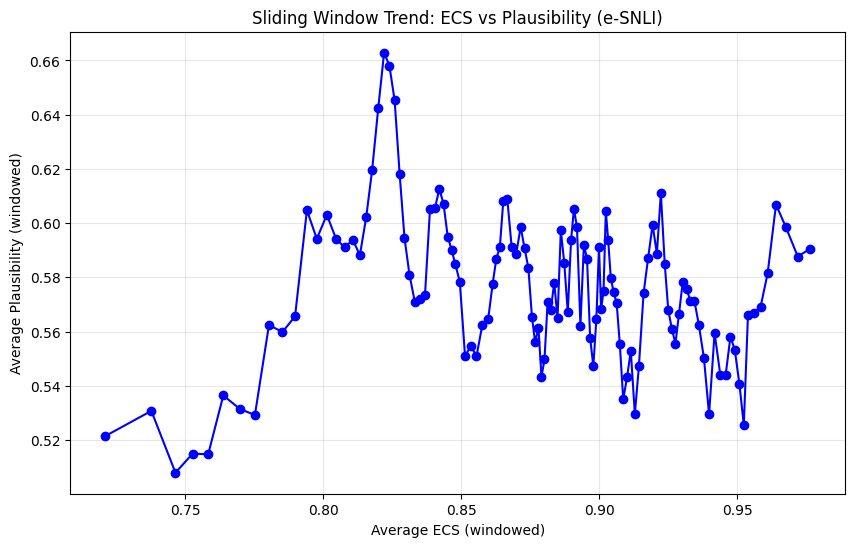

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Load files
# ============================================================
plaus_file = "qwen_esnli_rationales_with_plausibility.csv"
ecs_file = "qwen_esnli_rationales_with_ecs.csv"

plaus_df = pd.read_csv(plaus_file)
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]

print(f"📄 Loaded {len(plaus_df)} rows from plausibility file")
print(f"📄 Loaded {len(ecs_df)} rows from ECS file")


# ============================================================
# 2. Merge on id
# ============================================================
df = plaus_df.merge(ecs_df, on="id", how="inner")

# Convert numeric columns
df["plausibility"] = pd.to_numeric(df["plausibility"], errors="coerce")
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop NA
df = df.dropna(subset=["plausibility", "ECS"])

print(f"🔗 Final merged dataset: {len(df)} rows")


# ============================================================
# 3. Sort by ECS
# ============================================================
df = df.sort_values(by="ECS").reset_index(drop=True)


# ============================================================
# 4. Sliding window settings
# ============================================================
window_size = 30
step_size = 5

avg_ecs_list = []
avg_plaus_list = []


# ============================================================
# 5. Compute sliding-window averages
# ============================================================
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs = window["ECS"].mean()
    avg_plaus = window["plausibility"].mean()

    avg_ecs_list.append(avg_ecs)
    avg_plaus_list.append(avg_plaus)


# ============================================================
# 6. Visualization
# ============================================================
plt.figure(figsize=(10, 6))
plt.plot(avg_ecs_list, avg_plaus_list, marker='o', linestyle='-', color='blue')

plt.xlabel("Average ECS (windowed)")
plt.ylabel("Average Plausibility (windowed)")
plt.title("Sliding Window Trend: ECS vs Plausibility (e-SNLI)")
plt.grid(alpha=0.3)

plt.show()


📄 Loaded 627 plausibility rows
📄 Loaded 627 ECS rows
🔗 Final merged dataset: 627 rows
📊 ECS Bin Statistics
          ecs_bin   avg_ECS  avg_plausibility  count
3  (0.639, 0.669]  0.661850          0.729236      1
4  (0.669, 0.699]  0.683513          0.672868      2
5  (0.699, 0.729]  0.708964          0.507069      7
6  (0.729, 0.759]  0.745511          0.517093     26
7  (0.759, 0.789]  0.776796          0.552825     29


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_77105/4139940564.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby("ecs_bin").agg(


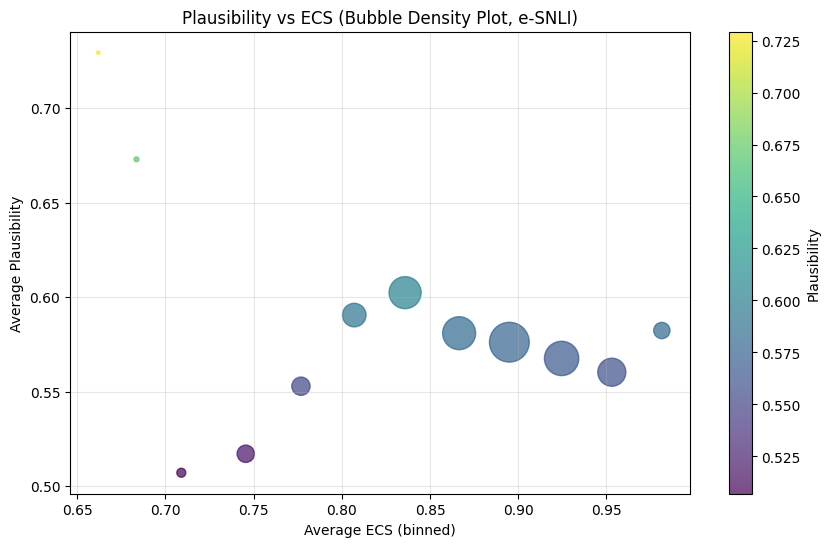

In [154]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================
# Load data
# ============================
plaus_file = "qwen_esnli_rationales_with_plausibility.csv"
ecs_file = "qwen_esnli_rationales_with_ecs.csv"

plaus_df = pd.read_csv(plaus_file)
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]

print(f"📄 Loaded {len(plaus_df)} plausibility rows")
print(f"📄 Loaded {len(ecs_df)} ECS rows")

# Merge ECS & plausibility into one dataset
df = plaus_df.merge(ecs_df, on="id", how="left")

# Convert columns to numeric
df["plausibility"] = pd.to_numeric(df["plausibility"], errors="coerce")
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop missing values
df = df.dropna(subset=["plausibility", "ECS"])

print(f"🔗 Final merged dataset: {len(df)} rows")


# ============================
# Bin ECS scores
# ============================
bin_width = 0.03 # same granularity as your original script
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

# ============================
# Compute statistics per bin
# ============================
bin_stats = df.groupby("ecs_bin").agg(
    avg_ECS=("ECS", "mean"),
    avg_plausibility=("plausibility", "mean"),
    count=("id", "count")
).reset_index()

# Remove empty bins (count = 0)
bin_stats = bin_stats.dropna(subset=["avg_ECS", "avg_plausibility", "count"])

print("📊 ECS Bin Statistics")
print(bin_stats.head())


# ============================
# Scatter Plot
# ============================
plt.figure(figsize=(10,6))
plt.scatter(
    bin_stats["avg_ECS"],
    bin_stats["avg_plausibility"],    # ⬅ REPLACED accuracy with plausibility
    s=bin_stats["count"] * 6,         # bubble size = density
    alpha=0.7,
    c=bin_stats["avg_plausibility"],   # optional: color by plausibility
    cmap="viridis"
)

plt.xlabel("Average ECS (binned)")
plt.ylabel("Average Plausibility")
plt.title("Plausibility vs ECS (Bubble Density Plot, e-SNLI)")
plt.grid(alpha=0.3)
plt.colorbar(label="Plausibility")
plt.show()


🔗 Final merged dataset: 627 rows


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_77105/12803045.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby("ecs_bin")["id"].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_77105/12803045.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby("ecs_bin")["ECS"].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_77105/12803045.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


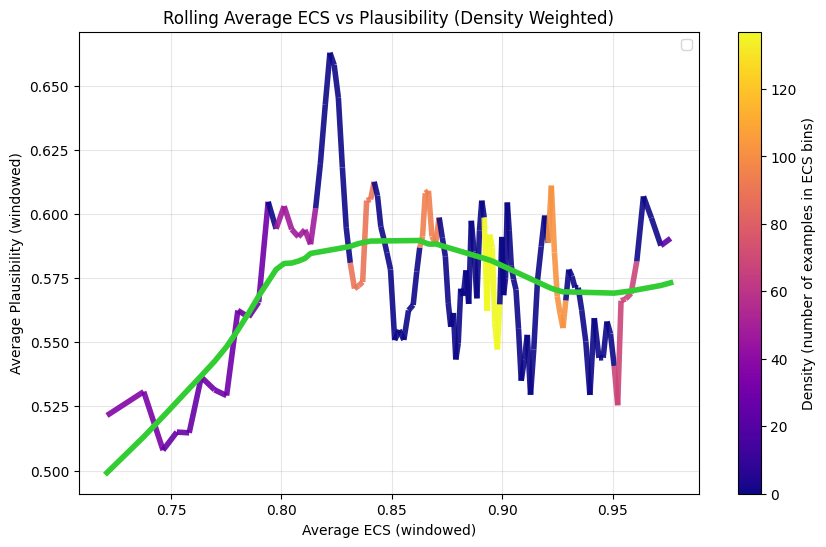

In [160]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths (YOUR FILES)
# -----------------------------
plaus_file = "qwen_esnli_rationales_with_plausibility.csv"
ecs_file = "qwen_esnli_rationales_with_ecs.csv"

# -----------------------------
# Load data
# -----------------------------
plaus_df = pd.read_csv(plaus_file)[["id", "plausibility"]]
ecs_df   = pd.read_csv(ecs_file)[["id", "ECS"]]

# Merge into one dataset
df = plaus_df.merge(ecs_df, on="id", how="inner")
df = df.sort_values("ECS").reset_index(drop=True)

# Ensure numeric
df["plausibility"] = pd.to_numeric(df["plausibility"], errors="coerce")
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop missing rows
df = df.dropna(subset=["plausibility", "ECS"])

print(f"🔗 Final merged dataset: {len(df)} rows")

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.03
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 30
step_size = 5

avg_ecs_list = []
avg_plaus_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_plaus_list.append(window["plausibility"].mean())

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()

    overlapping_bins = bin_stats[
        (bin_stats["bin_mid"] >= ecs_min) &
        (bin_stats["bin_mid"] <= ecs_max)
    ]

    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_plaus_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average ECS (windowed)")
ax.set_ylabel("Average Plausibility (windowed)")
ax.set_title("Rolling Average ECS vs Plausibility (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# LOWESS smoothing
# -----------------------------
density_threshold = np.percentile(window_density, 60)  # keep all data
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
plaus_high = np.array(avg_plaus_list)[mask]

smooth = lowess(plaus_high, ecs_high, frac=0.40, return_sorted=True)

smooth_ecs  = smooth[:, 0]
smooth_plaus = smooth[:, 1]

ax.plot(smooth_ecs, smooth_plaus, color="#32CD32", linewidth=4)

ax.legend()

plt.show()


🔗 Final merged dataset: 627 rows


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_9093/2806034940.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby("ecs_bin")["id"].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_9093/2806034940.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby("ecs_bin")["ECS"].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_9093/2806034940.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend

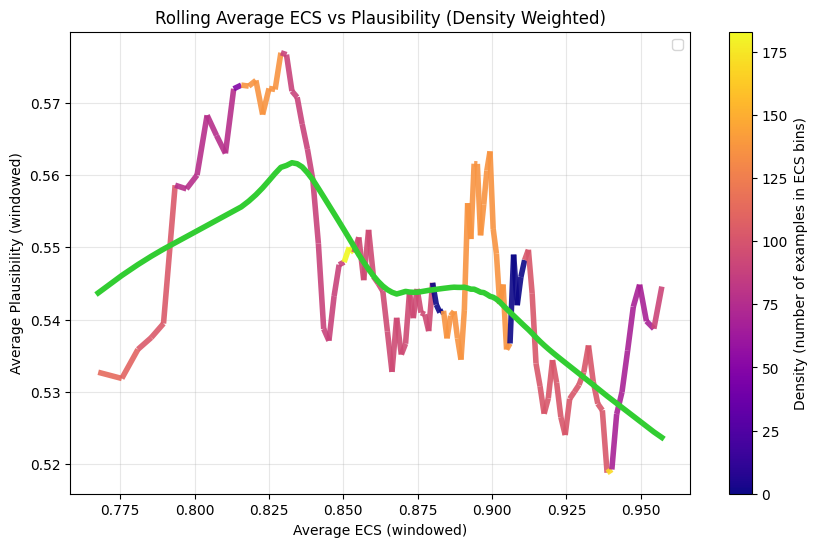

In [140]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths (YOUR FILES)
# -----------------------------
plaus_file = "qwen_esnli_rationales_with_plausibility.csv"
ecs_file = "qwen_esnli_rationales_with_ecs.csv"

# -----------------------------
# Load data
# -----------------------------
plaus_df = pd.read_csv(plaus_file)[["id", "plausibility"]]
ecs_df   = pd.read_csv(ecs_file)[["id", "ECS"]]

# Merge into one dataset
df = plaus_df.merge(ecs_df, on="id", how="inner")
df = df.sort_values("ECS").reset_index(drop=True)

# Ensure numeric
df["plausibility"] = pd.to_numeric(df["plausibility"], errors="coerce")
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop missing rows
df = df.dropna(subset=["plausibility", "ECS"])

print(f"🔗 Final merged dataset: {len(df)} rows")

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.03
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 100
step_size = 5

avg_ecs_list = []
avg_plaus_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_plaus_list.append(window["plausibility"].mean())

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()

    overlapping_bins = bin_stats[
        (bin_stats["bin_mid"] >= ecs_min) &
        (bin_stats["bin_mid"] <= ecs_max)
    ]

    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_plaus_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average ECS (windowed)")
ax.set_ylabel("Average Plausibility (windowed)")
ax.set_title("Rolling Average ECS vs Plausibility (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# LOWESS smoothing
# -----------------------------
density_threshold = np.percentile(window_density, 20)  # keep all data
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
plaus_high = np.array(avg_plaus_list)[mask]

smooth = lowess(plaus_high, ecs_high, frac=0.60, return_sorted=True)

smooth_ecs  = smooth[:, 0]
smooth_plaus = smooth[:, 1]

ax.plot(smooth_ecs, smooth_plaus, color="#32CD32", linewidth=4)

ax.legend()

plt.show()

**Llama**

In [109]:
import pandas as pd

# IDs to remove
ids_to_remove = [
    3, 4, 5, 9, 40, 43, 47, 49, 57, 60, 61, 62, 72, 73, 76, 94, 96, 98, 100, 
    105, 113, 115, 116, 118, 121, 129, 139, 140, 145, 147, 149, 153, 155, 158, 
    162, 163, 166, 172, 176, 178, 192, 197, 201, 203, 216, 221, 222, 226, 233, 
    239, 240, 241, 244, 246, 248, 254, 257, 266, 268, 273, 278, 283, 287, 292, 
    293, 296, 303, 304, 309, 313, 317, 325, 331, 336, 344, 350, 354, 359, 363, 
    364, 380, 391, 392, 396, 398, 406, 408, 418, 419, 423, 426, 427, 428, 436, 
    438, 439, 440, 441, 451, 455, 464, 465, 466, 469, 471, 477, 478, 480, 482, 
    488, 494, 498, 515, 518, 520, 521, 522, 523, 525, 527, 528, 533, 534, 536, 
    537, 552, 554, 566, 571, 572, 576, 582, 585, 595, 601, 608, 621, 630, 638, 
    645, 651, 653, 658, 663, 669, 675, 678, 682, 686, 687, 688, 690, 696, 710, 
    716, 717, 730, 732, 735, 739, 750, 756, 758, 766, 773, 778, 783, 785, 787, 
    788, 789, 791, 792
]

# Load original file
df = pd.read_csv("esnli_llama_rationales.csv")

# Filter out rows where id is in ids_to_remove
df_filtered = df[~df["id"].isin(ids_to_remove)]

# Save the result
output_file = "esnli_llama_rationales_filtered.csv"
df_filtered.to_csv(output_file, index=False)

print(f"✅ Filtering complete.")
print(f"🔢 Original rows: {len(df)}")
print(f"🔢 Rows removed: {len(ids_to_remove)}")
print(f"🔢 Final rows: {len(df_filtered)}")
print(f"💾 Saved to: {output_file}")

✅ Filtering complete.
🔢 Original rows: 800
🔢 Rows removed: 173
🔢 Final rows: 627
💾 Saved to: esnli_llama_rationales_filtered.csv


In [110]:
import pandas as pd
import re

def extract_final_answers(input_csv="esnli_llama_rationales_filtered.csv",
                          output_csv="esnli_llama_final_answers.csv"):


    """
    Loads the e-SNLI Gemini rationales file, extracts the 'Final Answer' label
    from each rationale column, and saves a new CSV with only those answers.
    
    Assumes input columns: 
        id, rationale_original, rationale_lexical, rationale_syntactic, rationale_pragmatic
    """

    # Load dataset
    df = pd.read_csv(input_csv)

    # Regex to capture: Final Answer: LABEL
    pattern = r"Final Answer:\s*([A-Z]+)"

    # Columns that contain rationales
    rationale_cols = ["rationale_original", "rationale_lexical", "rationale_syntactic", "rationale_pragmatic"]

    # Create new columns with extracted labels
    for col in rationale_cols:
        df[col + "_final"] = df[col].apply(
            lambda x: re.search(pattern, x).group(1) if isinstance(x, str) and re.search(pattern, x) else None
        )

    # Create final dataframe with only id + extracted answers
    final_cols = ["id"] + [col + "_final" for col in rationale_cols]
    df_final = df[final_cols]

    # Save to new CSV
    df_final.to_csv(output_csv, index=False)

    return df_final

# Run the function (creates the new CSV)
df_results = extract_final_answers()
df_results.head()

,id,rationale_original_final,rationale_lexical_final,rationale_syntactic_final,rationale_pragmatic_final
0,1,NEUTRAL,NEUTRAL,NEUTRAL,NEUTRAL
1,2,NEUTRAL,NEUTRAL,NEUTRAL,NEUTRAL
2,6,NEUTRAL,NEUTRAL,NEUTRAL,NEUTRAL
3,7,ENTAILMENT,NEUTRAL,ENTAILMENT,ENTAILMENT
4,8,ENTAILMENT,ENTAILMENT,ENTAILMENT,ENTAILMENT


**Llama-ECS**

In [111]:
!pip -q install sentence-transformers tqdm

import pandas as pd
import numpy as np
from itertools import combinations
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer

# =====================================================
# STEP 1: Load the file
# =====================================================
input_file = "esnli_llama_rationales_filtered.csv"
output_file = "esnli_llama_rationales_with_ecs.csv"

df = pd.read_csv(input_file)
print(f"📄 Loaded {len(df)} rows from {input_file}")


# =====================================================
# STEP 2: Define CLEANING function
# =====================================================
def clean_rationale(text):
    """
    Removes boilerplate such as 'Chain of Thought:' and 
    everything after 'Final Answer:'.
    """
    if not isinstance(text, str):
        return ""

    text = text.replace("Chain of Thought:", "").strip()

    if "Final Answer:" in text:
        text = text.split("Final Answer:")[0].strip()

    return text


# =====================================================
# STEP 3: Clean all rationales BEFORE computing ECS
# =====================================================
print("✨ Cleaning rationales before ECS computation...")

df["rationale_original_clean"] = df["rationale_original"].apply(clean_rationale)
df["rationale_pert1_clean"] = df["rationale_lexical"].apply(clean_rationale)
df["rationale_pert2_clean"] = df["rationale_syntactic"].apply(clean_rationale)
df["rationale_pert3_clean"] = df["rationale_pragmatic"].apply(clean_rationale)


# =====================================================
# STEP 4: Initialize embedding model
# =====================================================
print("🚀 Loading embedding model: all-MiniLM-L6-v2 ...")
model = SentenceTransformer("all-MiniLM-L6-v2")


# =====================================================
# STEP 5: Semantic ECS computation function
# =====================================================
def compute_ecs_semantic(rationales):
    """
    Compute Explanation Consistency Score (semantic meaning)
    = mean cosine similarity between all pairs of cleaned explanations.
    """
    texts = [t for t in rationales if isinstance(t, str) and t.strip()]
    if len(texts) < 2:
        return np.nan

    pairs = list(combinations(texts, 2))
    sim_scores = []

    for a, b in pairs:
        emb = model.encode([a, b], normalize_embeddings=True)
        sim = float(np.dot(emb[0], emb[1]))
        sim_scores.append(sim)

    return np.mean(sim_scores)


# =====================================================
# STEP 6: Compute ECS using CLEANED rationales
# =====================================================
ecs_values = []

print("🧮 Computing ECS (semantic consistency) for each example...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    ecs = compute_ecs_semantic([
        row["rationale_original_clean"],
        row["rationale_pert1_clean"],
        row["rationale_pert2_clean"],
        row["rationale_pert3_clean"],
    ])
    ecs_values.append(ecs)

df["ECS"] = ecs_values


# =====================================================
# STEP 7: Print overall ECS
# =====================================================
overall_ecs = np.nanmean(df["ECS"])
print(f"\n🔍 Average Explanation Consistency Score (ECS): {overall_ecs:.4f}")


# =====================================================
# STEP 8: Save results
# =====================================================
df.to_csv(output_file, index=False)
print(f"💾 Saved ECS-annotated file to {output_file}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
📄 Loaded 627 rows from esnli_llama_rationales_filtered.csv
✨ Cleaning rationales before ECS computation...
🚀 Loading embedding model: all-MiniLM-L6-v2 ...
🧮 Computing ECS (semantic consistency) for each example...


  0%|          | 0/627 [00:00<?, ?it/s]


🔍 Average Explanation Consistency Score (ECS): 0.8271
💾 Saved ECS-annotated file to esnli_llama_rationales_with_ecs.csv


In [112]:
import pandas as pd

# ============================
# Load input files
# ============================
rationales_file = "esnli_llama_rationales_filtered.csv"
perturb_file = "esnli_800_with_perturbations.csv"

df_r = pd.read_csv(rationales_file)
df_p = pd.read_csv(perturb_file)

print(f"📄 Loaded {len(df_r)} rows from {rationales_file}")
print(f"📄 Loaded {len(df_p)} rows from {perturb_file}")

# ============================
# Keep only id + Explanation from perturb file
# ============================
df_p = df_p[["id", "Explanation"]]

# ============================
# Merge based on id
# ============================
df_merged = df_r.merge(df_p, on="id", how="left")

print(f"🔗 Merge complete. Final rows: {len(df_merged)}")

# ============================
# Save output
# ============================
output_file = "esnli_llama_rationales_filtered_with_explanations.csv"
df_merged.to_csv(output_file, index=False)

print(f"💾 Saved merged file to {output_file}")

📄 Loaded 627 rows from esnli_llama_rationales_filtered.csv
📄 Loaded 800 rows from esnli_800_with_perturbations.csv
🔗 Merge complete. Final rows: 627
💾 Saved merged file to esnli_llama_rationales_filtered_with_explanations.csv


**Llama Measure Plausability**

In [113]:
!pip -q install sentence-transformers tqdm

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer

# ============================================================
# 1. Load the file
# ============================================================
input_file = "esnli_llama_rationales_filtered_with_explanations.csv"
output_file = "esnli_llama_rationales_with_plausibility.csv"

df = pd.read_csv(input_file)
print(f"📄 Loaded {len(df)} rows from {input_file}")


# ============================================================
# 2. Clean rationale function
# ============================================================
def clean_rationale(text):
    """
    Removes boilerplate such as 'Chain of Thought:' and 
    everything after 'Final Answer:'.
    """
    if not isinstance(text, str):
        return ""

    text = text.replace("Chain of Thought:", "").strip()

    if "Final Answer:" in text:
        text = text.split("Final Answer:")[0].strip()

    return text


# ============================================================
# 3. Create cleaned rationale column
# ============================================================
print("✨ Cleaning original rationales...")
df["rationale_original_cleaned"] = df["rationale_original"].apply(clean_rationale)


# ============================================================
# 4. Load embedding model
# ============================================================
print("🔍 Loading embedding model: all-MiniLM-L6-v2 ...")
model = SentenceTransformer("all-MiniLM-L6-v2")


# ============================================================
# 5. Compute plausibility (semantic similarity)
# ============================================================
def compute_plausibility(model_expl, human_expl):
    """
    Computes cosine similarity between cleaned LLM rationale
    and human-written explanation.
    """
    if not isinstance(model_expl, str) or not model_expl.strip():
        return np.nan
    if not isinstance(human_expl, str) or not human_expl.strip():
        return np.nan

    emb = model.encode([model_expl, human_expl], normalize_embeddings=True)
    return float(np.dot(emb[0], emb[1]))


print("🧮 Computing plausibility scores...")
tqdm.pandas()

df["plausibility"] = df.progress_apply(
    lambda row: compute_plausibility(row["rationale_original_cleaned"], row["Explanation"]),
    axis=1
)


# ============================================================
# 6. Keep only required columns
# ============================================================
df_output = df[["id", "rationale_original_cleaned", "Explanation", "plausibility"]]


# ============================================================
# 7. Save results
# ============================================================
df_output.to_csv(output_file, index=False)
print(f"💾 Saved cleaned + plausibility dataset to {output_file}")

# Show sample
display(df_output.head())

# ============================================================
# 8. Print average plausibility
# ============================================================
avg_plausibility = df_output["plausibility"].mean()
print(f"\n🔍 Average Plausibility Score: {avg_plausibility:.4f}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
📄 Loaded 627 rows from esnli_llama_rationales_filtered_with_explanations.csv
✨ Cleaning original rationales...
🔍 Loading embedding model: all-MiniLM-L6-v2 ...
🧮 Computing plausibility scores...


  0%|          | 0/627 [00:00<?, ?it/s]

💾 Saved cleaned + plausibility dataset to esnli_llama_rationales_with_plausibility.csv


,id,rationale_original_cleaned,Explanation,plausibility
0,1,The color of the apron and the action of cooki...,The apron is either blue or pink. The woman ca...,0.750429
1,2,The premise describes a scene involving a youn...,The young man is either at school or in the sand.,0.407943
2,6,The presence of chairs in a dark nightclub doe...,A nightclub might include a bar but a bar is n...,0.593635
3,7,The premise describes a specific scenario wher...,A young woman shoots a gun in target range,0.460136
4,8,The premise explicitly describes the man weari...,jumping implies leaps,0.519012



🔍 Average Plausibility Score: 0.5354


**Llama ECS-Plausibility**

🔗 Successfully merged. Final dataset has 627 rows.


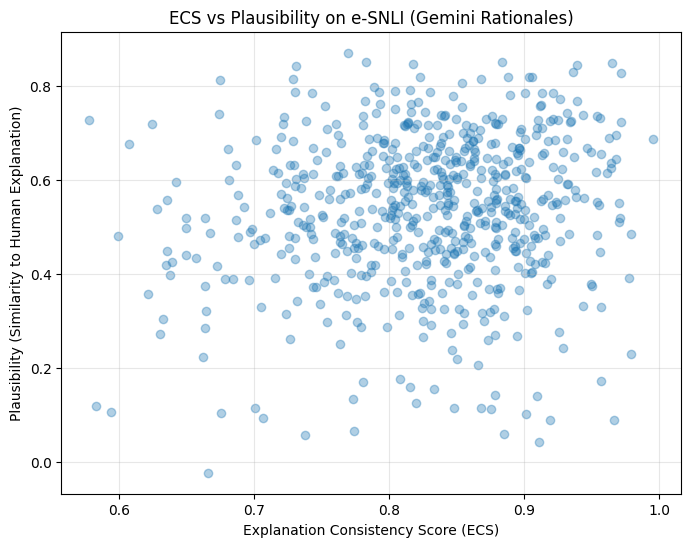

In [114]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Load the two CSV files
# ============================================================
plaus_file = "esnli_llama_rationales_with_plausibility.csv"
ecs_file = "esnli_llama_rationales_with_ecs.csv"

df_rationales = pd.read_csv(plaus_file)
df_ecs = pd.read_csv(ecs_file)



# ============================================================
# 2. Sanity check: make sure both contain "id"
# ============================================================
if "id" not in df_rationales.columns or "id" not in df_ecs.columns:
    raise ValueError("❌ Both CSV files must contain an 'id' column.")


# ============================================================
# 3. Merge datasets on id
# ============================================================
df = df_rationales.merge(df_ecs[["id", "ECS"]], on="id", how="inner")

print(f"🔗 Successfully merged. Final dataset has {len(df)} rows.")



# Convert numerical columns safely
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")
df["plausibility"] = pd.to_numeric(df["plausibility"], errors="coerce")

# Drop missing values
df = df.dropna(subset=["ECS", "plausibility"])


# ============================================================
# 6. Visualization A: Scatter Plot (ECS → Plausibility)
# ============================================================
plt.figure(figsize=(8, 6))
plt.scatter(df["ECS"], df["plausibility"], alpha=0.35)

plt.xlabel("Explanation Consistency Score (ECS)")
plt.ylabel("Plausibility (Similarity to Human Explanation)")
plt.title("ECS vs Plausibility on e-SNLI (Gemini Rationales)")
plt.grid(alpha=0.3)
plt.show()


📄 Loaded 627 rows from plausibility file
📄 Loaded 627 rows from ECS file
🔗 Final merged dataset: 627 rows


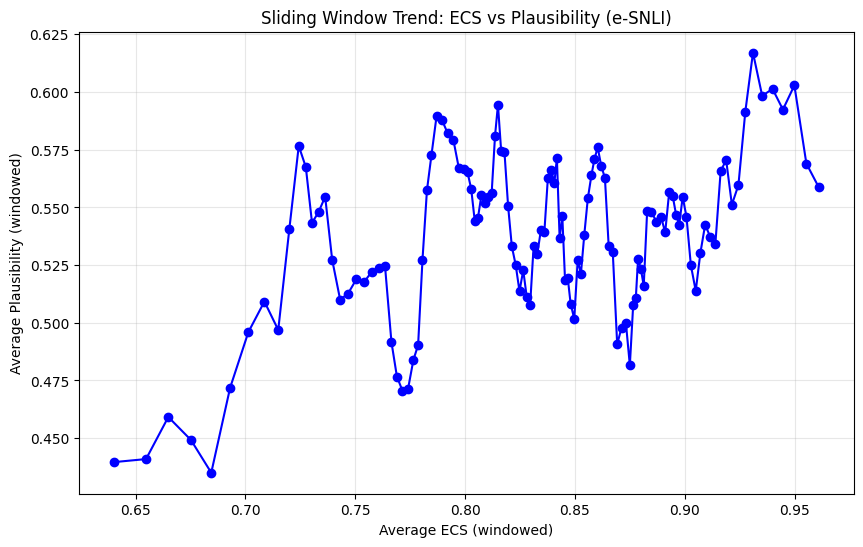

In [115]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Load files
# ============================================================
plaus_file = "esnli_llama_rationales_with_plausibility.csv"
ecs_file = "esnli_llama_rationales_with_ecs.csv"

plaus_df = pd.read_csv(plaus_file)
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]

print(f"📄 Loaded {len(plaus_df)} rows from plausibility file")
print(f"📄 Loaded {len(ecs_df)} rows from ECS file")


# ============================================================
# 2. Merge on id
# ============================================================
df = plaus_df.merge(ecs_df, on="id", how="inner")

# Convert numeric columns
df["plausibility"] = pd.to_numeric(df["plausibility"], errors="coerce")
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop NA
df = df.dropna(subset=["plausibility", "ECS"])

print(f"🔗 Final merged dataset: {len(df)} rows")


# ============================================================
# 3. Sort by ECS
# ============================================================
df = df.sort_values(by="ECS").reset_index(drop=True)


# ============================================================
# 4. Sliding window settings
# ============================================================
window_size = 30
step_size = 5

avg_ecs_list = []
avg_plaus_list = []


# ============================================================
# 5. Compute sliding-window averages
# ============================================================
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs = window["ECS"].mean()
    avg_plaus = window["plausibility"].mean()

    avg_ecs_list.append(avg_ecs)
    avg_plaus_list.append(avg_plaus)


# ============================================================
# 6. Visualization
# ============================================================
plt.figure(figsize=(10, 6))
plt.plot(avg_ecs_list, avg_plaus_list, marker='o', linestyle='-', color='blue')

plt.xlabel("Average ECS (windowed)")
plt.ylabel("Average Plausibility (windowed)")
plt.title("Sliding Window Trend: ECS vs Plausibility (e-SNLI)")
plt.grid(alpha=0.3)

plt.show()

📄 Loaded 627 plausibility rows
📄 Loaded 627 ECS rows
🔗 Final merged dataset: 627 rows
📊 ECS Bin Statistics
          ecs_bin   avg_ECS  avg_plausibility  count
0  (0.578, 0.608]  0.596069          0.345449      4
1  (0.608, 0.638]  0.631466          0.445802      9
2  (0.638, 0.668]  0.656863          0.391935     13
3  (0.668, 0.698]  0.683810          0.515552     15
4  (0.698, 0.728]  0.716647          0.502606     29


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_9093/1092451105.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby("ecs_bin").agg(


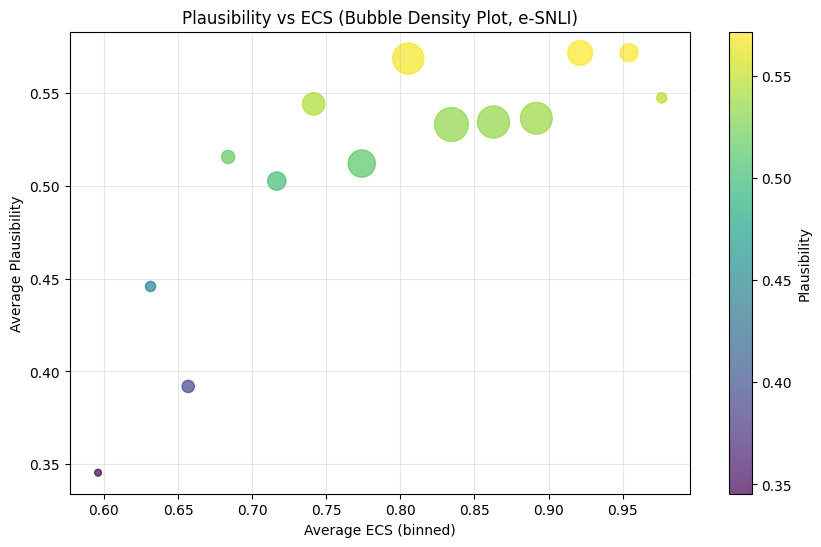

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================
# Load data
# ============================
plaus_file = "esnli_llama_rationales_with_plausibility.csv"
ecs_file = "esnli_llama_rationales_with_ecs.csv"

plaus_df = pd.read_csv(plaus_file)
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]

print(f"📄 Loaded {len(plaus_df)} plausibility rows")
print(f"📄 Loaded {len(ecs_df)} ECS rows")

# Merge ECS & plausibility into one dataset
df = plaus_df.merge(ecs_df, on="id", how="left")

# Convert columns to numeric
df["plausibility"] = pd.to_numeric(df["plausibility"], errors="coerce")
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop missing values
df = df.dropna(subset=["plausibility", "ECS"])

print(f"🔗 Final merged dataset: {len(df)} rows")


# ============================
# Bin ECS scores
# ============================
bin_width = 0.03 # same granularity as your original script
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

# ============================
# Compute statistics per bin
# ============================
bin_stats = df.groupby("ecs_bin").agg(
    avg_ECS=("ECS", "mean"),
    avg_plausibility=("plausibility", "mean"),
    count=("id", "count")
).reset_index()

# Remove empty bins (count = 0)
bin_stats = bin_stats.dropna(subset=["avg_ECS", "avg_plausibility", "count"])

print("📊 ECS Bin Statistics")
print(bin_stats.head())


# ============================
# Scatter Plot
# ============================
plt.figure(figsize=(10,6))
plt.scatter(
    bin_stats["avg_ECS"],
    bin_stats["avg_plausibility"],    # ⬅ REPLACED accuracy with plausibility
    s=bin_stats["count"] * 6,         # bubble size = density
    alpha=0.7,
    c=bin_stats["avg_plausibility"],   # optional: color by plausibility
    cmap="viridis"
)

plt.xlabel("Average ECS (binned)")
plt.ylabel("Average Plausibility")
plt.title("Plausibility vs ECS (Bubble Density Plot, e-SNLI)")
plt.grid(alpha=0.3)
plt.colorbar(label="Plausibility")
plt.show()


🔗 Final merged dataset: 627 rows


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_9093/3773335433.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby("ecs_bin")["id"].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_9093/3773335433.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby("ecs_bin")["ECS"].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_9093/3773335433.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend

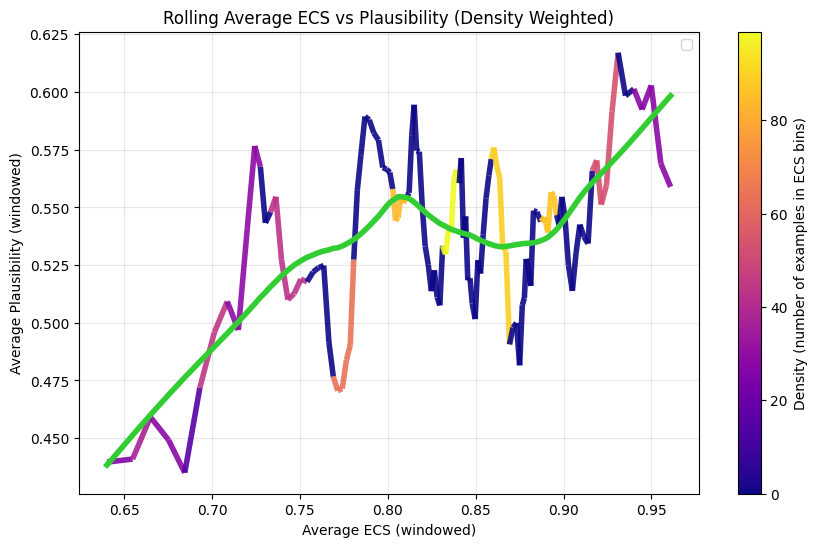

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths (YOUR FILES)
# -----------------------------
plaus_file = "esnli_llama_rationales_with_plausibility.csv"
ecs_file = "esnli_llama_rationales_with_ecs.csv"

# -----------------------------
# Load data
# -----------------------------
plaus_df = pd.read_csv(plaus_file)[["id", "plausibility"]]
ecs_df   = pd.read_csv(ecs_file)[["id", "ECS"]]

# Merge into one dataset
df = plaus_df.merge(ecs_df, on="id", how="inner")
df = df.sort_values("ECS").reset_index(drop=True)

# Ensure numeric
df["plausibility"] = pd.to_numeric(df["plausibility"], errors="coerce")
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop missing rows
df = df.dropna(subset=["plausibility", "ECS"])

print(f"🔗 Final merged dataset: {len(df)} rows")

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.03
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 30
step_size = 5

avg_ecs_list = []
avg_plaus_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_plaus_list.append(window["plausibility"].mean())

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()

    overlapping_bins = bin_stats[
        (bin_stats["bin_mid"] >= ecs_min) &
        (bin_stats["bin_mid"] <= ecs_max)
    ]

    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_plaus_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average ECS (windowed)")
ax.set_ylabel("Average Plausibility (windowed)")
ax.set_title("Rolling Average ECS vs Plausibility (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# LOWESS smoothing
# -----------------------------
density_threshold = np.percentile(window_density, 0)  # keep all data
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
plaus_high = np.array(avg_plaus_list)[mask]

smooth = lowess(plaus_high, ecs_high, frac=0.40, return_sorted=True)

smooth_ecs  = smooth[:, 0]
smooth_plaus = smooth[:, 1]

ax.plot(smooth_ecs, smooth_plaus, color="#32CD32", linewidth=4)

ax.legend()

plt.show()


🔗 Final merged dataset: 627 rows


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_9093/853090447.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby("ecs_bin")["id"].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_9093/853090447.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby("ecs_bin")["ECS"].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_9093/853090447.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


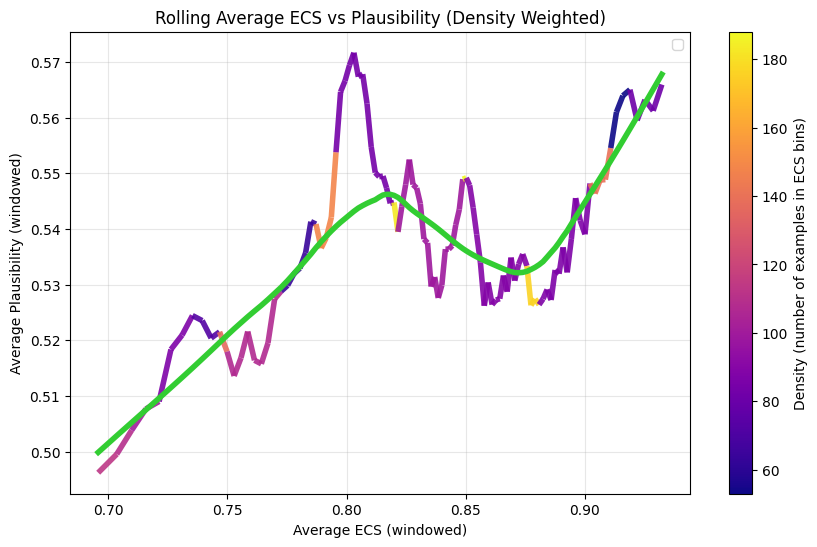

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths (YOUR FILES)
# -----------------------------
plaus_file = "esnli_llama_rationales_with_plausibility.csv"
ecs_file = "esnli_llama_rationales_with_ecs.csv"

# -----------------------------
# Load data
# -----------------------------
plaus_df = pd.read_csv(plaus_file)[["id", "plausibility"]]
ecs_df   = pd.read_csv(ecs_file)[["id", "ECS"]]

# Merge into one dataset
df = plaus_df.merge(ecs_df, on="id", how="inner")
df = df.sort_values("ECS").reset_index(drop=True)

# Ensure numeric
df["plausibility"] = pd.to_numeric(df["plausibility"], errors="coerce")
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop missing rows
df = df.dropna(subset=["plausibility", "ECS"])

print(f"🔗 Final merged dataset: {len(df)} rows")

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.03
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 100
step_size = 5

avg_ecs_list = []
avg_plaus_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_plaus_list.append(window["plausibility"].mean())

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()

    overlapping_bins = bin_stats[
        (bin_stats["bin_mid"] >= ecs_min) &
        (bin_stats["bin_mid"] <= ecs_max)
    ]

    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_plaus_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average ECS (windowed)")
ax.set_ylabel("Average Plausibility (windowed)")
ax.set_title("Rolling Average ECS vs Plausibility (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# LOWESS smoothing
# -----------------------------
density_threshold = np.percentile(window_density, 0)  # keep all data
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
plaus_high = np.array(avg_plaus_list)[mask]

smooth = lowess(plaus_high, ecs_high, frac=0.40, return_sorted=True)

smooth_ecs  = smooth[:, 0]
smooth_plaus = smooth[:, 1]

ax.plot(smooth_ecs, smooth_plaus, color="#32CD32", linewidth=4)

ax.legend()

plt.show()

In [17]:
import pandas as pd

df = pd.read_csv("esnli_train_1.csv")
df.columns


Index(['pairID', 'gold_label', 'Sentence1', 'Sentence2', 'Explanation_1',
       'WorkerId', 'Sentence1_marked_1', 'Sentence2_marked_1',
       'Sentence1_Highlighted_1', 'Sentence2_Highlighted_1'],
      dtype='object')

**"Lexical Repetition" -"Template Collapse"**

Hypothesis: "We hypothesize that smaller models achieve high ECS scores through rigid template adherence (parroting) rather than semantic stability."

Method: "To test this, we computed the Lexical Overlap between the original rationale and its perturbations."

**Qwen 2.5**

In [70]:
# =====================================================
# STEP 0: Import dependencies
# =====================================================
import pandas as pd
import numpy as np
import re
from itertools import combinations
from tqdm.notebook import tqdm

# =====================================================
# STEP 1: Configuration & Loading
# =====================================================
input_file = "qwen_esnli_rationales_filtered.csv"
output_file = "qwen_esnli_rationales_with_overlap.csv"

try:
    df = pd.read_csv(input_file)
    print(f"📄 Loaded {len(df)} rows from {input_file}")
except FileNotFoundError:
    print(f"❌ Error: Could not find file '{input_file}'. Please check your path.")
    # Create empty df to prevent crash if file missing
    df = pd.DataFrame()

# =====================================================
# STEP 2: Define CLEANING Function
# =====================================================
def clean_rationale(text):
    if not isinstance(text, str):
        return ""
    # Remove Chain-of-Thought
    text = re.sub(r"(?i)chain\s*of\s*thought\s*:", "", text).strip()
    # Remove Final Answer and everything after
    text = re.split(r"(?i)final\s*answer\s*:", text)[0].strip()
    return text

# =====================================================
# STEP 3: Apply Cleaning
# =====================================================
if not df.empty:
    print("✨ Cleaning rationales...")
    cols_to_clean = [
        "rationale_original", 
        "rationale_perturbation_1_lexical", 
        "rationale_perturbation_2_syntactic", 
        "rationale_perturbation_3_pragmatic"
    ]
    
    clean_cols = []
    for col in cols_to_clean:
        if col in df.columns:
            new_col = col + "_clean"
            df[new_col] = df[col].apply(clean_rationale)
            clean_cols.append(new_col)
        else:
            print(f"⚠️ Warning: Column {col} missing.")

    # =====================================================
    # STEP 4: Define Lexical Overlap Function (Jaccard)
    # =====================================================
    def compute_lexical_overlap(rationales):
        texts = [t for t in rationales if isinstance(t, str) and t.strip()]
        if len(texts) < 2:
            return np.nan

        def get_word_set(text):
            # Lowercase, remove special chars, split by whitespace
            clean_text = re.sub(r'[^a-zA-Z0-9\s]', '', text.lower())
            return set(clean_text.split())

        overlap_scores = []
        for a, b in combinations(texts, 2):
            set_a = get_word_set(a)
            set_b = get_word_set(b)
            
            intersection = len(set_a.intersection(set_b))
            union = len(set_a.union(set_b))
            
            if union == 0:
                overlap_scores.append(0.0)
            else:
                overlap_scores.append(intersection / union)

        return np.mean(overlap_scores)

    # =====================================================
    # STEP 5: Compute Overlap Loop
    # =====================================================
    overlap_values = []
    print("🔤 Computing Lexical Overlap...")
    
    for _, row in tqdm(df.iterrows(), total=len(df)):
        # Collect the 4 clean rationales
        current_rationales = [row[c] for c in clean_cols]
        overlap = compute_lexical_overlap(current_rationales)
        overlap_values.append(overlap)

    df["Lexical_Overlap"] = overlap_values

    # =====================================================
    # STEP 6: Save Result
    # =====================================================
    avg_overlap = np.nanmean(df["Lexical_Overlap"])
    print("-" * 40)
    print(f"🔍 RESULTS SUMMARY")
    print(f"   Average Lexical Overlap: {avg_overlap:.4f}")
    print("-" * 40)

    # Keep ID and Overlap for merging
    df_output = df[["id", "Lexical_Overlap"]]
    
    df_output.to_csv(output_file, index=False)
    print(f"💾 Saved Overlap data to: {output_file}")

📄 Loaded 627 rows from qwen_esnli_rationales_filtered.csv
✨ Cleaning rationales...
🔤 Computing Lexical Overlap...


  0%|          | 0/627 [00:00<?, ?it/s]

----------------------------------------
🔍 RESULTS SUMMARY
   Average Lexical Overlap: 0.5053
----------------------------------------
💾 Saved Overlap data to: qwen_esnli_rationales_with_overlap.csv


**Llama**

In [74]:
# =====================================================
# STEP 0: Import dependencies
# =====================================================
import pandas as pd
import numpy as np
import re
from itertools import combinations
from tqdm.notebook import tqdm

# =====================================================
# STEP 1: Configuration & Loading
# =====================================================
input_file = "esnli_llama_rationales_filtered.csv"
output_file = "esnli_llama_rationales_with_overlap.csv"

try:
    df = pd.read_csv(input_file)
    print(f"📄 Loaded {len(df)} rows from {input_file}")
except FileNotFoundError:
    print(f"❌ Error: Could not find file '{input_file}'.")
    df = pd.DataFrame()

# =====================================================
# STEP 2: Define CLEANING Function
# =====================================================
def clean_rationale(text):
    """
    Cleans rationales by removing 'Chain of Thought:' and 'Final Answer:'
    """
    if not isinstance(text, str):
        return ""

    # Remove Chain-of-Thought (case-insensitive)
    text = re.sub(r"(?i)chain\s*of\s*thought\s*:", "", text).strip()

    # Remove everything AFTER Final Answer (case-insensitive)
    text = re.split(r"(?i)final\s*answer\s*:", text)[0].strip()

    return text

# =====================================================
# STEP 3: Apply Cleaning
# =====================================================
print("✨ Cleaning rationales...")
df["rationale_original_clean"] = df["rationale_original"].apply(clean_rationale)
df["rationale_pert1_clean"] = df["rationale_lexical"].apply(clean_rationale)
df["rationale_pert2_clean"] = df["rationale_syntactic"].apply(clean_rationale)
df["rationale_pert3_clean"] = df["rationale_pragmatic"].apply(clean_rationale)

# =====================================================
# STEP 4: Define Lexical Overlap Function (Jaccard)
# =====================================================
def compute_lexical_overlap(rationales):
    """
    Computes the mean pairwise Jaccard Similarity (Word Overlap).
    Formula: Intersection / Union of unique words.
    
    Returns:
    1.0 = All words are identical (Template Collapse)
    0.0 = No shared words
    """
    # Filter for valid strings
    texts = [t for t in rationales if isinstance(t, str) and t.strip()]
    
    if len(texts) < 2:
        return np.nan

    # Tokenizer helper: Lowercase, remove special chars, split by whitespace
    def get_word_set(text):
        clean_text = re.sub(r'[^a-zA-Z0-9\s]', '', text.lower())
        return set(clean_text.split())

    overlap_scores = []
    
    # Calculate pairwise overlap for all combinations (6 pairs)
    for a, b in combinations(texts, 2):
        set_a = get_word_set(a)
        set_b = get_word_set(b)
        
        intersection = len(set_a.intersection(set_b))
        union = len(set_a.union(set_b))
        
        if union == 0:
            overlap_scores.append(0.0)
        else:
            overlap_scores.append(intersection / union)

    return np.mean(overlap_scores)

# =====================================================
# STEP 5: Compute Overlap Loop
# =====================================================
overlap_values = []

print("🔤 Computing Lexical Overlap (Template Check)...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    current_rationales = [
        row["rationale_original_clean"],
        row["rationale_pert1_clean"],
        row["rationale_pert2_clean"],
        row["rationale_pert3_clean"],
    ]
    
    overlap = compute_lexical_overlap(current_rationales)
    overlap_values.append(overlap)

df["Lexical_Overlap"] = overlap_values

# =====================================================
# STEP 6: Print Stats & Save
# =====================================================
avg_overlap = np.nanmean(df["Lexical_Overlap"])

print("-" * 40)
print(f"🔍 RESULTS SUMMARY")
print(f"   Average Lexical Overlap: {avg_overlap:.4f}")
print("-" * 40)
# Keep ID and Overlap for merging
df_output = df[["id", "Lexical_Overlap"]]
    
df_output.to_csv(output_file, index=False)
print(f"💾 Saved Overlap data to: {output_file}")

📄 Loaded 627 rows from esnli_llama_rationales_filtered.csv
✨ Cleaning rationales...
🔤 Computing Lexical Overlap (Template Check)...


  0%|          | 0/627 [00:00<?, ?it/s]

----------------------------------------
🔍 RESULTS SUMMARY
   Average Lexical Overlap: 0.4316
----------------------------------------
💾 Saved Overlap data to: esnli_llama_rationales_with_overlap.csv


**Gemini**

In [79]:
# =====================================================
# STEP 0: Import dependencies
# =====================================================



import pandas as pd
import numpy as np
import re
from itertools import combinations
from tqdm.notebook import tqdm

# =====================================================
# STEP 1: Configuration & Loading
# =====================================================
input_file = "esnli_gemini_rationales_filtered.csv"
output_file = "esnli_gemini_rationales_with_overlap.csv"

try:
    df = pd.read_csv(input_file)
    print(f"📄 Loaded {len(df)} rows from {input_file}")
except FileNotFoundError:
    print(f"❌ Error: Could not find file '{input_file}'.")
    df = pd.DataFrame()

# =====================================================
# STEP 2: Define CLEANING Function
# =====================================================
def clean_rationale(text):
    """
    Cleans rationales by removing 'Chain of Thought:' and 'Final Answer:'
    """
    if not isinstance(text, str):
        return ""

    # Remove Chain-of-Thought (case-insensitive)
    text = re.sub(r"(?i)chain\s*of\s*thought\s*:", "", text).strip()

    # Remove everything AFTER Final Answer (case-insensitive)
    text = re.split(r"(?i)final\s*answer\s*:", text)[0].strip()

    return text

# =====================================================
# STEP 3: Apply Cleaning
# =====================================================
print("✨ Cleaning rationales...")
df["rationale_original_clean"] = df["rationale_original"].apply(clean_rationale)
df["rationale_pert1_clean"] = df["rationale_pert1"].apply(clean_rationale)
df["rationale_pert2_clean"] = df["rationale_pert2"].apply(clean_rationale)
df["rationale_pert3_clean"] = df["rationale_pert3"].apply(clean_rationale)

# =====================================================
# STEP 4: Define Lexical Overlap Function (Jaccard)
# =====================================================
def compute_lexical_overlap(rationales):
    """
    Computes the mean pairwise Jaccard Similarity (Word Overlap).
    Formula: Intersection / Union of unique words.
    
    Returns:
    1.0 = All words are identical (Template Collapse)
    0.0 = No shared words
    """
    # Filter for valid strings
    texts = [t for t in rationales if isinstance(t, str) and t.strip()]
    
    if len(texts) < 2:
        return np.nan

    # Tokenizer helper: Lowercase, remove special chars, split by whitespace
    def get_word_set(text):
        clean_text = re.sub(r'[^a-zA-Z0-9\s]', '', text.lower())
        return set(clean_text.split())

    overlap_scores = []
    
    # Calculate pairwise overlap for all combinations (6 pairs)
    for a, b in combinations(texts, 2):
        set_a = get_word_set(a)
        set_b = get_word_set(b)
        
        intersection = len(set_a.intersection(set_b))
        union = len(set_a.union(set_b))
        
        if union == 0:
            overlap_scores.append(0.0)
        else:
            overlap_scores.append(intersection / union)

    return np.mean(overlap_scores)

# =====================================================
# STEP 5: Compute Overlap Loop
# =====================================================
overlap_values = []

print("🔤 Computing Lexical Overlap (Template Check)...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    current_rationales = [
        row["rationale_original_clean"],
        row["rationale_pert1_clean"],
        row["rationale_pert2_clean"],
        row["rationale_pert3_clean"],
    ]
    
    overlap = compute_lexical_overlap(current_rationales)
    overlap_values.append(overlap)

df["Lexical_Overlap"] = overlap_values

# =====================================================
# STEP 6: Print Stats & Save
# =====================================================
avg_overlap = np.nanmean(df["Lexical_Overlap"])

print("-" * 40)
print(f"🔍 RESULTS SUMMARY")
print(f"   Average Lexical Overlap: {avg_overlap:.4f}")
print("-" * 40)
df_output.to_csv(output_file, index=False)
print(f"💾 Saved Overlap data to: {output_file}")

📄 Loaded 627 rows from esnli_gemini_rationales_filtered.csv
✨ Cleaning rationales...
🔤 Computing Lexical Overlap (Template Check)...


  0%|          | 0/627 [00:00<?, ?it/s]

----------------------------------------
🔍 RESULTS SUMMARY
   Average Lexical Overlap: 0.3280
----------------------------------------
💾 Saved Overlap data to: esnli_gemini_rationales_with_overlap.csv


**POS score -Qwen 2.5**

In [82]:
!pip -q install spacy
!python -m spacy download en_core_web_sm

import spacy
import pandas as pd
import numpy as np
import re
from itertools import combinations
from tqdm.notebook import tqdm
from difflib import SequenceMatcher

# =====================================================
# CONFIGURATION
# =====================================================
input_file = "qwen_esnli_rationales_filtered.csv"  # Use your filtered file
output_file = "qwen_esnli_rationales_with_pos.csv"

# Load Spacy (Disable NER/Parser for speed)
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

# Load Data
try:
    df = pd.read_csv(input_file)
    print(f"📄 Loaded {len(df)} rows.")
except FileNotFoundError:
    print("❌ File not found.")
    df = pd.DataFrame()

# =====================================================
# HELPER: CLEAN RATIONALE
# =====================================================
def clean_rationale(text):
    if not isinstance(text, str): return ""
    text = re.sub(r"(?i)chain\s*of\s*thought\s*:", "", text).strip()
    text = re.split(r"(?i)final\s*answer\s*:", text)[0].strip()
    return text

# Apply cleaning
cols_to_clean = ["rationale_original", "rationale_perturbation_1_lexical", 
                 "rationale_perturbation_2_syntactic", "rationale_perturbation_3_pragmatic"]
clean_cols = []

for col in cols_to_clean:
    new_col = col + "_clean"
    df[new_col] = df[col].apply(clean_rationale)
    clean_cols.append(new_col)

# =====================================================
# CORE LOGIC: POS TEMPLATES
# =====================================================
def get_pos_sequence(text):
    """
    Converts text to POS tags.
    Input: "The cat sleeps."
    Output: "DET NOUN VERB PUNCT"
    """
    if not isinstance(text, str) or not text.strip():
        return ""
    
    doc = nlp(text)
    # Join tags into a single string for easy comparison
    return " ".join([token.pos_ for token in doc])

def compute_structural_stiffness(rationales):
    """
    Computes mean pairwise similarity of POS sequences.
    """
    valid_texts = [t for t in rationales if isinstance(t, str) and t.strip()]
    if len(valid_texts) < 2:
        return np.nan

    # 1. Convert all to POS strings
    pos_strings = [get_pos_sequence(t) for t in valid_texts]
    
    # 2. Compare using SequenceMatcher (Sensitive to order)
    ratios = []
    for a, b in combinations(pos_strings, 2):
        # .ratio() gives a score 0.0 to 1.0 based on how many edits needed
        ratios.append(SequenceMatcher(None, a, b).ratio())
        
    return np.mean(ratios)

# =====================================================
# EXECUTION LOOP
# =====================================================
stiffness_scores = []
pos_examples = []  # Store one example of POS string for inspection

print("🧬 Computing Structural Stiffness (POS Template Overlap)...")

for _, row in tqdm(df.iterrows(), total=len(df)):
    current_rationales = [row[c] for c in clean_cols]
    
    # Compute Score
    score = compute_structural_stiffness(current_rationales)
    stiffness_scores.append(score)
    
    # Store the POS sequence of the original rationale (for checking later)
    pos_examples.append(get_pos_sequence(current_rationales[0]))

df["POS_Stiffness"] = stiffness_scores
df["POS_Template_Example"] = pos_examples

# =====================================================
# RESULTS
# =====================================================
avg_stiffness = np.nanmean(df["POS_Stiffness"])

print("-" * 40)
print(f"🔍 RESULTS SUMMARY")
print(f"   Average Structural Stiffness (POS Overlap): {avg_stiffness:.4f}")
print("-" * 40)

# Save
df.to_csv(output_file, index=False)
print(f"💾 Saved to {output_file}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 4.0 MB/s eta 0:00:00m eta 0:00:010:00:01

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
📄 Loaded 627 rows.
🧬 Computing Structural Stiffness (POS Template Overlap)...


  0%|          | 0/627 [00:00<?, ?it/s]

----------------------------------------
🔍 RESULTS SUMMARY
   Average Structural Stiffness (POS Overlap): 0.5162
----------------------------------------
💾 Saved to qwen_esnli_rationales_with_pos.csv


**POS score -Gemini 2.5 pro**

In [86]:
!pip -q install spacy
!python -m spacy download en_core_web_sm

import spacy
import pandas as pd
import numpy as np
import re
from itertools import combinations
from tqdm.notebook import tqdm
from difflib import SequenceMatcher

# =====================================================
# CONFIGURATION
# =====================================================
input_file = "esnli_gemini_rationales_filtered.csv"
output_file = "esnli_gemini_rationales_with_pos.csv"

# Load Spacy (Disable NER/Parser for speed)
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

# Load Data
try:
    df = pd.read_csv(input_file)
    print(f"📄 Loaded {len(df)} rows.")
except FileNotFoundError:
    print("❌ File not found.")
    df = pd.DataFrame()

# =====================================================
# HELPER: CLEAN RATIONALE
# =====================================================
def clean_rationale(text):
    if not isinstance(text, str): return ""
    text = re.sub(r"(?i)chain\s*of\s*thought\s*:", "", text).strip()
    text = re.split(r"(?i)final\s*answer\s*:", text)[0].strip()
    return text

# Apply cleaning
cols_to_clean = ["rationale_original", "rationale_pert1", 
                 "rationale_pert2", "rationale_pert3"]
clean_cols = []

for col in cols_to_clean:
    new_col = col + "_clean"
    df[new_col] = df[col].apply(clean_rationale)
    clean_cols.append(new_col)

# =====================================================
# CORE LOGIC: POS TEMPLATES
# =====================================================
def get_pos_sequence(text):
    """
    Converts text to POS tags.
    Input: "The cat sleeps."
    Output: "DET NOUN VERB PUNCT"
    """
    if not isinstance(text, str) or not text.strip():
        return ""
    
    doc = nlp(text)
    # Join tags into a single string for easy comparison
    return " ".join([token.pos_ for token in doc])

def compute_structural_stiffness(rationales):
    """
    Computes mean pairwise similarity of POS sequences.
    """
    valid_texts = [t for t in rationales if isinstance(t, str) and t.strip()]
    if len(valid_texts) < 2:
        return np.nan

    # 1. Convert all to POS strings
    pos_strings = [get_pos_sequence(t) for t in valid_texts]
    
    # 2. Compare using SequenceMatcher (Sensitive to order)
    ratios = []
    for a, b in combinations(pos_strings, 2):
        # .ratio() gives a score 0.0 to 1.0 based on how many edits needed
        ratios.append(SequenceMatcher(None, a, b).ratio())
        
    return np.mean(ratios)

# =====================================================
# EXECUTION LOOP
# =====================================================
stiffness_scores = []
pos_examples = []  # Store one example of POS string for inspection

print("🧬 Computing Structural Stiffness (POS Template Overlap)...")

for _, row in tqdm(df.iterrows(), total=len(df)):
    current_rationales = [row[c] for c in clean_cols]
    
    # Compute Score
    score = compute_structural_stiffness(current_rationales)
    stiffness_scores.append(score)
    
    # Store the POS sequence of the original rationale (for checking later)
    pos_examples.append(get_pos_sequence(current_rationales[0]))

df["POS_Stiffness"] = stiffness_scores
df["POS_Template_Example"] = pos_examples

# =====================================================
# RESULTS
# =====================================================
avg_stiffness = np.nanmean(df["POS_Stiffness"])

print("-" * 40)
print(f"🔍 RESULTS SUMMARY")
print(f"   Average Structural Stiffness (POS Overlap): {avg_stiffness:.4f}")
print("-" * 40)

# Save
df.to_csv(output_file, index=False)
print(f"💾 Saved to {output_file}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 4.7 MB/s eta 0:00:00m eta 0:00:010:00:01

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
📄 Loaded 627 rows.
🧬 Computing Structural Stiffness (POS Template Overlap)...


  0%|          | 0/627 [00:00<?, ?it/s]

----------------------------------------
🔍 RESULTS SUMMARY
   Average Structural Stiffness (POS Overlap): 0.2662
----------------------------------------
💾 Saved to esnli_gemini_rationales_with_pos.csv


**POS score -Llama**

In [84]:
!pip -q install spacy
!python -m spacy download en_core_web_sm

import spacy
import pandas as pd
import numpy as np
import re
from itertools import combinations
from tqdm.notebook import tqdm
from difflib import SequenceMatcher

# =====================================================
# CONFIGURATION
# =====================================================
input_file = "esnli_llama_rationales_filtered.csv"
output_file = "esnli_llama_rationales_with_pos.csv"

# Load Spacy (Disable NER/Parser for speed)
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

# Load Data
try:
    df = pd.read_csv(input_file)
    print(f"📄 Loaded {len(df)} rows.")
except FileNotFoundError:
    print("❌ File not found.")
    df = pd.DataFrame()

# =====================================================
# HELPER: CLEAN RATIONALE
# =====================================================
def clean_rationale(text):
    if not isinstance(text, str): return ""
    text = re.sub(r"(?i)chain\s*of\s*thought\s*:", "", text).strip()
    text = re.split(r"(?i)final\s*answer\s*:", text)[0].strip()
    return text


# Apply cleaning
cols_to_clean = ["rationale_original", "rationale_lexical", 
                 "rationale_syntactic", "rationale_pragmatic"]
clean_cols = []

for col in cols_to_clean:
    new_col = col + "_clean"
    df[new_col] = df[col].apply(clean_rationale)
    clean_cols.append(new_col)

# =====================================================
# CORE LOGIC: POS TEMPLATES
# =====================================================
def get_pos_sequence(text):
    """
    Converts text to POS tags.
    Input: "The cat sleeps."
    Output: "DET NOUN VERB PUNCT"
    """
    if not isinstance(text, str) or not text.strip():
        return ""
    
    doc = nlp(text)
    # Join tags into a single string for easy comparison
    return " ".join([token.pos_ for token in doc])

def compute_structural_stiffness(rationales):
    """
    Computes mean pairwise similarity of POS sequences.
    """
    valid_texts = [t for t in rationales if isinstance(t, str) and t.strip()]
    if len(valid_texts) < 2:
        return np.nan

    # 1. Convert all to POS strings
    pos_strings = [get_pos_sequence(t) for t in valid_texts]
    
    # 2. Compare using SequenceMatcher (Sensitive to order)
    ratios = []
    for a, b in combinations(pos_strings, 2):
        # .ratio() gives a score 0.0 to 1.0 based on how many edits needed
        ratios.append(SequenceMatcher(None, a, b).ratio())
        
    return np.mean(ratios)

# =====================================================
# EXECUTION LOOP
# =====================================================
stiffness_scores = []
pos_examples = []  # Store one example of POS string for inspection

print("🧬 Computing Structural Stiffness (POS Template Overlap)...")

for _, row in tqdm(df.iterrows(), total=len(df)):
    current_rationales = [row[c] for c in clean_cols]
    
    # Compute Score
    score = compute_structural_stiffness(current_rationales)
    stiffness_scores.append(score)
    
    # Store the POS sequence of the original rationale (for checking later)
    pos_examples.append(get_pos_sequence(current_rationales[0]))

df["POS_Stiffness"] = stiffness_scores
df["POS_Template_Example"] = pos_examples

# =====================================================
# RESULTS
# =====================================================
avg_stiffness = np.nanmean(df["POS_Stiffness"])

print("-" * 40)
print(f"🔍 RESULTS SUMMARY")
print(f"   Average Structural Stiffness (POS Overlap): {avg_stiffness:.4f}")
print("-" * 40)

# Save
df.to_csv(output_file, index=False)
print(f"💾 Saved to {output_file}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 4.1 MB/s eta 0:00:00m eta 0:00:010:01:01

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
📄 Loaded 627 rows.
🧬 Computing Structural Stiffness (POS Template Overlap)...


  0%|          | 0/627 [00:00<?, ?it/s]

----------------------------------------
🔍 RESULTS SUMMARY
   Average Structural Stiffness (POS Overlap): 0.4081
----------------------------------------
💾 Saved to esnli_llama_rationales_with_pos.csv


In [37]:
# =====================================================
# STEP 0: Dependencies
# =====================================================
import pandas as pd
import numpy as np
import re
import nltk
# Ensure punkt is downloaded for sentence tokenization
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) 
from nltk.tokenize import sent_tokenize

# =====================================================
# STEP 1: Load Data
# =====================================================
input_file = "qwen_esnli_rationales_filtered.csv"  # Loading your base file
# If you want to use the file you just created with POS tags, change to:
# input_file = "qwen_esnli_rationales_with_pos.csv"

try:
    df = pd.read_csv(input_file)
    print(f"📄 Loaded {len(df)} rows from {input_file}")
except FileNotFoundError:
    print(f"❌ Error: Could not find file '{input_file}'")
    df = pd.DataFrame()

# =====================================================
# STEP 2: Clean Rationales (Crucial for Pattern Match)
# =====================================================
def clean_rationale(text):
    if not isinstance(text, str): return ""
    # Remove Chain of Thought
    text = re.sub(r"(?i)chain\s*of\s*thought\s*:", "", text).strip()
    # Remove Final Answer and everything after
    text = re.split(r"(?i)final\s*answer\s*:", text)[0].strip()
    return text

print("✨ Cleaning rationales...")
cols_to_clean = [
    "rationale_original", 
    "rationale_perturbation_1_lexical", 
    "rationale_perturbation_2_syntactic", 
    "rationale_perturbation_3_pragmatic"
]

clean_cols = []
for col in cols_to_clean:
    new_col = col + "_clean"
    # Check if column exists before applying
    if col in df.columns:
        df[new_col] = df[col].apply(clean_rationale)
        clean_cols.append(new_col)
    else:
        print(f"⚠️ Warning: Column {col} not found in CSV.")

# =====================================================
# STEP 3: Define Pattern Extractor
# =====================================================
def extract_discourse_pattern(text):
    """
    Extracts the first 2 words of every sentence.
    Input: "The premise states X. However, the hypothesis says Y."
    Output: "the premise | however the"
    """
    if not isinstance(text, str) or not text.strip(): 
        return "EMPTY"
    
    try:
        # Split into sentences
        sentences = sent_tokenize(text)
    except Exception:
        # Fallback if nltk fails
        sentences = text.split('.')
    
    # Get first 2 words of each sentence (lowercase)
    openers = []
    for s in sentences:
        words = s.strip().split()
        if len(words) >= 2:
            openers.append(" ".join(words[:2]).lower())
        elif len(words) == 1:
            openers.append(words[0].lower())
            
    if not openers:
        return "EMPTY"
        
    return " | ".join(openers)

# =====================================================
# STEP 4: Apply to ALL Columns
# =====================================================
print("🕵️‍♂️ Extracting Discourse Patterns...")

pattern_cols = []
for col in clean_cols:
    new_col = col + "_pattern"
    df[new_col] = df[col].apply(extract_discourse_pattern)
    pattern_cols.append(new_col)

# =====================================================
# STEP 5: Analysis A - Global Dominance
# =====================================================
# Combine all 4 columns into one long series to see the "Global Mindset"
all_patterns = pd.concat([df[c] for c in pattern_cols])

# Count frequency
if len(all_patterns) > 0:
    pattern_counts = all_patterns.value_counts(normalize=True)
    top_pattern = pattern_counts.index[0]
    top_freq = pattern_counts.iloc[0]
else:
    top_pattern = "N/A"
    top_freq = 0.0

print("-" * 40)
print("🌍 GLOBAL TEMPLATE DOMINANCE (Robot Score)")
print("-" * 40)
print(f"Top Pattern: '{top_pattern}'")
print(f"Frequency:   {top_freq:.2%} (of ALL rationales generated)")
print("-" * 40)

# =====================================================
# STEP 6: Analysis B - Row-wise Collapse
# =====================================================
# Check if a single row uses the exact same pattern for ALL 4 versions

def check_row_collapse(row):
    # Gather the 4 patterns for this specific example
    patterns = [row[c] for c in pattern_cols]
    # If they are all identical, return 1
    return 1 if len(set(patterns)) == 1 else 0

df['pattern_collapsed'] = df.apply(check_row_collapse, axis=1)
pct_collapsed = df['pattern_collapsed'].mean()

print("\n🔒 ROW-WISE REASONING COLLAPSE (Stubbornness Score)")
print("-" * 40)
print(f"Percentage of rows where ALL 4 perturbations")
print(f"use the EXACT same discourse structure:")
print(f"👉 {pct_collapsed:.2%}")
print("-" * 40)

# Optional: Save results to inspect
# df.to_csv("qwen_discourse_analysis.csv", index=False)

📄 Loaded 627 rows from qwen_esnli_rationales_filtered.csv
✨ Cleaning rationales...
🕵️‍♂️ Extracting Discourse Patterns...
----------------------------------------
🌍 GLOBAL TEMPLATE DOMINANCE (Robot Score)
----------------------------------------
Top Pattern: 'the premise | therefore, the'
Frequency:   28.63% (of ALL rationales generated)
----------------------------------------

🔒 ROW-WISE REASONING COLLAPSE (Stubbornness Score)
----------------------------------------
Percentage of rows where ALL 4 perturbations
use the EXACT same discourse structure:
👉 11.96%
----------------------------------------


In [38]:
# =====================================================
# STEP 0: Dependencies
# =====================================================
import pandas as pd
import numpy as np
import re
import nltk
# Ensure punkt is downloaded for sentence tokenization
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) 
from nltk.tokenize import sent_tokenize

# =====================================================
# STEP 1: Load Data
# =====================================================
input_file = "esnli_gemini_rationales_filtered.csv"  # Loading your base file
# If you want to use the file you just created with POS tags, change to:
# input_file = "qwen_esnli_rationales_with_pos.csv"

try:
    df = pd.read_csv(input_file)
    print(f"📄 Loaded {len(df)} rows from {input_file}")
except FileNotFoundError:
    print(f"❌ Error: Could not find file '{input_file}'")
    df = pd.DataFrame()

# =====================================================
# STEP 2: Clean Rationales (Crucial for Pattern Match)
# =====================================================
def clean_rationale(text):
    if not isinstance(text, str): return ""
    # Remove Chain of Thought
    text = re.sub(r"(?i)chain\s*of\s*thought\s*:", "", text).strip()
    # Remove Final Answer and everything after
    text = re.split(r"(?i)final\s*answer\s*:", text)[0].strip()
    return text

print("✨ Cleaning rationales...")
cols_to_clean = [
    "rationale_original", 
    "rationale_pert1", 
    "rationale_pert2", 
    "rationale_pert3"
]

clean_cols = []
for col in cols_to_clean:
    new_col = col + "_clean"
    # Check if column exists before applying
    if col in df.columns:
        df[new_col] = df[col].apply(clean_rationale)
        clean_cols.append(new_col)
    else:
        print(f"⚠️ Warning: Column {col} not found in CSV.")

# =====================================================
# STEP 3: Define Pattern Extractor
# =====================================================
def extract_discourse_pattern(text):
    """
    Extracts the first 2 words of every sentence.
    Input: "The premise states X. However, the hypothesis says Y."
    Output: "the premise | however the"
    """
    if not isinstance(text, str) or not text.strip(): 
        return "EMPTY"
    
    try:
        # Split into sentences
        sentences = sent_tokenize(text)
    except Exception:
        # Fallback if nltk fails
        sentences = text.split('.')
    
    # Get first 2 words of each sentence (lowercase)
    openers = []
    for s in sentences:
        words = s.strip().split()
        if len(words) >= 2:
            openers.append(" ".join(words[:2]).lower())
        elif len(words) == 1:
            openers.append(words[0].lower())
            
    if not openers:
        return "EMPTY"
        
    return " | ".join(openers)

# =====================================================
# STEP 4: Apply to ALL Columns
# =====================================================
print("🕵️‍♂️ Extracting Discourse Patterns...")

pattern_cols = []
for col in clean_cols:
    new_col = col + "_pattern"
    df[new_col] = df[col].apply(extract_discourse_pattern)
    pattern_cols.append(new_col)

# =====================================================
# STEP 5: Analysis A - Global Dominance
# =====================================================
# Combine all 4 columns into one long series to see the "Global Mindset"
all_patterns = pd.concat([df[c] for c in pattern_cols])

# Count frequency
if len(all_patterns) > 0:
    pattern_counts = all_patterns.value_counts(normalize=True)
    top_pattern = pattern_counts.index[0]
    top_freq = pattern_counts.iloc[0]
else:
    top_pattern = "N/A"
    top_freq = 0.0

print("-" * 40)
print("🌍 GLOBAL TEMPLATE DOMINANCE (Robot Score)")
print("-" * 40)
print(f"Top Pattern: '{top_pattern}'")
print(f"Frequency:   {top_freq:.2%} (of ALL rationales generated)")
print("-" * 40)

# =====================================================
# STEP 6: Analysis B - Row-wise Collapse
# =====================================================
# Check if a single row uses the exact same pattern for ALL 4 versions

def check_row_collapse(row):
    # Gather the 4 patterns for this specific example
    patterns = [row[c] for c in pattern_cols]
    # If they are all identical, return 1
    return 1 if len(set(patterns)) == 1 else 0

df['pattern_collapsed'] = df.apply(check_row_collapse, axis=1)
pct_collapsed = df['pattern_collapsed'].mean()

print("\n🔒 ROW-WISE REASONING COLLAPSE (Stubbornness Score)")
print("-" * 40)
print(f"Percentage of rows where ALL 4 perturbations")
print(f"use the EXACT same discourse structure:")
print(f"👉 {pct_collapsed:.2%}")
print("-" * 40)

# Optional: Save results to inspect
# df.to_csv("qwen_discourse_analysis.csv", index=False)

📄 Loaded 627 rows from esnli_gemini_rationales_filtered.csv
✨ Cleaning rationales...
🕵️‍♂️ Extracting Discourse Patterns...
----------------------------------------
🌍 GLOBAL TEMPLATE DOMINANCE (Robot Score)
----------------------------------------
Top Pattern: 'the premise | the hypothesis | therefore, the'
Frequency:   3.67% (of ALL rationales generated)
----------------------------------------

🔒 ROW-WISE REASONING COLLAPSE (Stubbornness Score)
----------------------------------------
Percentage of rows where ALL 4 perturbations
use the EXACT same discourse structure:
👉 0.00%
----------------------------------------


In [39]:
# =====================================================
# STEP 0: Dependencies
# =====================================================
import pandas as pd
import numpy as np
import re
import nltk
# Ensure punkt is downloaded for sentence tokenization
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) 
from nltk.tokenize import sent_tokenize

# =====================================================
# STEP 1: Load Data
# =====================================================
input_file = "esnli_llama_rationales_filtered.csv"  # Loading your base file
# If you want to use the file you just created with POS tags, change to:
# input_file = "qwen_esnli_rationales_with_pos.csv"

try:
    df = pd.read_csv(input_file)
    print(f"📄 Loaded {len(df)} rows from {input_file}")
except FileNotFoundError:
    print(f"❌ Error: Could not find file '{input_file}'")
    df = pd.DataFrame()

# =====================================================
# STEP 2: Clean Rationales (Crucial for Pattern Match)
# =====================================================
def clean_rationale(text):
    if not isinstance(text, str): return ""
    # Remove Chain of Thought
    text = re.sub(r"(?i)chain\s*of\s*thought\s*:", "", text).strip()
    # Remove Final Answer and everything after
    text = re.split(r"(?i)final\s*answer\s*:", text)[0].strip()
    return text

print("✨ Cleaning rationales...")
cols_to_clean = [
    "rationale_original", 
    "rationale_lexical", 
    "rationale_syntactic", 
    "rationale_pragmatic"
]

clean_cols = []
for col in cols_to_clean:
    new_col = col + "_clean"
    # Check if column exists before applying
    if col in df.columns:
        df[new_col] = df[col].apply(clean_rationale)
        clean_cols.append(new_col)
    else:
        print(f"⚠️ Warning: Column {col} not found in CSV.")

# =====================================================
# STEP 3: Define Pattern Extractor
# =====================================================
def extract_discourse_pattern(text):
    """
    Extracts the first 2 words of every sentence.
    Input: "The premise states X. However, the hypothesis says Y."
    Output: "the premise | however the"
    """
    if not isinstance(text, str) or not text.strip(): 
        return "EMPTY"
    
    try:
        # Split into sentences
        sentences = sent_tokenize(text)
    except Exception:
        # Fallback if nltk fails
        sentences = text.split('.')
    
    # Get first 2 words of each sentence (lowercase)
    openers = []
    for s in sentences:
        words = s.strip().split()
        if len(words) >= 2:
            openers.append(" ".join(words[:2]).lower())
        elif len(words) == 1:
            openers.append(words[0].lower())
            
    if not openers:
        return "EMPTY"
        
    return " | ".join(openers)

# =====================================================
# STEP 4: Apply to ALL Columns
# =====================================================
print("🕵️‍♂️ Extracting Discourse Patterns...")

pattern_cols = []
for col in clean_cols:
    new_col = col + "_pattern"
    df[new_col] = df[col].apply(extract_discourse_pattern)
    pattern_cols.append(new_col)

# =====================================================
# STEP 5: Analysis A - Global Dominance
# =====================================================
# Combine all 4 columns into one long series to see the "Global Mindset"
all_patterns = pd.concat([df[c] for c in pattern_cols])

# Count frequency
if len(all_patterns) > 0:
    pattern_counts = all_patterns.value_counts(normalize=True)
    top_pattern = pattern_counts.index[0]
    top_freq = pattern_counts.iloc[0]
else:
    top_pattern = "N/A"
    top_freq = 0.0

print("-" * 40)
print("🌍 GLOBAL TEMPLATE DOMINANCE (Robot Score)")
print("-" * 40)
print(f"Top Pattern: '{top_pattern}'")
print(f"Frequency:   {top_freq:.2%} (of ALL rationales generated)")
print("-" * 40)

# =====================================================
# STEP 6: Analysis B - Row-wise Collapse
# =====================================================
# Check if a single row uses the exact same pattern for ALL 4 versions

def check_row_collapse(row):
    # Gather the 4 patterns for this specific example
    patterns = [row[c] for c in pattern_cols]
    # If they are all identical, return 1
    return 1 if len(set(patterns)) == 1 else 0

df['pattern_collapsed'] = df.apply(check_row_collapse, axis=1)
pct_collapsed = df['pattern_collapsed'].mean()

print("\n🔒 ROW-WISE REASONING COLLAPSE (Stubbornness Score)")
print("-" * 40)
print(f"Percentage of rows where ALL 4 perturbations")
print(f"use the EXACT same discourse structure:")
print(f"👉 {pct_collapsed:.2%}")
print("-" * 40)

# Optional: Save results to inspect
# df.to_csv("qwen_discourse_analysis.csv", index=False)

📄 Loaded 627 rows from esnli_llama_rationales_filtered.csv
✨ Cleaning rationales...
🕵️‍♂️ Extracting Discourse Patterns...
----------------------------------------
🌍 GLOBAL TEMPLATE DOMINANCE (Robot Score)
----------------------------------------
Top Pattern: 'the premise | therefore, the'
Frequency:   10.96% (of ALL rationales generated)
----------------------------------------

🔒 ROW-WISE REASONING COLLAPSE (Stubbornness Score)
----------------------------------------
Percentage of rows where ALL 4 perturbations
use the EXACT same discourse structure:
👉 4.63%
----------------------------------------


**Mistral**

In [120]:
import pandas as pd

# IDs to remove
ids_to_remove = [
    3, 4, 5, 9,10, 40, 43, 47, 49, 57, 60, 61, 62, 72, 73, 76, 94, 96, 98, 100, 
    105, 113, 115, 116, 118, 121, 129, 139, 140, 145, 147, 149, 153, 155, 158, 
    162, 163, 166, 172, 176, 178, 192, 197, 201, 203,206,216, 221, 222, 226, 233, 
    239, 240, 241, 244, 246, 248, 254, 257, 266, 268, 273, 278, 283, 287, 292, 
    293, 296, 303, 304, 309, 313, 317, 325, 331, 336,338, 344, 350, 354, 359, 363, 
    364, 380, 391, 392, 396, 398, 406, 408, 418, 419, 423, 426, 427, 428, 436, 
    438, 439, 440, 441, 451, 455, 464, 465, 466, 469, 471, 477, 478, 480, 482, 
    488, 494, 498, 515, 518, 520, 521, 522, 523, 525, 527, 528, 533, 534, 536, 
    537, 552, 554, 566, 571, 572, 576, 582, 585, 595, 601, 608, 621, 630, 638, 
    645, 651, 653, 658, 663, 669, 675, 678, 682, 686, 687, 688, 690, 696, 710, 
    716, 717, 730, 732,734,735, 739, 750, 756, 758, 766, 773, 778, 783, 785, 787, 
    788, 789, 791, 792
]

# Load original file
df = pd.read_csv("esnli_mistral_rationales.csv")

# Filter out rows where id is in ids_to_remove
df_filtered = df[~df["id"].isin(ids_to_remove)]

# Save the result
output_file = "esnli_mistral_rationales_filtered.csv"
df_filtered.to_csv(output_file, index=False)

print(f"✅ Filtering complete.")
print(f"🔢 Original rows: {len(df)}")
print(f"🔢 Rows removed: {len(ids_to_remove)}")
print(f"🔢 Final rows: {len(df_filtered)}")
print(f"💾 Saved to: {output_file}")


✅ Filtering complete.
🔢 Original rows: 800
🔢 Rows removed: 177
🔢 Final rows: 623
💾 Saved to: esnli_mistral_rationales_filtered.csv


**extract final answers of mistral rationales**

In [121]:
import pandas as pd
import re

def extract_final_answers(input_csv="esnli_mistral_rationales_filtered.csv",
                          output_csv="esnli_mistral_final_answers.csv"):
    """
    Loads the e-SNLI Gemini rationales file, extracts the 'Final Answer' label
    from each rationale column, and saves a new CSV with only those answers.
    
    Assumes input columns: 
        id, rationale_original, rationale_pert1, rationale_pert2, rationale_pert3
    """

    # Load dataset
    df = pd.read_csv(input_csv)

    # Regex to capture: Final Answer: LABEL
    pattern = r"Final Answer:\s*([A-Z]+)"

    # Columns that contain rationales
    rationale_cols = ["rationale_original", "rationale_lexical", "rationale_syntactic", "rationale_pragmatic"]

    # Create new columns with extracted labels
    for col in rationale_cols:
        df[col + "_final"] = df[col].apply(
            lambda x: re.search(pattern, x).group(1) if isinstance(x, str) and re.search(pattern, x) else None
        )

    # Create final dataframe with only id + extracted answers
    final_cols = ["id"] + [col + "_final" for col in rationale_cols]
    df_final = df[final_cols]

    # Save to new CSV
    df_final.to_csv(output_csv, index=False)

    return df_final

# Run the function (creates the new CSV)
df_results = extract_final_answers()
df_results.head()

,id,rationale_original_final,rationale_lexical_final,rationale_syntactic_final,rationale_pragmatic_final
0,1,NEUTRAL,NEUTRAL,NEUTRAL,NEUTRAL
1,2,NEUTRAL,NEUTRAL,NEUTRAL,NEUTRAL
2,6,ENTAILMENT,NEUTRAL,NEUTRAL,NEUTRAL
3,7,ENTAILMENT,ENTAILMENT,ENTAILMENT,ENTAILMENT
4,8,ENTAILMENT,ENTAILMENT,ENTAILMENT,ENTAILMENT


**Mistral-ECS**

In [122]:
!pip -q install sentence-transformers tqdm

import pandas as pd
import numpy as np
from itertools import combinations
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer

# =====================================================
# STEP 1: Load the file
# =====================================================
input_file = "esnli_mistral_rationales_filtered.csv"
output_file = "esnli_mistral_rationales_with_ecs.csv"

df = pd.read_csv(input_file)
print(f"📄 Loaded {len(df)} rows from {input_file}")


# =====================================================
# STEP 2: Define CLEANING function
# =====================================================
def clean_rationale(text):
    """
    Removes boilerplate such as 'Chain of Thought:' and 
    everything after 'Final Answer:'.
    """
    if not isinstance(text, str):
        return ""

    text = text.replace("Chain of Thought:", "").strip()

    if "Final Answer:" in text:
        text = text.split("Final Answer:")[0].strip()

    return text


# =====================================================
# STEP 3: Clean all rationales BEFORE computing ECS
# =====================================================
print("✨ Cleaning rationales before ECS computation...")

df["rationale_original_clean"] = df["rationale_original"].apply(clean_rationale)
df["rationale_pert1_clean"] = df["rationale_lexical"].apply(clean_rationale)
df["rationale_pert2_clean"] = df["rationale_syntactic"].apply(clean_rationale)
df["rationale_pert3_clean"] = df["rationale_pragmatic"].apply(clean_rationale)


# =====================================================
# STEP 4: Initialize embedding model
# =====================================================
print("🚀 Loading embedding model: all-MiniLM-L6-v2 ...")
model = SentenceTransformer("all-MiniLM-L6-v2")


# =====================================================
# STEP 5: Semantic ECS computation function
# =====================================================
def compute_ecs_semantic(rationales):
    """
    Compute Explanation Consistency Score (semantic meaning)
    = mean cosine similarity between all pairs of cleaned explanations.
    """
    texts = [t for t in rationales if isinstance(t, str) and t.strip()]
    if len(texts) < 2:
        return np.nan

    pairs = list(combinations(texts, 2))
    sim_scores = []

    for a, b in pairs:
        emb = model.encode([a, b], normalize_embeddings=True)
        sim = float(np.dot(emb[0], emb[1]))
        sim_scores.append(sim)

    return np.mean(sim_scores)


# =====================================================
# STEP 6: Compute ECS using CLEANED rationales
# =====================================================
ecs_values = []

print("🧮 Computing ECS (semantic consistency) for each example...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    ecs = compute_ecs_semantic([
        row["rationale_original_clean"],
        row["rationale_pert1_clean"],
        row["rationale_pert2_clean"],
        row["rationale_pert3_clean"],
    ])
    ecs_values.append(ecs)

df["ECS"] = ecs_values


# =====================================================
# STEP 7: Print overall ECS
# =====================================================
overall_ecs = np.nanmean(df["ECS"])
print(f"\n🔍 Average Explanation Consistency Score (ECS): {overall_ecs:.4f}")


# =====================================================
# STEP 8: Save results
# =====================================================
df.to_csv(output_file, index=False)
print(f"💾 Saved ECS-annotated file to {output_file}")



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
📄 Loaded 623 rows from esnli_mistral_rationales_filtered.csv
✨ Cleaning rationales before ECS computation...
🚀 Loading embedding model: all-MiniLM-L6-v2 ...
🧮 Computing ECS (semantic consistency) for each example...


  0%|          | 0/623 [00:00<?, ?it/s]


🔍 Average Explanation Consistency Score (ECS): 0.8111
💾 Saved ECS-annotated file to esnli_mistral_rationales_with_ecs.csv


In [123]:
import pandas as pd

# ============================
# Load input files
# ============================
rationales_file = "esnli_mistral_rationales_filtered.csv"
perturb_file = "esnli_800_with_perturbations.csv"

df_r = pd.read_csv(rationales_file)
df_p = pd.read_csv(perturb_file)

print(f"📄 Loaded {len(df_r)} rows from {rationales_file}")
print(f"📄 Loaded {len(df_p)} rows from {perturb_file}")

# ============================
# Keep only id + Explanation from perturb file
# ============================
df_p = df_p[["id", "Explanation"]]

# ============================
# Merge based on id
# ============================
df_merged = df_r.merge(df_p, on="id", how="left")

print(f"🔗 Merge complete. Final rows: {len(df_merged)}")

# ============================
# Save output
# ============================
output_file = "esnli_mistral_rationales_filtered_with_explanations.csv"
df_merged.to_csv(output_file, index=False)

print(f"💾 Saved merged file to {output_file}")

📄 Loaded 623 rows from esnli_mistral_rationales_filtered.csv
📄 Loaded 800 rows from esnli_800_with_perturbations.csv
🔗 Merge complete. Final rows: 623
💾 Saved merged file to esnli_mistral_rationales_filtered_with_explanations.csv


In [124]:
!pip -q install sentence-transformers tqdm

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer

# ============================================================
# 1. Load the file
# ============================================================
input_file = "esnli_mistral_rationales_filtered_with_explanations.csv"
output_file = "esnli_mistral_rationales_with_plausibility.csv"

df = pd.read_csv(input_file)
print(f"📄 Loaded {len(df)} rows from {input_file}")


# ============================================================
# 2. Clean rationale function
# ============================================================
def clean_rationale(text):
    """
    Removes boilerplate such as 'Chain of Thought:' and 
    everything after 'Final Answer:'.
    """
    if not isinstance(text, str):
        return ""

    text = text.replace("Chain of Thought:", "").strip()

    if "Final Answer:" in text:
        text = text.split("Final Answer:")[0].strip()

    return text


# ============================================================
# 3. Create cleaned rationale column
# ============================================================
print("✨ Cleaning original rationales...")
df["rationale_original_cleaned"] = df["rationale_original"].apply(clean_rationale)


# ============================================================
# 4. Load embedding model
# ============================================================
print("🔍 Loading embedding model: all-MiniLM-L6-v2 ...")
model = SentenceTransformer("all-MiniLM-L6-v2")


# ============================================================
# 5. Compute plausibility (semantic similarity)
# ============================================================
def compute_plausibility(model_expl, human_expl):
    """
    Computes cosine similarity between cleaned LLM rationale
    and human-written explanation.
    """
    if not isinstance(model_expl, str) or not model_expl.strip():
        return np.nan
    if not isinstance(human_expl, str) or not human_expl.strip():
        return np.nan

    emb = model.encode([model_expl, human_expl], normalize_embeddings=True)
    return float(np.dot(emb[0], emb[1]))


print("🧮 Computing plausibility scores...")
tqdm.pandas()

df["plausibility"] = df.progress_apply(
    lambda row: compute_plausibility(row["rationale_original_cleaned"], row["Explanation"]),
    axis=1
)


# ============================================================
# 6. Keep only required columns
# ============================================================
df_output = df[["id", "rationale_original_cleaned", "Explanation", "plausibility"]]


# ============================================================
# 7. Save results
# ============================================================
df_output.to_csv(output_file, index=False)
print(f"💾 Saved cleaned + plausibility dataset to {output_file}")

# Show sample
display(df_output.head())

# ============================================================
# 8. Print average plausibility
# ============================================================
avg_plausibility = df_output["plausibility"].mean()
print(f"\n🔍 Average Plausibility Score: {avg_plausibility:.4f}")


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
📄 Loaded 623 rows from esnli_mistral_rationales_filtered_with_explanations.csv
✨ Cleaning original rationales...
🔍 Loading embedding model: all-MiniLM-L6-v2 ...
🧮 Computing plausibility scores...


  0%|          | 0/623 [00:00<?, ?it/s]

💾 Saved cleaned + plausibility dataset to esnli_mistral_rationales_with_plausibility.csv


,id,rationale_original_cleaned,Explanation,plausibility
0,1,1. The premise describes a woman cooking in a ...,The apron is either blue or pink. The woman ca...,0.695732
1,2,"1. The action of ""smiling"" is not exclusive to...",The young man is either at school or in the sand.,0.295913
2,6,1. A nightclub is a place where people gather ...,A nightclub might include a bar but a bar is n...,0.647735
3,7,The premise describes a specific instance of a...,A young woman shoots a gun in target range,0.463796
4,8,The premise explicitly states that the man is ...,jumping implies leaps,0.511408



🔍 Average Plausibility Score: 0.5701


**Mistral ECS-Plausibility**

🔗 Successfully merged. Final dataset has 623 rows.


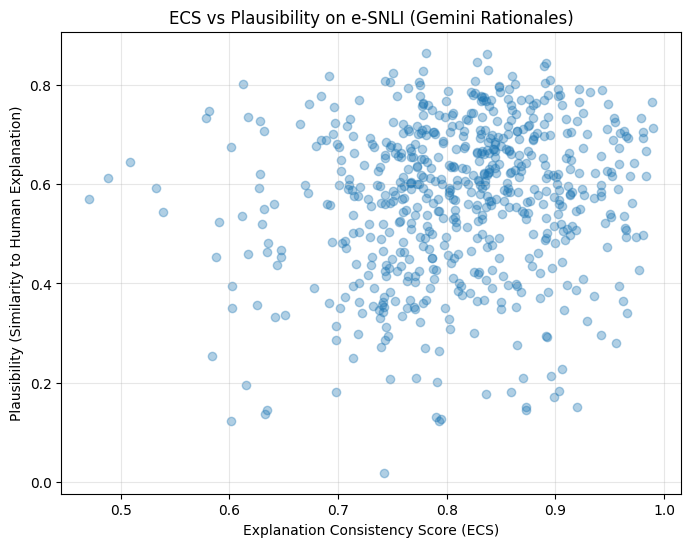

In [125]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Load the two CSV files
# ============================================================
plaus_file = "esnli_mistral_rationales_with_plausibility.csv"
ecs_file = "esnli_mistral_rationales_with_ecs.csv"

df_rationales = pd.read_csv(plaus_file)
df_ecs = pd.read_csv(ecs_file)



# ============================================================
# 2. Sanity check: make sure both contain "id"
# ============================================================
if "id" not in df_rationales.columns or "id" not in df_ecs.columns:
    raise ValueError("❌ Both CSV files must contain an 'id' column.")


# ============================================================
# 3. Merge datasets on id
# ============================================================
df = df_rationales.merge(df_ecs[["id", "ECS"]], on="id", how="inner")

print(f"🔗 Successfully merged. Final dataset has {len(df)} rows.")



# Convert numerical columns safely
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")
df["plausibility"] = pd.to_numeric(df["plausibility"], errors="coerce")

# Drop missing values
df = df.dropna(subset=["ECS", "plausibility"])


# ============================================================
# 6. Visualization A: Scatter Plot (ECS → Plausibility)
# ============================================================
plt.figure(figsize=(8, 6))
plt.scatter(df["ECS"], df["plausibility"], alpha=0.35)

plt.xlabel("Explanation Consistency Score (ECS)")
plt.ylabel("Plausibility (Similarity to Human Explanation)")
plt.title("ECS vs Plausibility on e-SNLI (Gemini Rationales)")
plt.grid(alpha=0.3)
plt.show()


📄 Loaded 623 rows from plausibility file
📄 Loaded 623 rows from ECS file
🔗 Final merged dataset: 623 rows


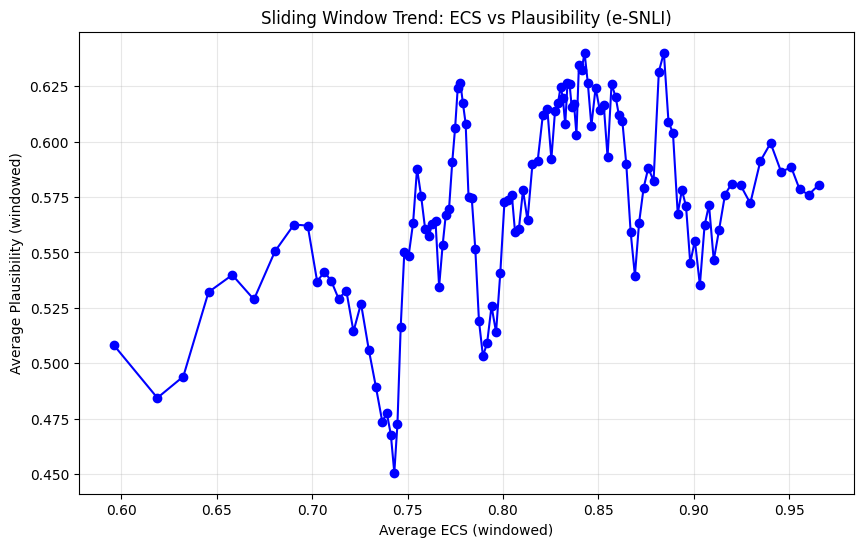

In [126]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Load files
# ============================================================
plaus_file = "esnli_mistral_rationales_with_plausibility.csv"
ecs_file = "esnli_mistral_rationales_with_ecs.csv"

plaus_df = pd.read_csv(plaus_file)
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]

print(f"📄 Loaded {len(plaus_df)} rows from plausibility file")
print(f"📄 Loaded {len(ecs_df)} rows from ECS file")


# ============================================================
# 2. Merge on id
# ============================================================
df = plaus_df.merge(ecs_df, on="id", how="inner")

# Convert numeric columns
df["plausibility"] = pd.to_numeric(df["plausibility"], errors="coerce")
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop NA
df = df.dropna(subset=["plausibility", "ECS"])

print(f"🔗 Final merged dataset: {len(df)} rows")


# ============================================================
# 3. Sort by ECS
# ============================================================
df = df.sort_values(by="ECS").reset_index(drop=True)


# ============================================================
# 4. Sliding window settings
# ============================================================
window_size = 30
step_size = 5

avg_ecs_list = []
avg_plaus_list = []


# ============================================================
# 5. Compute sliding-window averages
# ============================================================
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs = window["ECS"].mean()
    avg_plaus = window["plausibility"].mean()

    avg_ecs_list.append(avg_ecs)
    avg_plaus_list.append(avg_plaus)


# ============================================================
# 6. Visualization
# ============================================================
plt.figure(figsize=(10, 6))
plt.plot(avg_ecs_list, avg_plaus_list, marker='o', linestyle='-', color='blue')

plt.xlabel("Average ECS (windowed)")
plt.ylabel("Average Plausibility (windowed)")
plt.title("Sliding Window Trend: ECS vs Plausibility (e-SNLI)")
plt.grid(alpha=0.3)

plt.show()

In [92]:
# =====================================================
# STEP 0: Import dependencies
# =====================================================
import pandas as pd
import numpy as np
import re
from itertools import combinations
from tqdm.notebook import tqdm

# =====================================================
# STEP 1: Configuration & Loading
# =====================================================
input_file = "esnli_mistral_rationales_filtered.csv"
output_file = "esnli_mistral_rationales_with_overlap.csv"

try:
    df = pd.read_csv(input_file)
    print(f"📄 Loaded {len(df)} rows from {input_file}")
except FileNotFoundError:
    print(f"❌ Error: Could not find file '{input_file}'.")
    df = pd.DataFrame()

# =====================================================
# STEP 2: Define CLEANING Function
# =====================================================
def clean_rationale(text):
    """
    Cleans rationales by removing 'Chain of Thought:' and 'Final Answer:'
    """
    if not isinstance(text, str):
        return ""

    # Remove Chain-of-Thought (case-insensitive)
    text = re.sub(r"(?i)chain\s*of\s*thought\s*:", "", text).strip()

    # Remove everything AFTER Final Answer (case-insensitive)
    text = re.split(r"(?i)final\s*answer\s*:", text)[0].strip()

    return text

# =====================================================
# STEP 3: Apply Cleaning
# =====================================================
print("✨ Cleaning rationales...")
df["rationale_original_clean"] = df["rationale_original"].apply(clean_rationale)
df["rationale_pert1_clean"] = df["rationale_lexical"].apply(clean_rationale)
df["rationale_pert2_clean"] = df["rationale_syntactic"].apply(clean_rationale)
df["rationale_pert3_clean"] = df["rationale_pragmatic"].apply(clean_rationale)

# =====================================================
# STEP 4: Define Lexical Overlap Function (Jaccard)
# =====================================================
def compute_lexical_overlap(rationales):
    """
    Computes the mean pairwise Jaccard Similarity (Word Overlap).
    Formula: Intersection / Union of unique words.
    
    Returns:
    1.0 = All words are identical (Template Collapse)
    0.0 = No shared words
    """
    # Filter for valid strings
    texts = [t for t in rationales if isinstance(t, str) and t.strip()]
    
    if len(texts) < 2:
        return np.nan

    # Tokenizer helper: Lowercase, remove special chars, split by whitespace
    def get_word_set(text):
        clean_text = re.sub(r'[^a-zA-Z0-9\s]', '', text.lower())
        return set(clean_text.split())

    overlap_scores = []
    
    # Calculate pairwise overlap for all combinations (6 pairs)
    for a, b in combinations(texts, 2):
        set_a = get_word_set(a)
        set_b = get_word_set(b)
        
        intersection = len(set_a.intersection(set_b))
        union = len(set_a.union(set_b))
        
        if union == 0:
            overlap_scores.append(0.0)
        else:
            overlap_scores.append(intersection / union)

    return np.mean(overlap_scores)

# =====================================================
# STEP 5: Compute Overlap Loop
# =====================================================
overlap_values = []

print("🔤 Computing Lexical Overlap (Template Check)...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    current_rationales = [
        row["rationale_original_clean"],
        row["rationale_pert1_clean"],
        row["rationale_pert2_clean"],
        row["rationale_pert3_clean"],
    ]
    
    overlap = compute_lexical_overlap(current_rationales)
    overlap_values.append(overlap)

df["Lexical_Overlap"] = overlap_values

# =====================================================
# STEP 6: Print Stats & Save
# =====================================================
avg_overlap = np.nanmean(df["Lexical_Overlap"])

print("-" * 40)
print(f"🔍 RESULTS SUMMARY")
print(f"   Average Lexical Overlap: {avg_overlap:.4f}")
print("-" * 40)
df.to_csv(output_file, index=False)
print(f"💾 Saved to {output_file}")

📄 Loaded 623 rows from esnli_mistral_rationales_filtered.csv
✨ Cleaning rationales...
🔤 Computing Lexical Overlap (Template Check)...


  0%|          | 0/623 [00:00<?, ?it/s]

----------------------------------------
🔍 RESULTS SUMMARY
   Average Lexical Overlap: 0.4495
----------------------------------------
💾 Saved to esnli_mistral_rationales_with_overlap.csv


In [60]:
!pip -q install spacy
!python -m spacy download en_core_web_sm

import spacy
import pandas as pd
import numpy as np
import re
from itertools import combinations
from tqdm.notebook import tqdm
from difflib import SequenceMatcher

# =====================================================
# CONFIGURATION
# =====================================================
input_file = "esnli_mistral_rationales_filtered.csv"
output_file = "esnli_mistral_rationales_with_pos.csv"

# Load Spacy (Disable NER/Parser for speed)
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

# Load Data
try:
    df = pd.read_csv(input_file)
    print(f"📄 Loaded {len(df)} rows.")
except FileNotFoundError:
    print("❌ File not found.")
    df = pd.DataFrame()

# =====================================================
# HELPER: CLEAN RATIONALE
# =====================================================
def clean_rationale(text):
    if not isinstance(text, str): return ""
    text = re.sub(r"(?i)chain\s*of\s*thought\s*:", "", text).strip()
    text = re.split(r"(?i)final\s*answer\s*:", text)[0].strip()
    return text


# Apply cleaning
cols_to_clean = ["rationale_original", "rationale_lexical", 
                 "rationale_syntactic", "rationale_pragmatic"]
clean_cols = []

for col in cols_to_clean:
    new_col = col + "_clean"
    df[new_col] = df[col].apply(clean_rationale)
    clean_cols.append(new_col)

# =====================================================
# CORE LOGIC: POS TEMPLATES
# =====================================================
def get_pos_sequence(text):
    """
    Converts text to POS tags.
    Input: "The cat sleeps."
    Output: "DET NOUN VERB PUNCT"
    """
    if not isinstance(text, str) or not text.strip():
        return ""
    
    doc = nlp(text)
    # Join tags into a single string for easy comparison
    return " ".join([token.pos_ for token in doc])

def compute_structural_stiffness(rationales):
    """
    Computes mean pairwise similarity of POS sequences.
    """
    valid_texts = [t for t in rationales if isinstance(t, str) and t.strip()]
    if len(valid_texts) < 2:
        return np.nan

    # 1. Convert all to POS strings
    pos_strings = [get_pos_sequence(t) for t in valid_texts]
    
    # 2. Compare using SequenceMatcher (Sensitive to order)
    ratios = []
    for a, b in combinations(pos_strings, 2):
        # .ratio() gives a score 0.0 to 1.0 based on how many edits needed
        ratios.append(SequenceMatcher(None, a, b).ratio())
        
    return np.mean(ratios)

# =====================================================
# EXECUTION LOOP
# =====================================================
stiffness_scores = []
pos_examples = []  # Store one example of POS string for inspection

print("🧬 Computing Structural Stiffness (POS Template Overlap)...")

for _, row in tqdm(df.iterrows(), total=len(df)):
    current_rationales = [row[c] for c in clean_cols]
    
    # Compute Score
    score = compute_structural_stiffness(current_rationales)
    stiffness_scores.append(score)
    
    # Store the POS sequence of the original rationale (for checking later)
    pos_examples.append(get_pos_sequence(current_rationales[0]))

df["POS_Stiffness"] = stiffness_scores
df["POS_Template_Example"] = pos_examples

# =====================================================
# RESULTS
# =====================================================
avg_stiffness = np.nanmean(df["POS_Stiffness"])

print("-" * 40)
print(f"🔍 RESULTS SUMMARY")
print(f"   Average Structural Stiffness (POS Overlap): {avg_stiffness:.4f}")
print("-" * 40)

# Save
df.to_csv(output_file, index=False)
print(f"💾 Saved to {output_file}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 3.3 MB/s eta 0:00:00m eta 0:00:010:00:01

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
📄 Loaded 623 rows.
🧬 Computing Structural Stiffness (POS Template Overlap)...


  0%|          | 0/623 [00:00<?, ?it/s]

----------------------------------------
🔍 RESULTS SUMMARY
   Average Structural Stiffness (POS Overlap): 0.3406
----------------------------------------
💾 Saved to esnli_mistral_rationales_with_pos.csv


In [61]:
# =====================================================
# STEP 0: Dependencies
# =====================================================
import pandas as pd
import numpy as np
import re
import nltk
# Ensure punkt is downloaded for sentence tokenization
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) 
from nltk.tokenize import sent_tokenize

# =====================================================
# STEP 1: Load Data
# =====================================================
input_file = "esnli_mistral_rationales_filtered.csv"  # Loading your base file
# If you want to use the file you just created with POS tags, change to:
# input_file = "qwen_esnli_rationales_with_pos.csv"

try:
    df = pd.read_csv(input_file)
    print(f"📄 Loaded {len(df)} rows from {input_file}")
except FileNotFoundError:
    print(f"❌ Error: Could not find file '{input_file}'")
    df = pd.DataFrame()

# =====================================================
# STEP 2: Clean Rationales (Crucial for Pattern Match)
# =====================================================
def clean_rationale(text):
    if not isinstance(text, str): return ""
    # Remove Chain of Thought
    text = re.sub(r"(?i)chain\s*of\s*thought\s*:", "", text).strip()
    # Remove Final Answer and everything after
    text = re.split(r"(?i)final\s*answer\s*:", text)[0].strip()
    return text

print("✨ Cleaning rationales...")
cols_to_clean = [
    "rationale_original", 
    "rationale_lexical", 
    "rationale_syntactic", 
    "rationale_pragmatic"
]

clean_cols = []
for col in cols_to_clean:
    new_col = col + "_clean"
    # Check if column exists before applying
    if col in df.columns:
        df[new_col] = df[col].apply(clean_rationale)
        clean_cols.append(new_col)
    else:
        print(f"⚠️ Warning: Column {col} not found in CSV.")

# =====================================================
# STEP 3: Define Pattern Extractor
# =====================================================
def extract_discourse_pattern(text):
    """
    Extracts the first 2 words of every sentence.
    Input: "The premise states X. However, the hypothesis says Y."
    Output: "the premise | however the"
    """
    if not isinstance(text, str) or not text.strip(): 
        return "EMPTY"
    
    try:
        # Split into sentences
        sentences = sent_tokenize(text)
    except Exception:
        # Fallback if nltk fails
        sentences = text.split('.')
    
    # Get first 2 words of each sentence (lowercase)
    openers = []
    for s in sentences:
        words = s.strip().split()
        if len(words) >= 2:
            openers.append(" ".join(words[:2]).lower())
        elif len(words) == 1:
            openers.append(words[0].lower())
            
    if not openers:
        return "EMPTY"
        
    return " | ".join(openers)

# =====================================================
# STEP 4: Apply to ALL Columns
# =====================================================
print("🕵️‍♂️ Extracting Discourse Patterns...")

pattern_cols = []
for col in clean_cols:
    new_col = col + "_pattern"
    df[new_col] = df[col].apply(extract_discourse_pattern)
    pattern_cols.append(new_col)

# =====================================================
# STEP 5: Analysis A - Global Dominance
# =====================================================
# Combine all 4 columns into one long series to see the "Global Mindset"
all_patterns = pd.concat([df[c] for c in pattern_cols])

# Count frequency
if len(all_patterns) > 0:
    pattern_counts = all_patterns.value_counts(normalize=True)
    top_pattern = pattern_counts.index[0]
    top_freq = pattern_counts.iloc[0]
else:
    top_pattern = "N/A"
    top_freq = 0.0

print("-" * 40)
print("🌍 GLOBAL TEMPLATE DOMINANCE (Robot Score)")
print("-" * 40)
print(f"Top Pattern: '{top_pattern}'")
print(f"Frequency:   {top_freq:.2%} (of ALL rationales generated)")
print("-" * 40)

# =====================================================
# STEP 6: Analysis B - Row-wise Collapse
# =====================================================
# Check if a single row uses the exact same pattern for ALL 4 versions

def check_row_collapse(row):
    # Gather the 4 patterns for this specific example
    patterns = [row[c] for c in pattern_cols]
    # If they are all identical, return 1
    return 1 if len(set(patterns)) == 1 else 0

df['pattern_collapsed'] = df.apply(check_row_collapse, axis=1)
pct_collapsed = df['pattern_collapsed'].mean()

print("\n🔒 ROW-WISE REASONING COLLAPSE (Stubbornness Score)")
print("-" * 40)
print(f"Percentage of rows where ALL 4 perturbations")
print(f"use the EXACT same discourse structure:")
print(f"👉 {pct_collapsed:.2%}")
print("-" * 40)


📄 Loaded 623 rows from esnli_mistral_rationales_filtered.csv
✨ Cleaning rationales...
🕵️‍♂️ Extracting Discourse Patterns...
----------------------------------------
🌍 GLOBAL TEMPLATE DOMINANCE (Robot Score)
----------------------------------------
Top Pattern: '- the | - the | - therefore,'
Frequency:   3.53% (of ALL rationales generated)
----------------------------------------

🔒 ROW-WISE REASONING COLLAPSE (Stubbornness Score)
----------------------------------------
Percentage of rows where ALL 4 perturbations
use the EXACT same discourse structure:
👉 3.21%
----------------------------------------


📄 Loaded 627 rows from Overlap file
📄 Loaded 627 rows from ECS file
🔗 Final merged dataset: 627 rows


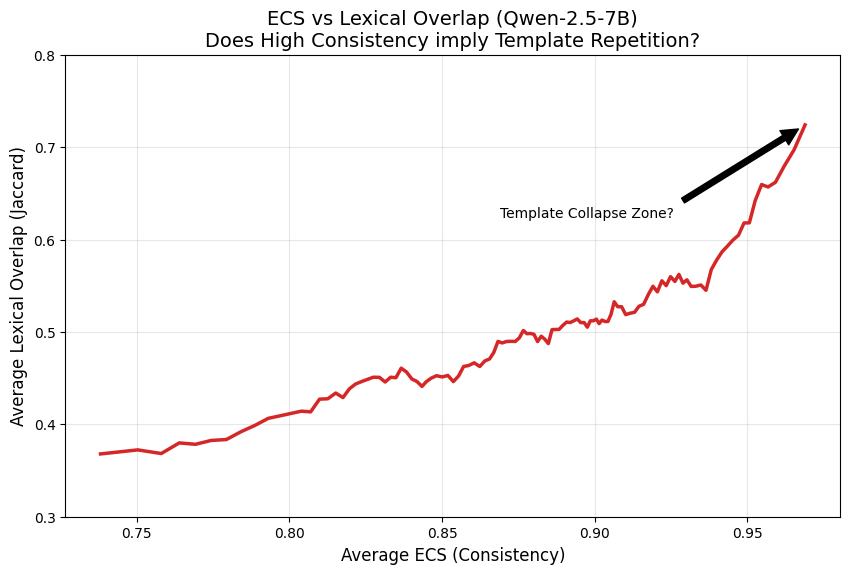

In [144]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Load files
# ============================================================
overlap_file = "qwen_esnli_rationales_with_overlap.csv"  # Created in step 1
ecs_file = "qwen_esnli_rationales_with_ecs.csv"          # Created previously

try:
    overlap_df = pd.read_csv(overlap_file)
    ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]] # Ensure we only get ID and ECS

    print(f"📄 Loaded {len(overlap_df)} rows from Overlap file")
    print(f"📄 Loaded {len(ecs_df)} rows from ECS file")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    # Stop execution if files missing
    overlap_df = pd.DataFrame()
    ecs_df = pd.DataFrame()

if not overlap_df.empty and not ecs_df.empty:
    # ============================================================
    # 2. Merge on id
    # ============================================================
    df = overlap_df.merge(ecs_df, on="id", how="inner")

    # Convert numeric columns
    df["Lexical_Overlap"] = pd.to_numeric(df["Lexical_Overlap"], errors="coerce")
    df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

    # Drop NA
    df = df.dropna(subset=["Lexical_Overlap", "ECS"])

    print(f"🔗 Final merged dataset: {len(df)} rows")

    # ============================================================
    # 3. Sort by ECS (Crucial for sliding window)
    # ============================================================
    df = df.sort_values(by="ECS").reset_index(drop=True)

    # ============================================================
    # 4. Sliding window logic
    # ============================================================
    window_size = 50  # Increased slightly for smoother lines
    step_size = 5

    avg_ecs_list = []
    avg_overlap_list = []

    # Iterate
    for start in range(0, len(df) - window_size + 1, step_size):
        window = df.iloc[start:start + window_size]

        avg_ecs = window["ECS"].mean()
        avg_overlap = window["Lexical_Overlap"].mean()

        avg_ecs_list.append(avg_ecs)
        avg_overlap_list.append(avg_overlap)

    # ============================================================
    # 5. Visualization
    # ============================================================
    plt.figure(figsize=(10, 6))
    
    # Plot the trend line
    plt.plot(avg_ecs_list, avg_overlap_list, marker='', linestyle='-', linewidth=2.5, color='#d62728')
    
    plt.xlabel("Average ECS (Consistency)", fontsize=12)
    plt.ylabel("Average Lexical Overlap (Jaccard)", fontsize=12)
    plt.title("ECS vs Lexical Overlap (Qwen-2.5-7B)\nDoes High Consistency imply Template Repetition?", fontsize=14)
    
    plt.ylim(0.3, 0.8)   # <-- Set Y-axis from 0 to 1
    
    plt.grid(alpha=0.3)
    
    # Add an annotation arrow if trend is positive
    if len(avg_overlap_list) > 0 and avg_overlap_list[-1] > avg_overlap_list[0]:
        plt.annotate(
            'Template Collapse Zone?',
            xy=(avg_ecs_list[-1], avg_overlap_list[-1]),
            xytext=(avg_ecs_list[-1] - 0.1, avg_overlap_list[-1] - 0.1),
            arrowprops=dict(facecolor='black', shrink=0.05)
        )
    
    plt.show()


**Llama overlap**

📄 Loaded 627 rows from Overlap file
📄 Loaded 627 rows from ECS file
🔗 Final merged dataset: 627 rows


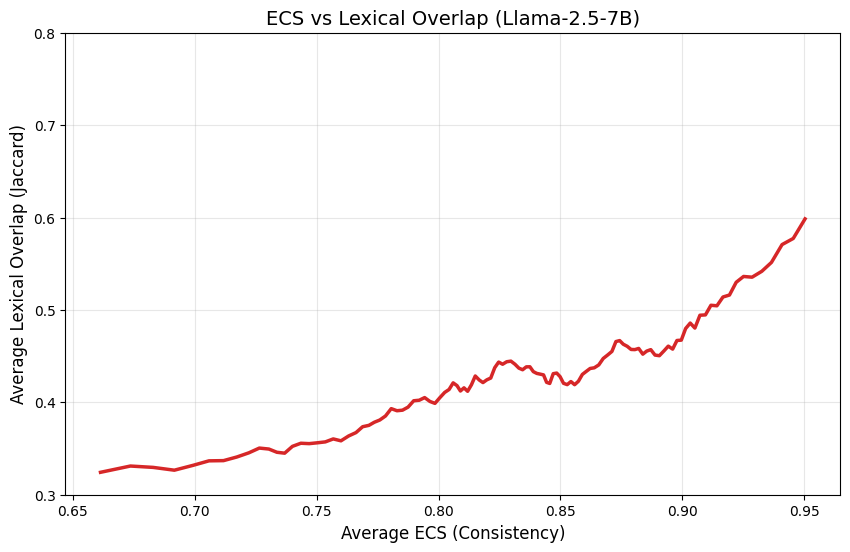

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Load files
# ============================================================
overlap_file = "esnli_llama_rationales_with_overlap.csv"  # Created in step 1
ecs_file = "esnli_llama_rationales_with_ecs.csv"         # Created previously

try:
    overlap_df = pd.read_csv(overlap_file)
    ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]] # Ensure we only get ID and ECS

    print(f"📄 Loaded {len(overlap_df)} rows from Overlap file")
    print(f"📄 Loaded {len(ecs_df)} rows from ECS file")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    # Stop execution if files missing
    overlap_df = pd.DataFrame()
    ecs_df = pd.DataFrame()

if not overlap_df.empty and not ecs_df.empty:
    # ============================================================
    # 2. Merge on id
    # ============================================================
    df = overlap_df.merge(ecs_df, on="id", how="inner")

    # Convert numeric columns
    df["Lexical_Overlap"] = pd.to_numeric(df["Lexical_Overlap"], errors="coerce")
    df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

    # Drop NA
    df = df.dropna(subset=["Lexical_Overlap", "ECS"])

    print(f"🔗 Final merged dataset: {len(df)} rows")

    # ============================================================
    # 3. Sort by ECS (Crucial for sliding window)
    # ============================================================
    df = df.sort_values(by="ECS").reset_index(drop=True)

    # ============================================================
    # 4. Sliding window logic
    # ============================================================
    window_size = 50  # Increased slightly for smoother lines
    step_size = 5

    avg_ecs_list = []
    avg_overlap_list = []

    # Iterate
    for start in range(0, len(df) - window_size + 1, step_size):
        window = df.iloc[start:start + window_size]

        avg_ecs = window["ECS"].mean()
        avg_overlap = window["Lexical_Overlap"].mean()

        avg_ecs_list.append(avg_ecs)
        avg_overlap_list.append(avg_overlap)

    # ============================================================
    # 5. Visualization
    # ============================================================
    plt.figure(figsize=(10, 6))
    
    # Plot the trend line
    plt.plot(avg_ecs_list, avg_overlap_list, marker='', linestyle='-', linewidth=2.5, color='#d62728') # Red for 'Warning'

    plt.xlabel("Average ECS (Consistency)", fontsize=12)
    plt.ylabel("Average Lexical Overlap (Jaccard)", fontsize=12)
    plt.title("ECS vs Lexical Overlap (Llama-2.5-7B)", fontsize=14)
    plt.grid(alpha=0.3)
    
    plt.ylim(0.3, 0.8)   # <-- Set Y-axis from 0 to 1
    
    plt.grid(alpha=0.3)
    
    
    plt.show()

**Gemini overlap**

📄 Loaded 627 rows from Overlap file
📄 Loaded 627 rows from ECS file
🔗 Final merged dataset: 627 rows


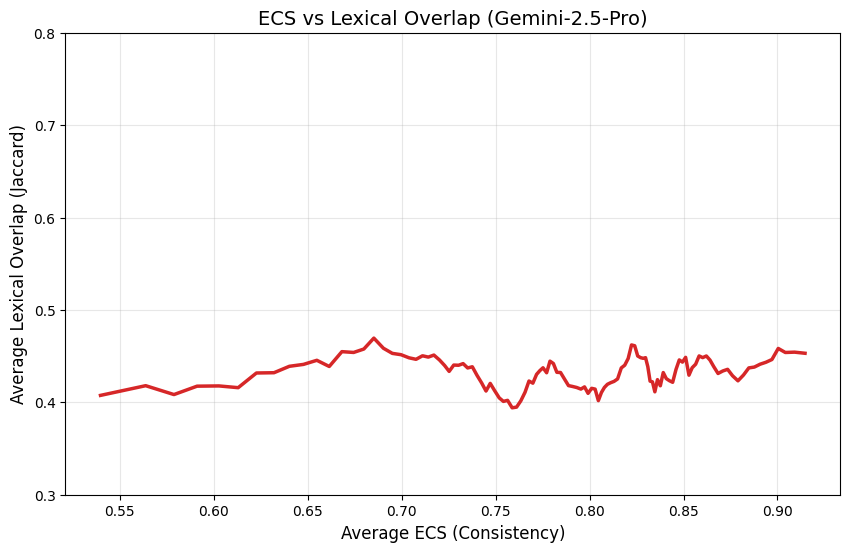

In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Load files
# ============================================================
overlap_file = "esnli_gemini_rationales_with_overlap.csv"  # Created in step 1
ecs_file = "esnli_gemini_rationales_with_ecs.csv"         # Created previously

try:
    overlap_df = pd.read_csv(overlap_file)
    ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]] # Ensure we only get ID and ECS

    print(f"📄 Loaded {len(overlap_df)} rows from Overlap file")
    print(f"📄 Loaded {len(ecs_df)} rows from ECS file")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    # Stop execution if files missing
    overlap_df = pd.DataFrame()
    ecs_df = pd.DataFrame()

if not overlap_df.empty and not ecs_df.empty:
    # ============================================================
    # 2. Merge on id
    # ============================================================
    df = overlap_df.merge(ecs_df, on="id", how="inner")

    # Convert numeric columns
    df["Lexical_Overlap"] = pd.to_numeric(df["Lexical_Overlap"], errors="coerce")
    df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

    # Drop NA
    df = df.dropna(subset=["Lexical_Overlap", "ECS"])

    print(f"🔗 Final merged dataset: {len(df)} rows")

    # ============================================================
    # 3. Sort by ECS (Crucial for sliding window)
    # ============================================================
    df = df.sort_values(by="ECS").reset_index(drop=True)

    # ============================================================
    # 4. Sliding window logic
    # ============================================================
    window_size = 50  # Increased slightly for smoother lines
    step_size = 5

    avg_ecs_list = []
    avg_overlap_list = []

    # Iterate
    for start in range(0, len(df) - window_size + 1, step_size):
        window = df.iloc[start:start + window_size]

        avg_ecs = window["ECS"].mean()
        avg_overlap = window["Lexical_Overlap"].mean()

        avg_ecs_list.append(avg_ecs)
        avg_overlap_list.append(avg_overlap)

    # ============================================================
    # 5. Visualization
    # ============================================================
    plt.figure(figsize=(10, 6))
    
    # Plot the trend line
    plt.plot(avg_ecs_list, avg_overlap_list, marker='', linestyle='-', linewidth=2.5, color='#d62728') # Red for 'Warning'

    plt.xlabel("Average ECS (Consistency)", fontsize=12)
    plt.ylabel("Average Lexical Overlap (Jaccard)", fontsize=12)
    plt.title("ECS vs Lexical Overlap (Gemini-2.5-Pro)", fontsize=14)
    plt.ylim(0.3, 0.8) 
    plt.grid(alpha=0.3)
    
    
    
    

    plt.show()

**POS score -Qwen 2.5**

📄 Loaded 627 rows from POS file
📄 Loaded 627 rows from ECS file
🔗 Final merged dataset: 627 rows


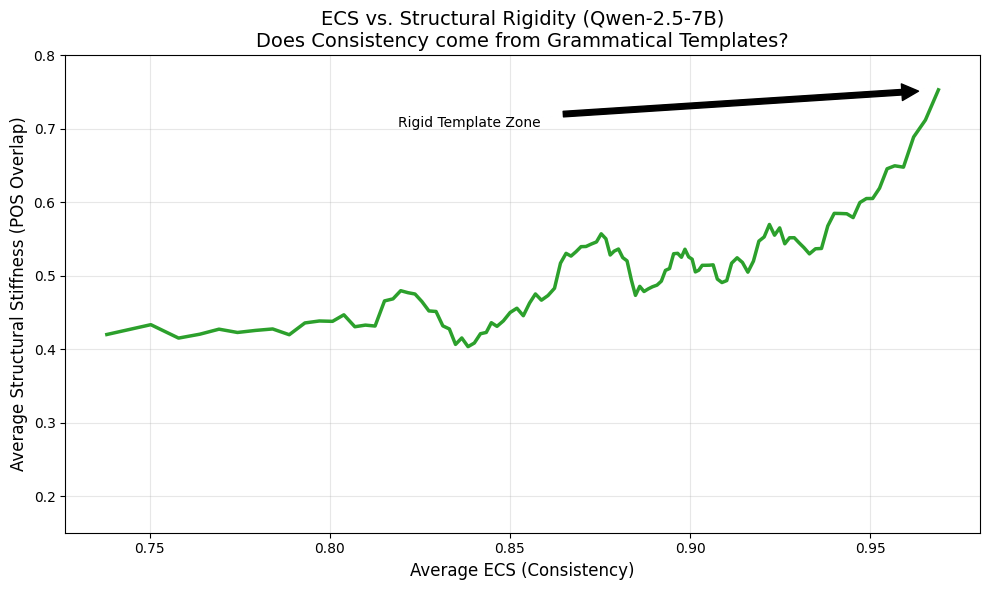

In [159]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Load files
# ============================================================
# The file you generated with your POS script
pos_file = "qwen_esnli_rationales_with_pos.csv" 
# The file containing the ECS scores
ecs_file = "qwen_esnli_rationales_with_ecs.csv"     

try:
    # Load POS file
    pos_df = pd.read_csv(pos_file)
    print(f"📄 Loaded {len(pos_df)} rows from POS file")
    
    # Load ECS file (only need ID and ECS column)
    ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]
    print(f"📄 Loaded {len(ecs_df)} rows from ECS file")
    
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    pos_df = pd.DataFrame()
    ecs_df = pd.DataFrame()

if not pos_df.empty and not ecs_df.empty:
    # ============================================================
    # 2. Merge on id
    # ============================================================
    df = pos_df.merge(ecs_df, on="id", how="inner")

    # Ensure numeric types
    df["POS_Stiffness"] = pd.to_numeric(df["POS_Stiffness"], errors="coerce")
    df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

    # Drop any failed rows
    df = df.dropna(subset=["POS_Stiffness", "ECS"])

    print(f"🔗 Final merged dataset: {len(df)} rows")

    # ============================================================
    # 3. Sort by ECS (X-Axis)
    # ============================================================
    df = df.sort_values(by="ECS").reset_index(drop=True)

    # ============================================================
    # 4. Sliding Window Logic
    # ============================================================
    window_size = 50  # Size of the "bucket" to average
    step_size = 5     # How much we slide over

    avg_ecs_list = []
    avg_pos_list = []

    # Iterate through the sorted dataframe
    for start in range(0, len(df) - window_size + 1, step_size):
        window = df.iloc[start:start + window_size]

        # Calculate means for this window
        avg_ecs = window["ECS"].mean()
        avg_pos = window["POS_Stiffness"].mean()

        avg_ecs_list.append(avg_ecs)
        avg_pos_list.append(avg_pos)

    # ============================================================
    # 5. Visualization
    # ============================================================
    plt.figure(figsize=(10, 6))

    # Plot the trend line
    plt.plot(avg_ecs_list, avg_pos_list, marker='', linestyle='-', linewidth=2.5, color='#2ca02c') # Green line

    # Labels and Titles
    plt.xlabel("Average ECS (Consistency)", fontsize=12)
    plt.ylabel("Average Structural Stiffness (POS Overlap)", fontsize=12)
    plt.title("ECS vs. Structural Rigidity (Qwen-2.5-7B)\nDoes Consistency come from Grammatical Templates?", fontsize=14)
    
    plt.ylim(0.15, 0.8) 
    
    plt.grid(alpha=0.3)

    # Optional: Add annotations for interpretation
    if len(avg_pos_list) > 0:
        # Check slope to annotate correctly
        if avg_pos_list[-1] > avg_pos_list[0]:
            plt.annotate('Rigid Template Zone', 
                         xy=(avg_ecs_list[-1], avg_pos_list[-1]), 
                         xytext=(avg_ecs_list[-1]-0.15, avg_pos_list[-1]-0.05),
                         arrowprops=dict(facecolor='black', shrink=0.05))
        
    plt.tight_layout()
    plt.show()

**POS score -Llama**

📄 Loaded 627 rows from POS file
📄 Loaded 627 rows from ECS file
🔗 Final merged dataset: 627 rows


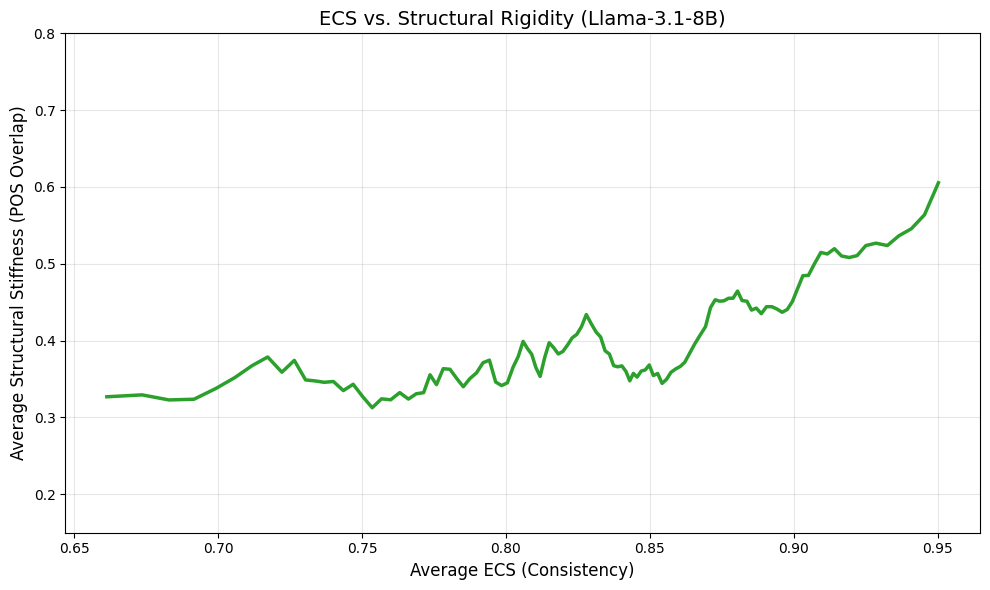

In [157]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Load files
# ============================================================
# The file you generated with your POS script
pos_file = "esnli_llama_rationales_with_pos.csv" 
# The file containing the ECS scores
ecs_file = "esnli_llama_rationales_with_ecs.csv"     

try:
    # Load POS file
    pos_df = pd.read_csv(pos_file)
    print(f"📄 Loaded {len(pos_df)} rows from POS file")
    
    # Load ECS file (only need ID and ECS column)
    ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]
    print(f"📄 Loaded {len(ecs_df)} rows from ECS file")
    
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    pos_df = pd.DataFrame()
    ecs_df = pd.DataFrame()

if not pos_df.empty and not ecs_df.empty:
    # ============================================================
    # 2. Merge on id
    # ============================================================
    df = pos_df.merge(ecs_df, on="id", how="inner")

    # Ensure numeric types
    df["POS_Stiffness"] = pd.to_numeric(df["POS_Stiffness"], errors="coerce")
    df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

    # Drop any failed rows
    df = df.dropna(subset=["POS_Stiffness", "ECS"])

    print(f"🔗 Final merged dataset: {len(df)} rows")

    # ============================================================
    # 3. Sort by ECS (X-Axis)
    # ============================================================
    df = df.sort_values(by="ECS").reset_index(drop=True)

    # ============================================================
    # 4. Sliding Window Logic
    # ============================================================
    window_size = 50  # Size of the "bucket" to average
    step_size = 5     # How much we slide over

    avg_ecs_list = []
    avg_pos_list = []

    # Iterate through the sorted dataframe
    for start in range(0, len(df) - window_size + 1, step_size):
        window = df.iloc[start:start + window_size]

        # Calculate means for this window
        avg_ecs = window["ECS"].mean()
        avg_pos = window["POS_Stiffness"].mean()

        avg_ecs_list.append(avg_ecs)
        avg_pos_list.append(avg_pos)

    # ============================================================
    # 5. Visualization
    # ============================================================
    plt.figure(figsize=(10, 6))

    # Plot the trend line
    plt.plot(avg_ecs_list, avg_pos_list, marker='', linestyle='-', linewidth=2.5, color='#2ca02c') # Green line

    # Labels and Titles
    plt.xlabel("Average ECS (Consistency)", fontsize=12)
    plt.ylabel("Average Structural Stiffness (POS Overlap)", fontsize=12)
    plt.title("ECS vs. Structural Rigidity (Llama-3.1-8B)", fontsize=14)

    plt.ylim(0.15, 0.8) 
    
    plt.grid(alpha=0.3)

    
   
    plt.tight_layout()
    plt.show()

**POS score -Gemini**

📄 Loaded 627 rows from POS file
📄 Loaded 627 rows from ECS file
🔗 Final merged dataset: 627 rows


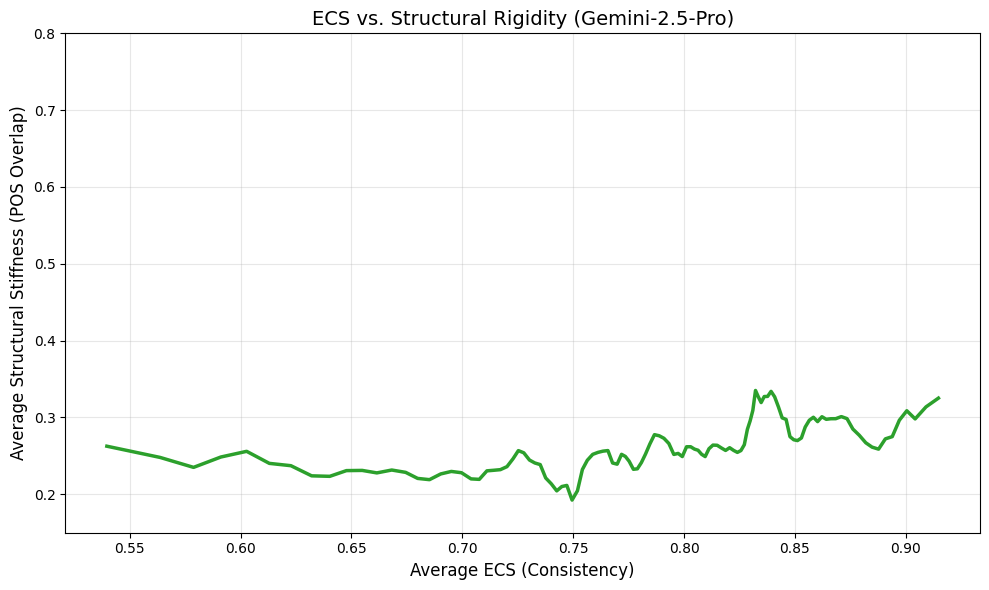

In [160]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Load files
# ============================================================
# The file you generated with your POS script
pos_file = "esnli_gemini_rationales_with_pos.csv"
# The file containing the ECS scores
ecs_file = "esnli_gemini_rationales_with_ecs.csv"

try:
    # Load POS file
    pos_df = pd.read_csv(pos_file)
    print(f"📄 Loaded {len(pos_df)} rows from POS file")
    
    # Load ECS file (only need ID and ECS column)
    ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]
    print(f"📄 Loaded {len(ecs_df)} rows from ECS file")
    
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    pos_df = pd.DataFrame()
    ecs_df = pd.DataFrame()

if not pos_df.empty and not ecs_df.empty:
    # ============================================================
    # 2. Merge on id
    # ============================================================
    df = pos_df.merge(ecs_df, on="id", how="inner")

    # Ensure numeric types
    df["POS_Stiffness"] = pd.to_numeric(df["POS_Stiffness"], errors="coerce")
    df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

    # Drop any failed rows
    df = df.dropna(subset=["POS_Stiffness", "ECS"])

    print(f"🔗 Final merged dataset: {len(df)} rows")

    # ============================================================
    # 3. Sort by ECS (X-Axis)
    # ============================================================
    df = df.sort_values(by="ECS").reset_index(drop=True)

    # ============================================================
    # 4. Sliding Window Logic
    # ============================================================
    window_size = 50  # Size of the "bucket" to average
    step_size = 5     # How much we slide over

    avg_ecs_list = []
    avg_pos_list = []

    # Iterate through the sorted dataframe
    for start in range(0, len(df) - window_size + 1, step_size):
        window = df.iloc[start:start + window_size]

        # Calculate means for this window
        avg_ecs = window["ECS"].mean()
        avg_pos = window["POS_Stiffness"].mean()

        avg_ecs_list.append(avg_ecs)
        avg_pos_list.append(avg_pos)

    # ============================================================
    # 5. Visualization
    # ============================================================
    plt.figure(figsize=(10, 6))

    # Plot the trend line
    plt.plot(avg_ecs_list, avg_pos_list, marker='', linestyle='-', linewidth=2.5, color='#2ca02c') # Green line

    # Labels and Titles
    plt.xlabel("Average ECS (Consistency)", fontsize=12)
    plt.ylabel("Average Structural Stiffness (POS Overlap)", fontsize=12)
    plt.title("ECS vs. Structural Rigidity (Gemini-2.5-Pro)", fontsize=14)

    plt.ylim(0.15, 0.8) 
    plt.grid(alpha=0.3)

    
        
    plt.tight_layout()
    plt.show()

**Qwen2.5-smoking gun**

📄 Loaded Data: 627 rationales, 627 ECS scores
🕵️‍♂️ Extracting patterns...


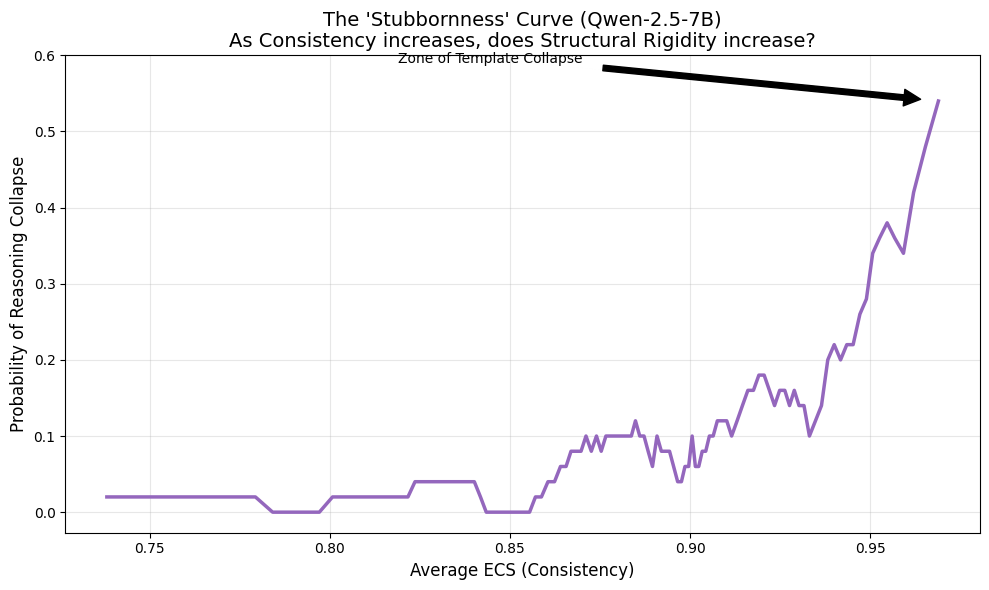

In [174]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize

# Ensure dependencies
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) 

# =====================================================
# 1. CONFIGURATION
# =====================================================
input_file = "qwen_esnli_rationales_filtered.csv"      # Your rationales
ecs_file = "qwen_esnli_rationales_with_ecs.csv"        # Your ECS scores

# =====================================================
# 2. LOAD & CLEAN
# =====================================================
try:
    df = pd.read_csv(input_file)
    ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]] # Only need ID and ECS
    print(f"📄 Loaded Data: {len(df)} rationales, {len(ecs_df)} ECS scores")
except FileNotFoundError:
    print("❌ Files not found. Please check paths.")
    df = pd.DataFrame()
    ecs_df = pd.DataFrame()

def clean_rationale(text):
    if not isinstance(text, str): return ""
    text = re.sub(r"(?i)chain\s*of\s*thought\s*:", "", text).strip()
    text = re.split(r"(?i)final\s*answer\s*:", text)[0].strip()
    return text

if not df.empty and not ecs_df.empty:
    cols_to_clean = ["rationale_original", "rationale_perturbation_1_lexical", 
                     "rationale_perturbation_2_syntactic", "rationale_perturbation_3_pragmatic"]
    
    clean_cols = []
    for col in cols_to_clean:
        new_col = col + "_clean"
        df[new_col] = df[col].apply(clean_rationale)
        clean_cols.append(new_col)

    # =====================================================
    # 3. EXTRACT PATTERNS
    # =====================================================
    def extract_discourse_pattern(text):
        if not isinstance(text, str) or not text.strip(): return "EMPTY"
        try:
            sentences = sent_tokenize(text)
        except:
            sentences = text.split('.')
        
        openers = []
        for s in sentences:
            words = s.strip().split()
            if len(words) >= 2:
                openers.append(" ".join(words[:2]).lower())
            elif len(words) == 1:
                openers.append(words[0].lower())
        
        if not openers: return "EMPTY"
        return " | ".join(openers)

    print("🕵️‍♂️ Extracting patterns...")
    pattern_cols = []
    for col in clean_cols:
        new_col = col + "_pattern"
        df[new_col] = df[col].apply(extract_discourse_pattern)
        pattern_cols.append(new_col)

    # =====================================================
    # 4. CALCULATE ROW-WISE COLLAPSE (0 or 1)
    # =====================================================
    def check_row_collapse(row):
        # Do all 4 versions use the EXACT same pattern?
        patterns = [row[c] for c in pattern_cols]
        return 1 if len(set(patterns)) == 1 else 0

    df['pattern_collapsed'] = df.apply(check_row_collapse, axis=1)

    # =====================================================
    # 5. MERGE WITH ECS
    # =====================================================
    merged_df = df.merge(ecs_df, on="id", how="inner")
    
    # Sort by ECS for sliding window
    merged_df = merged_df.sort_values(by="ECS").reset_index(drop=True)
    
    # =====================================================
    # 6. SLIDING WINDOW PLOT
    # =====================================================
    window_size = 50
    step_size = 5

    avg_ecs_list = []
    avg_collapse_list = []

    for start in range(0, len(merged_df) - window_size + 1, step_size):
        window = merged_df.iloc[start:start + window_size]
        
        avg_ecs = window["ECS"].mean()
        # Mean of 0s and 1s gives the Percentage (0.0 to 1.0)
        avg_collapse = window["pattern_collapsed"].mean() 

        avg_ecs_list.append(avg_ecs)
        avg_collapse_list.append(avg_collapse)

    # Plotting
    plt.figure(figsize=(10, 6))
    
    # Plot line
    plt.plot(avg_ecs_list, avg_collapse_list, marker='', linestyle='-', linewidth=2.5, color='#9467bd') # Purple

    plt.xlabel("Average ECS (Consistency)", fontsize=12)
    plt.ylabel("Probability of Reasoning Collapse", fontsize=12)
    plt.title("The 'Stubbornness' Curve (Qwen-2.5-7B)\nAs Consistency increases, does Structural Rigidity increase?", fontsize=14)
    plt.grid(alpha=0.3)
    
    # Force Y-axis to percentage friendly
    plt.yticks(np.arange(0, 0.7, 0.1))
    
    # Annotate the danger zone
    if len(avg_collapse_list) > 0 and avg_collapse_list[-1] > 0.2:
        plt.annotate('Zone of Template Collapse', 
                     xy=(avg_ecs_list[-1], avg_collapse_list[-1]), 
                     xytext=(avg_ecs_list[-1]-0.15, avg_collapse_list[-1]+0.05),
                     arrowprops=dict(facecolor='black', shrink=0.05))

    plt.tight_layout()
    plt.show()

**Llama-smoking gun**

📄 Loaded Data: 627 rationales, 627 ECS scores
🕵️‍♂️ Extracting patterns...


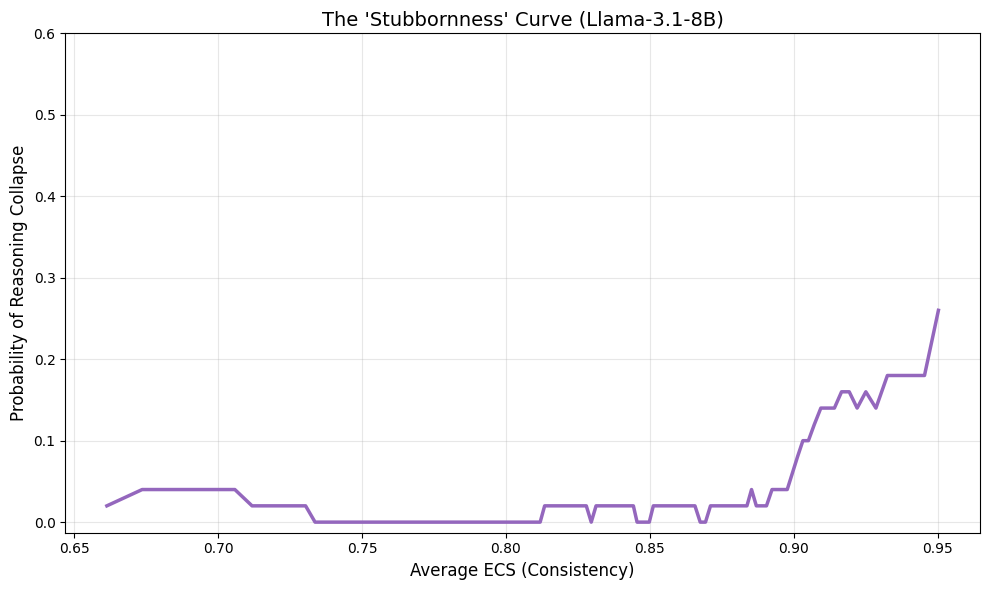

In [172]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize

# Ensure dependencies
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) 

# =====================================================
# 1. CONFIGURATION
# =====================================================
input_file = "esnli_llama_rationales_filtered.csv"      # Your rationales
ecs_file = "esnli_llama_rationales_with_ecs.csv"       # Your ECS scores

# =====================================================
# 2. LOAD & CLEAN
# =====================================================
try:
    df = pd.read_csv(input_file)
    ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]] # Only need ID and ECS
    print(f"📄 Loaded Data: {len(df)} rationales, {len(ecs_df)} ECS scores")
except FileNotFoundError:
    print("❌ Files not found. Please check paths.")
    df = pd.DataFrame()
    ecs_df = pd.DataFrame()

def clean_rationale(text):
    if not isinstance(text, str): return ""
    text = re.sub(r"(?i)chain\s*of\s*thought\s*:", "", text).strip()
    text = re.split(r"(?i)final\s*answer\s*:", text)[0].strip()
    return text
    
if not df.empty and not ecs_df.empty:
    cols_to_clean = ["rationale_original",  "rationale_lexical", 
                     "rationale_syntactic", "rationale_pragmatic"]
    
    clean_cols = []
    for col in cols_to_clean:
        new_col = col + "_clean"
        df[new_col] = df[col].apply(clean_rationale)
        clean_cols.append(new_col)

    # =====================================================
    # 3. EXTRACT PATTERNS
    # =====================================================
    def extract_discourse_pattern(text):
        if not isinstance(text, str) or not text.strip(): return "EMPTY"
        try:
            sentences = sent_tokenize(text)
        except:
            sentences = text.split('.')
        
        openers = []
        for s in sentences:
            words = s.strip().split()
            if len(words) >= 2:
                openers.append(" ".join(words[:2]).lower())
            elif len(words) == 1:
                openers.append(words[0].lower())
        
        if not openers: return "EMPTY"
        return " | ".join(openers)

    print("🕵️‍♂️ Extracting patterns...")
    pattern_cols = []
    for col in clean_cols:
        new_col = col + "_pattern"
        df[new_col] = df[col].apply(extract_discourse_pattern)
        pattern_cols.append(new_col)

    # =====================================================
    # 4. CALCULATE ROW-WISE COLLAPSE (0 or 1)
    # =====================================================
    def check_row_collapse(row):
        # Do all 4 versions use the EXACT same pattern?
        patterns = [row[c] for c in pattern_cols]
        return 1 if len(set(patterns)) == 1 else 0

    df['pattern_collapsed'] = df.apply(check_row_collapse, axis=1)

    # =====================================================
    # 5. MERGE WITH ECS
    # =====================================================
    merged_df = df.merge(ecs_df, on="id", how="inner")
    
    # Sort by ECS for sliding window
    merged_df = merged_df.sort_values(by="ECS").reset_index(drop=True)
    
    # =====================================================
    # 6. SLIDING WINDOW PLOT
    # =====================================================
    window_size = 50
    step_size = 5

    avg_ecs_list = []
    avg_collapse_list = []

    for start in range(0, len(merged_df) - window_size + 1, step_size):
        window = merged_df.iloc[start:start + window_size]
        
        avg_ecs = window["ECS"].mean()
        # Mean of 0s and 1s gives the Percentage (0.0 to 1.0)
        avg_collapse = window["pattern_collapsed"].mean() 

        avg_ecs_list.append(avg_ecs)
        avg_collapse_list.append(avg_collapse)

    # Plotting
    plt.figure(figsize=(10, 6))
    
    # Plot line
    plt.plot(avg_ecs_list, avg_collapse_list, marker='', linestyle='-', linewidth=2.5, color='#9467bd') # Purple

    plt.xlabel("Average ECS (Consistency)", fontsize=12)
    plt.ylabel("Probability of Reasoning Collapse", fontsize=12)
    plt.title("The 'Stubbornness' Curve (Llama-3.1-8B)", fontsize=14)
    plt.grid(alpha=0.3)
    
    # Force Y-axis to percentage friendly
    plt.yticks(np.arange(0, 0.7, 0.1))
    

    plt.tight_layout()
    plt.show()

**Gemini-smoking gun**

📄 Loaded Data: 627 rationales, 627 ECS scores
🕵️‍♂️ Extracting patterns...


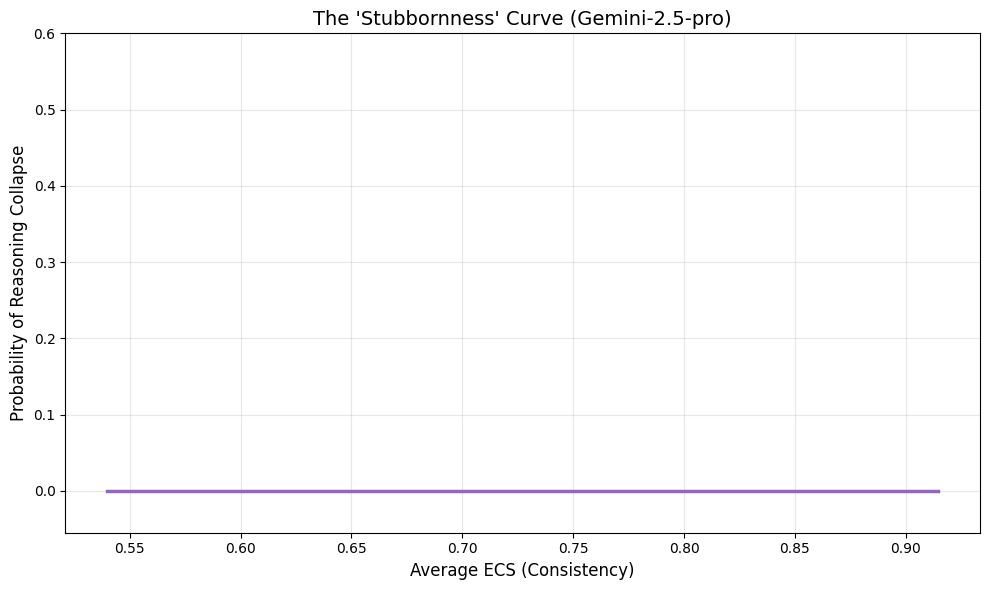

In [168]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize

# Ensure dependencies
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) 

# =====================================================
# 1. CONFIGURATION
# =====================================================
input_file = "esnli_gemini_rationales_filtered.csv"      # Your rationales
ecs_file ="esnli_gemini_rationales_with_ecs.csv"      # Your ECS scores

# =====================================================
# 2. LOAD & CLEAN
# =====================================================
try:
    df = pd.read_csv(input_file)
    ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]] # Only need ID and ECS
    print(f"📄 Loaded Data: {len(df)} rationales, {len(ecs_df)} ECS scores")
except FileNotFoundError:
    print("❌ Files not found. Please check paths.")
    df = pd.DataFrame()
    ecs_df = pd.DataFrame()

def clean_rationale(text):
    if not isinstance(text, str): return ""
    text = re.sub(r"(?i)chain\s*of\s*thought\s*:", "", text).strip()
    text = re.split(r"(?i)final\s*answer\s*:", text)[0].strip()
    return text
   
if not df.empty and not ecs_df.empty:
    cols_to_clean = ["rationale_original",  "rationale_pert1", 
                     "rationale_pert2",  "rationale_pert3"]
    
    clean_cols = []
    for col in cols_to_clean:
        new_col = col + "_clean"
        df[new_col] = df[col].apply(clean_rationale)
        clean_cols.append(new_col)

    # =====================================================
    # 3. EXTRACT PATTERNS
    # =====================================================
    def extract_discourse_pattern(text):
        if not isinstance(text, str) or not text.strip(): return "EMPTY"
        try:
            sentences = sent_tokenize(text)
        except:
            sentences = text.split('.')
        
        openers = []
        for s in sentences:
            words = s.strip().split()
            if len(words) >= 2:
                openers.append(" ".join(words[:2]).lower())
            elif len(words) == 1:
                openers.append(words[0].lower())
        
        if not openers: return "EMPTY"
        return " | ".join(openers)

    print("🕵️‍♂️ Extracting patterns...")
    pattern_cols = []
    for col in clean_cols:
        new_col = col + "_pattern"
        df[new_col] = df[col].apply(extract_discourse_pattern)
        pattern_cols.append(new_col)

    # =====================================================
    # 4. CALCULATE ROW-WISE COLLAPSE (0 or 1)
    # =====================================================
    def check_row_collapse(row):
        # Do all 4 versions use the EXACT same pattern?
        patterns = [row[c] for c in pattern_cols]
        return 1 if len(set(patterns)) == 1 else 0

    df['pattern_collapsed'] = df.apply(check_row_collapse, axis=1)

    # =====================================================
    # 5. MERGE WITH ECS
    # =====================================================
    merged_df = df.merge(ecs_df, on="id", how="inner")
    
    # Sort by ECS for sliding window
    merged_df = merged_df.sort_values(by="ECS").reset_index(drop=True)
    
    # =====================================================
    # 6. SLIDING WINDOW PLOT
    # =====================================================
    window_size = 50
    step_size = 5

    avg_ecs_list = []
    avg_collapse_list = []

    for start in range(0, len(merged_df) - window_size + 1, step_size):
        window = merged_df.iloc[start:start + window_size]
        
        avg_ecs = window["ECS"].mean()
        # Mean of 0s and 1s gives the Percentage (0.0 to 1.0)
        avg_collapse = window["pattern_collapsed"].mean() 

        avg_ecs_list.append(avg_ecs)
        avg_collapse_list.append(avg_collapse)

    # Plotting
    plt.figure(figsize=(10, 6))
    
    # Plot line
    plt.plot(avg_ecs_list, avg_collapse_list, marker='', linestyle='-', linewidth=2.5, color='#9467bd') # Purple

    plt.xlabel("Average ECS (Consistency)", fontsize=12)
    plt.ylabel("Probability of Reasoning Collapse", fontsize=12)
    plt.title("The 'Stubbornness' Curve (Gemini-2.5-pro)", fontsize=14)
    plt.grid(alpha=0.3)
    
    # Force Y-axis to percentage friendly
    plt.yticks(np.arange(0, 0.7, 0.1))

    

    plt.tight_layout()
    plt.show()

**Mistral-Overlap**

📄 Loaded 623 rows from Overlap file
📄 Loaded 623 rows from ECS file
🔗 Final merged dataset: 623 rows


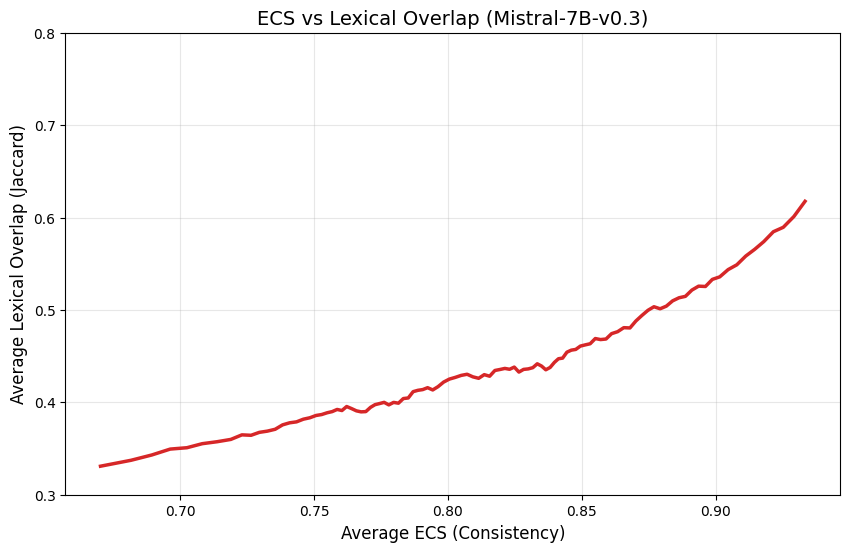

In [155]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Load files
# ============================================================
overlap_file = "esnli_mistral_rationales_with_overlap.csv"  # Created in step 1
ecs_file = "esnli_mistral_rationales_with_ecs.csv"          # Created previously

try:
    overlap_df = pd.read_csv(overlap_file)
    ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]] # Ensure we only get ID and ECS

    print(f"📄 Loaded {len(overlap_df)} rows from Overlap file")
    print(f"📄 Loaded {len(ecs_df)} rows from ECS file")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    # Stop execution if files missing
    overlap_df = pd.DataFrame()
    ecs_df = pd.DataFrame()

if not overlap_df.empty and not ecs_df.empty:
    # ============================================================
    # 2. Merge on id
    # ============================================================
    df = overlap_df.merge(ecs_df, on="id", how="inner")

    # Convert numeric columns
    df["Lexical_Overlap"] = pd.to_numeric(df["Lexical_Overlap"], errors="coerce")
    df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

    # Drop NA
    df = df.dropna(subset=["Lexical_Overlap", "ECS"])

    print(f"🔗 Final merged dataset: {len(df)} rows")

    # ============================================================
    # 3. Sort by ECS (Crucial for sliding window)
    # ============================================================
    df = df.sort_values(by="ECS").reset_index(drop=True)

    # ============================================================
    # 4. Sliding window logic
    # ============================================================
    window_size = 100  # Increased slightly for smoother lines
    step_size = 5

    avg_ecs_list = []
    avg_overlap_list = []

    # Iterate
    for start in range(0, len(df) - window_size + 1, step_size):
        window = df.iloc[start:start + window_size]

        avg_ecs = window["ECS"].mean()
        avg_overlap = window["Lexical_Overlap"].mean()

        avg_ecs_list.append(avg_ecs)
        avg_overlap_list.append(avg_overlap)

    # ============================================================
    # 5. Visualization
    # ============================================================
    plt.figure(figsize=(10, 6))
    
    # Plot the trend line
    plt.plot(avg_ecs_list, avg_overlap_list, marker='', linestyle='-', linewidth=2.5, color='#d62728') # Red for 'Warning'

    plt.xlabel("Average ECS (Consistency)", fontsize=12)
    plt.ylabel("Average Lexical Overlap (Jaccard)", fontsize=12)
    plt.title("ECS vs Lexical Overlap (Mistral-7B-v0.3)", fontsize=14)
    plt.ylim(0.3, 0.8) 
    plt.grid(alpha=0.3)
    
    
    plt.show()

**POS score - Mistral**

📄 Loaded 623 rows from POS file
📄 Loaded 623 rows from ECS file
🔗 Final merged dataset: 623 rows


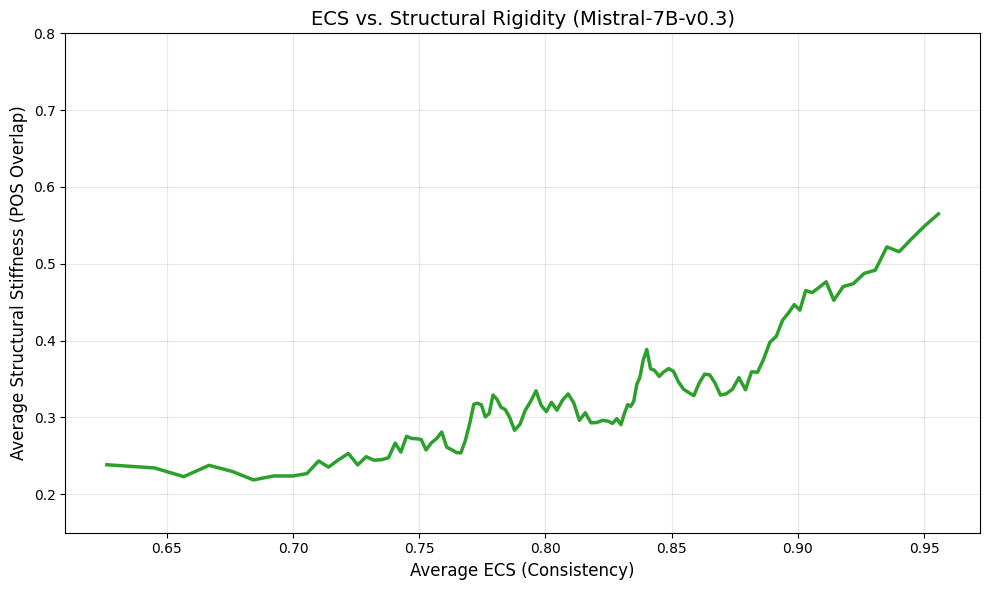

In [162]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Load files
# ============================================================
# The file you generated with your POS script
pos_file = "esnli_mistral_rationales_with_pos.csv"
# The file containing the ECS scores
ecs_file = "esnli_mistral_rationales_with_ecs.csv"

try:
    # Load POS file
    pos_df = pd.read_csv(pos_file)
    print(f"📄 Loaded {len(pos_df)} rows from POS file")
    
    # Load ECS file (only need ID and ECS column)
    ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]
    print(f"📄 Loaded {len(ecs_df)} rows from ECS file")
    
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    pos_df = pd.DataFrame()
    ecs_df = pd.DataFrame()

if not pos_df.empty and not ecs_df.empty:
    # ============================================================
    # 2. Merge on id
    # ============================================================
    df = pos_df.merge(ecs_df, on="id", how="inner")

    # Ensure numeric types
    df["POS_Stiffness"] = pd.to_numeric(df["POS_Stiffness"], errors="coerce")
    df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

    # Drop any failed rows
    df = df.dropna(subset=["POS_Stiffness", "ECS"])

    print(f"🔗 Final merged dataset: {len(df)} rows")

    # ============================================================
    # 3. Sort by ECS (X-Axis)
    # ============================================================
    df = df.sort_values(by="ECS").reset_index(drop=True)

    # ============================================================
    # 4. Sliding Window Logic
    # ============================================================
    window_size = 50  # Size of the "bucket" to average
    step_size = 5     # How much we slide over

    avg_ecs_list = []
    avg_pos_list = []

    # Iterate through the sorted dataframe
    for start in range(0, len(df) - window_size + 1, step_size):
        window = df.iloc[start:start + window_size]

        # Calculate means for this window
        avg_ecs = window["ECS"].mean()
        avg_pos = window["POS_Stiffness"].mean()

        avg_ecs_list.append(avg_ecs)
        avg_pos_list.append(avg_pos)

    # ============================================================
    # 5. Visualization
    # ============================================================
    plt.figure(figsize=(10, 6))

    # Plot the trend line
    plt.plot(avg_ecs_list, avg_pos_list, marker='', linestyle='-', linewidth=2.5, color='#2ca02c') # Green line

    # Labels and Titles
    plt.xlabel("Average ECS (Consistency)", fontsize=12)
    plt.ylabel("Average Structural Stiffness (POS Overlap)", fontsize=12)
    plt.title("ECS vs. Structural Rigidity (Mistral-7B-v0.3)", fontsize=14)

    plt.ylim(0.15, 0.8)
    
    plt.grid(alpha=0.3)

    
        
    plt.tight_layout()
    plt.show()

**Mistral-smoking gun**

📄 Loaded Data: 623 rationales, 623 ECS scores
🕵️‍♂️ Extracting patterns...


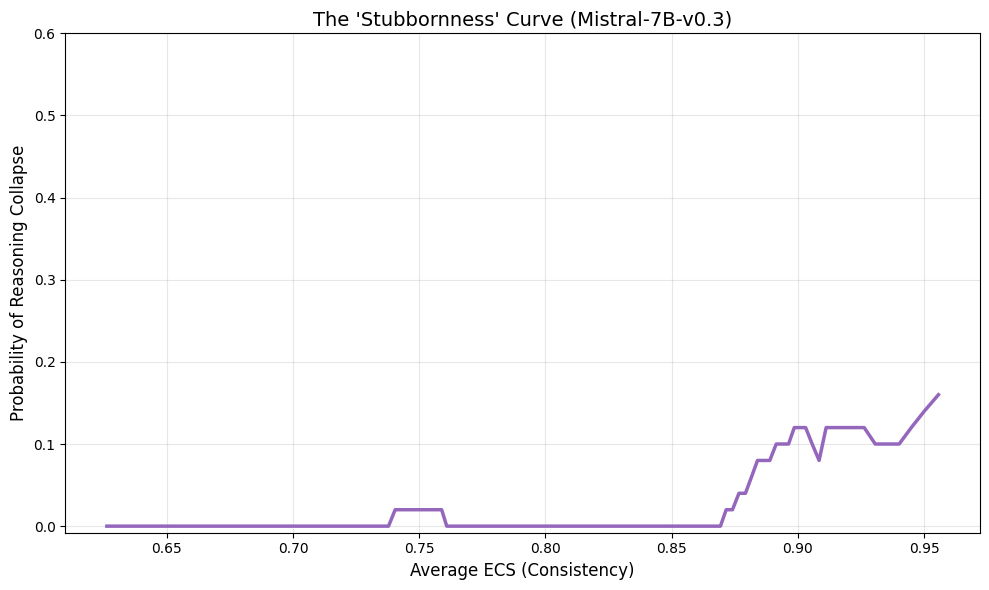

In [173]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize

# Ensure dependencies
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) 

# =====================================================
# 1. CONFIGURATION
# =====================================================
input_file = "esnli_mistral_rationales_filtered.csv"    # Your rationales
ecs_file = "esnli_mistral_rationales_with_ecs.csv"    # Your ECS scores

# =====================================================
# 2. LOAD & CLEAN
# =====================================================
try:
    df = pd.read_csv(input_file)
    ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]] # Only need ID and ECS
    print(f"📄 Loaded Data: {len(df)} rationales, {len(ecs_df)} ECS scores")
except FileNotFoundError:
    print("❌ Files not found. Please check paths.")
    df = pd.DataFrame()
    ecs_df = pd.DataFrame()

def clean_rationale(text):
    if not isinstance(text, str): return ""
    text = re.sub(r"(?i)chain\s*of\s*thought\s*:", "", text).strip()
    text = re.split(r"(?i)final\s*answer\s*:", text)[0].strip()
    return text


   
if not df.empty and not ecs_df.empty:
    cols_to_clean = ["rationale_original", "rationale_lexical", 
                     "rationale_syntactic", "rationale_pragmatic"]
    
    clean_cols = []
    for col in cols_to_clean:
        new_col = col + "_clean"
        df[new_col] = df[col].apply(clean_rationale)
        clean_cols.append(new_col)

    # =====================================================
    # 3. EXTRACT PATTERNS
    # =====================================================
    def extract_discourse_pattern(text):
        if not isinstance(text, str) or not text.strip(): return "EMPTY"
        try:
            sentences = sent_tokenize(text)
        except:
            sentences = text.split('.')
        
        openers = []
        for s in sentences:
            words = s.strip().split()
            if len(words) >= 2:
                openers.append(" ".join(words[:2]).lower())
            elif len(words) == 1:
                openers.append(words[0].lower())
        
        if not openers: return "EMPTY"
        return " | ".join(openers)

    print("🕵️‍♂️ Extracting patterns...")
    pattern_cols = []
    for col in clean_cols:
        new_col = col + "_pattern"
        df[new_col] = df[col].apply(extract_discourse_pattern)
        pattern_cols.append(new_col)

    # =====================================================
    # 4. CALCULATE ROW-WISE COLLAPSE (0 or 1)
    # =====================================================
    def check_row_collapse(row):
        # Do all 4 versions use the EXACT same pattern?
        patterns = [row[c] for c in pattern_cols]
        return 1 if len(set(patterns)) == 1 else 0

    df['pattern_collapsed'] = df.apply(check_row_collapse, axis=1)

    # =====================================================
    # 5. MERGE WITH ECS
    # =====================================================
    merged_df = df.merge(ecs_df, on="id", how="inner")
    
    # Sort by ECS for sliding window
    merged_df = merged_df.sort_values(by="ECS").reset_index(drop=True)
    
    # =====================================================
    # 6. SLIDING WINDOW PLOT
    # =====================================================
    window_size = 50
    step_size = 5

    avg_ecs_list = []
    avg_collapse_list = []

    for start in range(0, len(merged_df) - window_size + 1, step_size):
        window = merged_df.iloc[start:start + window_size]
        
        avg_ecs = window["ECS"].mean()
        # Mean of 0s and 1s gives the Percentage (0.0 to 1.0)
        avg_collapse = window["pattern_collapsed"].mean() 

        avg_ecs_list.append(avg_ecs)
        avg_collapse_list.append(avg_collapse)

    # Plotting
    plt.figure(figsize=(10, 6))
    
    # Plot line
    plt.plot(avg_ecs_list, avg_collapse_list, marker='', linestyle='-', linewidth=2.5, color='#9467bd') # Purple

    plt.xlabel("Average ECS (Consistency)", fontsize=12)
    plt.ylabel("Probability of Reasoning Collapse", fontsize=12)
    plt.title("The 'Stubbornness' Curve (Mistral-7B-v0.3)", fontsize=14)
    plt.grid(alpha=0.3)
    
    # Force Y-axis to percentage friendly
    plt.yticks(np.arange(0, 0.7, 0.1))
    
    

    plt.tight_layout()
    plt.show()

In [2]:
# -----------------------------
# Load data
# -----------------------------

# -----------------------------
# File paths (YOUR FILES)
# -----------------------------
plaus_file = "esnli_mistral_rationales_with_plausibility.csv"
ecs_file = "esnli_mistral_rationales_with_ecs.csv"

# -----------------------------
# Load data
# -----------------------------
plaus_df = pd.read_csv(plaus_file)[["id", "plausibility"]]
ecs_df   = pd.read_csv(ecs_file)[["id", "ECS"]]

# Merge into one dataset
df = plaus_df.merge(ecs_df, on="id", how="inner")
df = df.sort_values("ECS").reset_index(drop=True)

# Ensure numeric
df["plausibility"] = pd.to_numeric(df["plausibility"], errors="coerce")
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop missing rows
df = df.dropna(subset=["plausibility", "ECS"])

print(f"🔗 Final merged dataset: {len(df)} rows")

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.03
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 30
step_size = 5

avg_ecs_list = []
avg_plaus_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_plaus_list.append(window["plausibility"].mean())

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()

    overlapping_bins = bin_stats[
        (bin_stats["bin_mid"] >= ecs_min) &
        (bin_stats["bin_mid"] <= ecs_max)
    ]

    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_plaus_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average ECS (windowed)")
ax.set_ylabel("Average Plausibility (windowed)")
ax.set_title("Rolling Average ECS vs Plausibility (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# LOWESS smoothing
# -----------------------------
density_threshold = np.percentile(window_density, 0)  # keep all data
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
plaus_high = np.array(avg_plaus_list)[mask]

smooth = lowess(plaus_high, ecs_high, frac=0.30, return_sorted=True)

smooth_ecs  = smooth[:, 0]
smooth_plaus = smooth[:, 1]

ax.plot(smooth_ecs, smooth_plaus, color="#32CD32", linewidth=4)

ax.legend()

plt.show()

NameError: name 'pd' is not defined

**LLM-as-a-Judge**

**Gemini**

In [1]:
!pip install google-cloud-aiplatform


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [13]:
import pandas as pd

# -----------------------------
# Your cleaning function
# -----------------------------
def clean_rationale(text):
    """
    Removes boilerplate such as 'Chain of Thought:' and 
    everything after 'Final Answer:'.
    """
    if not isinstance(text, str):
        return ""

    text = text.replace("Chain of Thought:", "").replace("CoT:", "").strip()

    # Remove everything after common final answer markers
    for tag in ["Final Answer:", "Answer:", "Conclusion:"]:
        if tag in text:
            text = text.split(tag)[0].strip()

    return text


# -----------------------------
# Load input CSV
# -----------------------------
INPUT_FILE = "esnli_gemini_rationales_filtered.csv"
OUTPUT_FILE = "esnli_gemini_rationales_filtered_cleaned.csv"

df = pd.read_csv(INPUT_FILE)

print(f"Loaded {len(df)} rows.")

# Columns that need cleaning
cols_to_clean = [
    "rationale_original",
    "rationale_pert1",
    "rationale_pert2",
    "rationale_pert3"
]

# Validate they exist
missing = [c for c in cols_to_clean if c not in df.columns]
assert len(missing) == 0, f"❌ Missing columns: {missing}"

# -----------------------------
# Create cleaned versions
# -----------------------------
for col in cols_to_clean:
    df[col + "_cleaned"] = df[col].apply(clean_rationale)

# -----------------------------
# Remove original columns
# -----------------------------
df = df.drop(columns=cols_to_clean)

# -----------------------------
# Save cleaned dataset
# -----------------------------
df.to_csv(OUTPUT_FILE, index=False)

print(f"✅ Success! Cleaned file saved as: {OUTPUT_FILE}")
print("👉 Only `_cleaned` rationale columns remain.")



Loaded 627 rows.
✅ Success! Cleaned file saved as: esnli_gemini_rationales_filtered_cleaned.csv
👉 Only `_cleaned` rationale columns remain.


In [54]:
import os
import pandas as pd
from vertexai.generative_models import GenerativeModel
import vertexai
import time
import csv
from tqdm import tqdm
import re


# ---------------------------
# 1. GOOGLE AUTHENTICATION 
# ---------------------------
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"
assert os.path.exists(SERVICE_ACCOUNT_PATH), f"❌ JSON file not found: {SERVICE_ACCOUNT_PATH}"
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH
print("✅ Google service account loaded.")


# ---------------------------
# 2. INITIALIZE GEMINI
# ---------------------------
vertexai.init(project="llm-reasoning-475315", location="us-central1")
model = GenerativeModel("gemini-2.5-flash")
print("✅ Gemini model initialized.")


# ---------------------------
# 3. LOAD DATA
# ---------------------------
rationales_df = pd.read_csv("esnli_gemini_rationales_filtered_cleaned.csv")
perturb_df = pd.read_csv("esnli_800_with_perturbations.csv")

# Keep only rows where we have rationales
perturb_df = perturb_df[perturb_df["id"].isin(rationales_df["id"])]

# Merge both datasets
merged = pd.merge(rationales_df, perturb_df, on="id", how="inner")
print("📌 Final merged dataset:", merged.shape)


# ---------------------------
# 4. PROMPT TEMPLATE
# ---------------------------
JUDGE_PROMPT = """

You are an expert evaluator of Natural Language Inference (NLI) explanations.

Your task is to judge the **plausibility and correctness of the MODEL RATIONALE** 
given the PREMISE, HYPOTHESIS, and the GOLD LABEL.

A plausible rationale is one that:
1. Uses ONLY information from the Premise (no external facts or assumptions).
2. Correctly explains why the GOLD LABEL logically follows.
3. Contains no contradictions, logical fallacies, or hallucinated details.
4. Is relevant and sufficient for justifying the label.

Ignore:
- writing style
- length
- verbosity
- grammar
These should NOT affect the score.

### SCORING RUBRIC (1–5):
5 = Excellent  
    - Fully correct reasoning.
    - Uses only premise information.
    - Explicitly supports the gold label with valid logical steps.

4 = Good  
    - Mostly correct and grounded.
    - Minor missing detail OR slight redundancy, but the justification is sound.

3 = Weak but Acceptable  
    - Partially correct reasoning.
    - Some vagueness OR a small incorrect assumption, but it still roughly supports the label.

2 = Flawed  
    - Significant logical gaps OR an incorrect justification.
    - Uses irrelevant or unsupported claims.
    - Does NOT adequately justify the gold label.

1 = Incorrect / Implausible  
    - Wrong reasoning OR contradicts the label.
    - Hallucinates facts not present in the premise.
    - Explanation is logically invalid.

### INPUT:
Premise: {premise}
Hypothesis: {hypothesis}
Gold Label: {label}
Model Rationale: {rationale}

### OUTPUT:
Output ONLY the integer score (1–5).

"""


# ---------------------------
# 5. SCORING FUNCTION (FIXED)
# ---------------------------
def score_rationale(premise, hypothesis, label, rationale):
    """Send one rationale to Gemini and extract plausibility score."""
    prompt = JUDGE_PROMPT.format(
        premise=premise,
        hypothesis=hypothesis,
        label=label,
        rationale=rationale
    )

    try:
        resp = model.generate_content(prompt)
        text = resp.text.strip()

        # Regex to extract 1..5 safely
        match = re.search(r"\b([1-5])\b", text)
        if match:
            return int(match.group(1))

        return None

    except Exception as e:
        tqdm.write(f"❌ Error for example: {e}")
        return None


# ---------------------------
# 6. PREPARE OUTPUT CSV
# ---------------------------
output_path = "esnli_gemini_plausibility_scores.csv"
write_header = not os.path.exists(output_path)

with open(output_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    # Write header if file doesn't exist
    if write_header:
        writer.writerow([
            "id",
            "plaus_original",
            "plaus_pert1",
            "plaus_pert2",
            "plaus_pert3"
        ])
        print("📝 Created new output file with header.")


    # ---------------------------
    # 7. tqdm SCORING LOOP
    # ---------------------------
    for idx, row in tqdm(merged.iterrows(), total=len(merged), desc="Scoring Rationales"):

        ex_id = row["id"]
        premise = row["Premise"]
        gold_label = row["gold_label"]  # correct gold label column

        # Hypotheses
        hyp_orig  = row["Hypothesis"]
        hyp_pert1 = row["perturbation_1_lexical"]
        hyp_pert2 = row["perturbation_2_syntactic"]
        hyp_pert3 = row["perturbation_3_pragmatic"]

        # Rationales
        rat_orig  = row["rationale_original_cleaned"]
        rat_pert1 = row["rationale_pert1_cleaned"]
        rat_pert2 = row["rationale_pert2_cleaned"]
        rat_pert3 = row["rationale_pert3_cleaned"]

        # Score each rationale (now robust)
        s0 = score_rationale(premise, hyp_orig,  gold_label, rat_orig)
        s1 = score_rationale(premise, hyp_pert1, gold_label, rat_pert1)
        s2 = score_rationale(premise, hyp_pert2, gold_label, rat_pert2)
        s3 = score_rationale(premise, hyp_pert3, gold_label, rat_pert3)

        # Save immediately
        writer.writerow([ex_id, s0, s1, s2, s3])

        # Optional rate limit protection
        time.sleep(0.25)

print("🎉 DONE! All plausibility scores saved row-by-row.")


/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


✅ Google service account loaded.
✅ Gemini model initialized.
📌 Final merged dataset: (627, 12)


Scoring Rationales: 100%|███████████████████| 627/627 [2:47:02<00:00, 15.98s/it]

🎉 DONE! All plausibility scores saved row-by-row.


In [ ]:

You are an expert evaluator of Natural Language Inference (NLI) explanations.

Your task is to judge the **plausibility and correctness of the MODEL RATIONALE** 
given the PREMISE, HYPOTHESIS, and the GOLD LABEL.

A plausible rationale is one that:
1. Uses ONLY information from the Premise (no external facts or assumptions).
2. Correctly explains why the GOLD LABEL logically follows.
3. Contains no contradictions, logical fallacies, or hallucinated details.
4. Is relevant and sufficient for justifying the label.

Ignore:
- writing style
- length
- verbosity
- grammar
These should NOT affect the score.

### SCORING RUBRIC (1–5):
5 = Excellent  
    - Fully correct reasoning.
    - Uses only premise information.
    - Explicitly supports the gold label with valid logical steps.

4 = Good  
    - Mostly correct and grounded.
    - Minor missing detail OR slight redundancy, but the justification is sound.

3 = Weak but Acceptable  
    - Partially correct reasoning.
    - Some vagueness OR a small incorrect assumption, but it still roughly supports the label.

2 = Flawed  
    - Significant logical gaps OR an incorrect justification.
    - Uses irrelevant or unsupported claims.
    - Does NOT adequately justify the gold label.

1 = Incorrect / Implausible  
    - Wrong reasoning OR contradicts the label.
    - Hallucinates facts not present in the premise.
    - Explanation is logically invalid.

### INPUT:
Premise: {premise}
Hypothesis: {hypothesis}
Gold Label: {label}
Model Rationale: {rationale}

### OUTPUT:
Output ONLY the integer score (1–5).
"""


**measure P-mean**

In [55]:
import pandas as pd

# -----------------------------
# File paths
# -----------------------------
INPUT_FILE = "esnli_gemini_plausibility_scores.csv"
OUTPUT_FILE = "esnli_gemini_plausibility_scores.csv"   # overwrite same file
# If you prefer a new file:
# OUTPUT_FILE = "esnli_gemini_plausibility_scores_with_pmean.csv"

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(INPUT_FILE)

# Columns containing plausibility scores
plaus_cols = ["plaus_original", "plaus_pert1", "plaus_pert2", "plaus_pert3"]

# Ensure all required columns exist
missing = [c for c in plaus_cols if c not in df.columns]
assert len(missing) == 0, f"❌ Missing columns: {missing}"

# Convert to numeric (in case some values are strings)
df[plaus_cols] = df[plaus_cols].apply(pd.to_numeric, errors="coerce")

# -----------------------------
# Compute Pmean for each row
# -----------------------------
df["Pmean"] = df[plaus_cols].mean(axis=1)

# -----------------------------
# Save updated CSV
# -----------------------------
df.to_csv(OUTPUT_FILE, index=False)

print(f"✅ Successfully added Pmean column!\nSaved to: {OUTPUT_FILE}")


✅ Successfully added Pmean column!
Saved to: esnli_gemini_plausibility_scores.csv


🔗 Final merged dataset: 627 rows


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_20264/241877763.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby("ecs_bin")["id"].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_20264/241877763.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby("ecs_bin")["ECS"].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_20264/241877763.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend

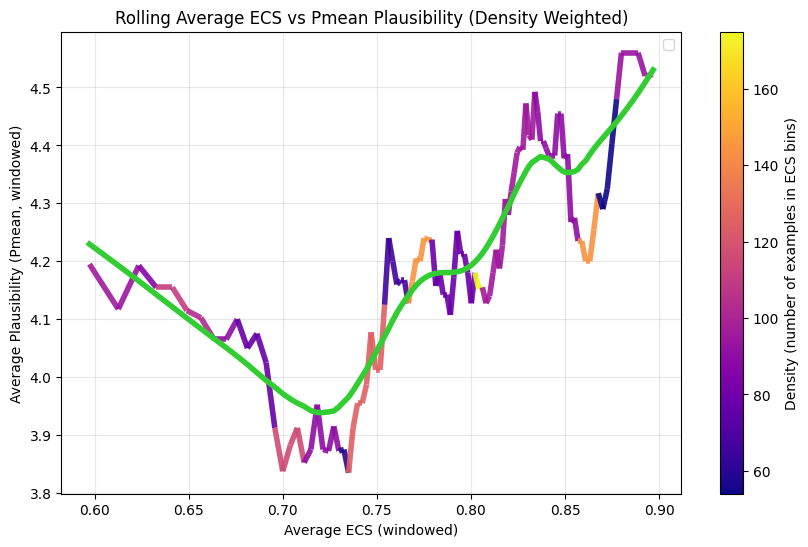

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths (UPDATED)
# -----------------------------
plaus_file = "esnli_gemini_plausibility_scores.csv"  # <-- UPDATED
ecs_file   = "esnli_gemini_rationales_with_ecs.csv"

# -----------------------------
# Load data (UPDATED COLUMN)
# -----------------------------
plaus_df = pd.read_csv(plaus_file)[["id", "Pmean"]]  # <-- USE Pmean
ecs_df   = pd.read_csv(ecs_file)[["id", "ECS"]]

# Merge into one dataset
df = plaus_df.merge(ecs_df, on="id", how="inner")
df = df.sort_values("ECS").reset_index(drop=True)

# Ensure numeric
df["Pmean"] = pd.to_numeric(df["Pmean"], errors="coerce")  # <-- UPDATED
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop missing rows
df = df.dropna(subset=["Pmean", "ECS"])

print(f"🔗 Final merged dataset: {len(df)} rows")

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.03
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 100
step_size = 5

avg_ecs_list = []
avg_plaus_list = []
window_density = []

# -----------------------------
# Compute rolling averages (UPDATED)
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_plaus_list.append(window["Pmean"].mean())  # <-- UPDATED

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()

    overlapping_bins = bin_stats[
        (bin_stats["bin_mid"] >= ecs_min) &
        (bin_stats["bin_mid"] <= ecs_max)
    ]

    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_plaus_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average ECS (windowed)")
ax.set_ylabel("Average Plausibility (Pmean, windowed)")  # <-- UPDATED LABEL
ax.set_title("Rolling Average ECS vs Pmean Plausibility (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# LOWESS smoothing
# -----------------------------
density_threshold = np.percentile(window_density, 0)  # keep all data
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
plaus_high = np.array(avg_plaus_list)[mask]

smooth = lowess(plaus_high, ecs_high, frac=0.35, return_sorted=True)

smooth_ecs  = smooth[:, 0]
smooth_plaus = smooth[:, 1]

ax.plot(smooth_ecs, smooth_plaus, color="#32CD32", linewidth=4)

ax.legend()

plt.show()


**Llama**

In [25]:
import pandas as pd

# -----------------------------
# Your cleaning function
# -----------------------------
def clean_rationale(text):
    """
    Removes boilerplate such as 'Chain of Thought:' and 
    everything after 'Final Answer:'.
    """
    if not isinstance(text, str):
        return ""

    text = text.replace("Chain of Thought:", "").replace("CoT:", "").strip()

    # Remove everything after common final answer markers
    for tag in ["Final Answer:", "Answer:", "Conclusion:"]:
        if tag in text:
            text = text.split(tag)[0].strip()

    return text


# -----------------------------
# Load input CSV
# -----------------------------
INPUT_FILE = "esnli_llama_rationales_filtered.csv"
OUTPUT_FILE = "esnli_llama_rationales_filtered_cleaned.csv"

df = pd.read_csv(INPUT_FILE)

print(f"Loaded {len(df)} rows.")

# Columns that need cleaning
cols_to_clean = [
    "rationale_original",
    "rationale_lexical",
    "rationale_syntactic",
    "rationale_pragmatic"
]

# Validate they exist
missing = [c for c in cols_to_clean if c not in df.columns]
assert len(missing) == 0, f"❌ Missing columns: {missing}"

# -----------------------------
# Create cleaned versions
# -----------------------------
for col in cols_to_clean:
    df[col + "_cleaned"] = df[col].apply(clean_rationale)

# -----------------------------
# Remove original columns
# -----------------------------
df = df.drop(columns=cols_to_clean)

# -----------------------------
# Save cleaned dataset
# -----------------------------
df.to_csv(OUTPUT_FILE, index=False)

print(f"✅ Success! Cleaned file saved as: {OUTPUT_FILE}")
print("👉 Only `_cleaned` rationale columns remain.")

Loaded 627 rows.
✅ Success! Cleaned file saved as: esnli_llama_rationales_filtered_cleaned.csv
👉 Only `_cleaned` rationale columns remain.


In [30]:
import os
import pandas as pd
from vertexai.generative_models import GenerativeModel
import vertexai
import time
import csv
from tqdm import tqdm
import re


# ---------------------------
# 1. GOOGLE AUTHENTICATION 
# ---------------------------
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"
assert os.path.exists(SERVICE_ACCOUNT_PATH), f"❌ JSON file not found: {SERVICE_ACCOUNT_PATH}"
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH
print("✅ Google service account loaded.")


# ---------------------------
# 2. INITIALIZE GEMINI
# ---------------------------
vertexai.init(project="llm-reasoning-475315", location="us-central1")
model = GenerativeModel("gemini-2.5-flash")
print("✅ Gemini model initialized.")


# ---------------------------
# 3. LOAD DATA
# ---------------------------
rationales_df = pd.read_csv("esnli_llama_rationales_filtered_cleaned.csv")
perturb_df = pd.read_csv("esnli_800_with_perturbations.csv")

# Keep only rows where we have rationales
perturb_df = perturb_df[perturb_df["id"].isin(rationales_df["id"])]

# Merge both datasets
merged = pd.merge(rationales_df, perturb_df, on="id", how="inner")
print("📌 Final merged dataset:", merged.shape)


# ---------------------------
# 4. PROMPT TEMPLATE
# ---------------------------
JUDGE_PROMPT = """

You are an expert evaluator of Natural Language Inference (NLI) explanations.

Your task is to judge the **plausibility and correctness of the MODEL RATIONALE** 
given the PREMISE, HYPOTHESIS, and the GOLD LABEL.

A plausible rationale is one that:
1. Uses ONLY information from the Premise (no external facts or assumptions).
2. Correctly explains why the GOLD LABEL logically follows.
3. Contains no contradictions, logical fallacies, or hallucinated details.
4. Is relevant and sufficient for justifying the label.

Ignore:
- writing style
- length
- verbosity
- grammar
These should NOT affect the score.

### SCORING RUBRIC (1–5):
5 = Excellent  
    - Fully correct reasoning.
    - Uses only premise information.
    - Explicitly supports the gold label with valid logical steps.

4 = Good  
    - Mostly correct and grounded.
    - Minor missing detail OR slight redundancy, but the justification is sound.

3 = Weak but Acceptable  
    - Partially correct reasoning.
    - Some vagueness OR a small incorrect assumption, but it still roughly supports the label.

2 = Flawed  
    - Significant logical gaps OR an incorrect justification.
    - Uses irrelevant or unsupported claims.
    - Does NOT adequately justify the gold label.

1 = Incorrect / Implausible  
    - Wrong reasoning OR contradicts the label.
    - Hallucinates facts not present in the premise.
    - Explanation is logically invalid.

### INPUT:
Premise: {premise}
Hypothesis: {hypothesis}
Gold Label: {label}
Model Rationale: {rationale}

### OUTPUT:
Output ONLY the integer score (1–5).

"""


# ---------------------------
# 5. SCORING FUNCTION (FIXED)
# ---------------------------
def score_rationale(premise, hypothesis, label, rationale):
    """Send one rationale to Gemini and extract plausibility score."""
    prompt = JUDGE_PROMPT.format(
        premise=premise,
        hypothesis=hypothesis,
        label=label,
        rationale=rationale
    )

    try:
        resp = model.generate_content(prompt)
        text = resp.text.strip()

        # Regex to extract 1..5 safely
        match = re.search(r"\b([1-5])\b", text)
        if match:
            return int(match.group(1))

        return None

    except Exception as e:
        tqdm.write(f"❌ Error for example: {e}")
        return None


# ---------------------------
# 6. PREPARE OUTPUT CSV
# ---------------------------
output_path = "esnli_llama_plausibility_scores.csv"
write_header = not os.path.exists(output_path)

with open(output_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    # Write header if file doesn't exist
    if write_header:
        writer.writerow([
            "id",
            "plaus_original",
            "plaus_lexical",
            "plaus_syntactic",
            "plaus_pragmatic"
        ])
        print("📝 Created new output file with header.")


    # ---------------------------
    # 7. tqdm SCORING LOOP
    # ---------------------------
    for idx, row in tqdm(merged.iterrows(), total=len(merged), desc="Scoring Rationales"):

        ex_id = row["id"]
        premise = row["Premise"]
        gold_label = row["gold_label"]

        # Hypotheses
        hyp_orig  = row["Hypothesis"]
        hyp_pert1 = row["perturbation_1_lexical"]
        hyp_pert2 = row["perturbation_2_syntactic"]
        hyp_pert3 = row["perturbation_3_pragmatic"]

        # Rationales
        rat_orig  = row["rationale_original_cleaned"]
        rat_pert1 = row["rationale_lexical_cleaned"]
        rat_pert2 = row["rationale_syntactic_cleaned"]
        rat_pert3 = row["rationale_pragmatic_cleaned"]

        # Score each rationale
        s0 = score_rationale(premise, hyp_orig,  gold_label, rat_orig)
        s1 = score_rationale(premise, hyp_pert1, gold_label, rat_pert1)
        s2 = score_rationale(premise, hyp_pert2, gold_label, rat_pert2)
        s3 = score_rationale(premise, hyp_pert3, gold_label, rat_pert3)

        # Write row immediately
        writer.writerow([ex_id, s0, s1, s2, s3])

        # --------------------------------------
        # 🔥 FORCE IMMEDIATE FLUSH TO DISK
        # --------------------------------------
        f.flush()
        os.fsync(f.fileno())
        # --------------------------------------

        # Optional small delay
        time.sleep(0.25)

print("🎉 DONE! All plausibility scores saved row-by-row with guaranteed flushing.")


/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


✅ Google service account loaded.
✅ Gemini model initialized.
📌 Final merged dataset: (627, 12)
📝 Created new output file with header.


Scoring Rationales: 100%|███████████████████| 627/627 [3:33:18<00:00, 20.41s/it]

🎉 DONE! All plausibility scores saved row-by-row with guaranteed flushing.


In [32]:
import pandas as pd

# -----------------------------
# File paths
# -----------------------------
INPUT_FILE = "esnli_llama_plausibility_scores.csv"
OUTPUT_FILE = "esnli_llama_plausibility_scores.csv"   # overwrite same file
# If you prefer a new file:
# OUTPUT_FILE = "esnli_gemini_plausibility_scores_with_pmean.csv"

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(INPUT_FILE)

# Columns containing plausibility scores
plaus_cols = ["plaus_original", "plaus_lexical", "plaus_syntactic", "plaus_pragmatic"]

# Ensure all required columns exist
missing = [c for c in plaus_cols if c not in df.columns]
assert len(missing) == 0, f"❌ Missing columns: {missing}"

# Convert to numeric (in case some values are strings)
df[plaus_cols] = df[plaus_cols].apply(pd.to_numeric, errors="coerce")

# -----------------------------
# Compute Pmean for each row
# -----------------------------
df["Pmean"] = df[plaus_cols].mean(axis=1)

# -----------------------------
# Save updated CSV
# -----------------------------
df.to_csv(OUTPUT_FILE, index=False)

print(f"✅ Successfully added Pmean column!\nSaved to: {OUTPUT_FILE}")

✅ Successfully added Pmean column!
Saved to: esnli_llama_plausibility_scores.csv


🔗 Final merged dataset: 627 rows


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_20264/916004314.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby("ecs_bin")["id"].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_20264/916004314.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby("ecs_bin")["ECS"].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_20264/916004314.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend

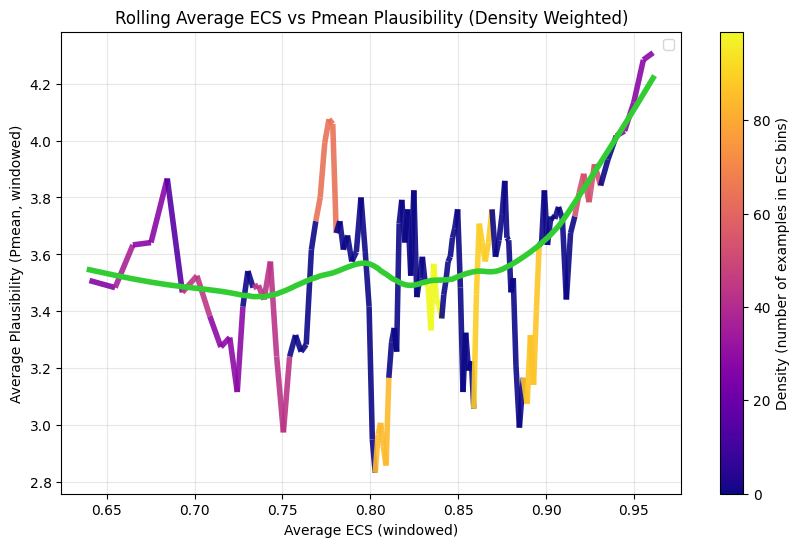

In [145]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths (UPDATED)
# -----------------------------
plaus_file = "esnli_llama_plausibility_scores.csv"  # <-- UPDATED
ecs_file   = "esnli_llama_rationales_with_ecs.csv"

# -----------------------------
# Load data (UPDATED COLUMN)
# -----------------------------
plaus_df = pd.read_csv(plaus_file)[["id", "Pmean"]]  # <-- USE Pmean
ecs_df   = pd.read_csv(ecs_file)[["id", "ECS"]]

# Merge into one dataset
df = plaus_df.merge(ecs_df, on="id", how="inner")
df = df.sort_values("ECS").reset_index(drop=True)

# Ensure numeric
df["Pmean"] = pd.to_numeric(df["Pmean"], errors="coerce")  # <-- UPDATED
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop missing rows
df = df.dropna(subset=["Pmean", "ECS"])

print(f"🔗 Final merged dataset: {len(df)} rows")

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.03
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 30
step_size = 5

avg_ecs_list = []
avg_plaus_list = []
window_density = []

# -----------------------------
# Compute rolling averages (UPDATED)
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_plaus_list.append(window["Pmean"].mean())  # <-- UPDATED

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()

    overlapping_bins = bin_stats[
        (bin_stats["bin_mid"] >= ecs_min) &
        (bin_stats["bin_mid"] <= ecs_max)
    ]

    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_plaus_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average ECS (windowed)")
ax.set_ylabel("Average Plausibility (Pmean, windowed)")  # <-- UPDATED LABEL
ax.set_title("Rolling Average ECS vs Pmean Plausibility (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# LOWESS smoothing
# -----------------------------
density_threshold = np.percentile(window_density, 0)  # keep all data
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
plaus_high = np.array(avg_plaus_list)[mask]

smooth = lowess(plaus_high, ecs_high, frac=0.30, return_sorted=True)

smooth_ecs  = smooth[:, 0]
smooth_plaus = smooth[:, 1]

ax.plot(smooth_ecs, smooth_plaus, color="#32CD32", linewidth=4)

ax.legend()

plt.show()

**Qwen 2.5**

In [37]:
import pandas as pd

# -----------------------------
# Your cleaning function
# -----------------------------
def clean_rationale(text):
    """
    Removes boilerplate such as 'Chain of Thought:' and 
    everything after 'Final Answer:'.
    """
    if not isinstance(text, str):
        return ""

    text = text.replace("Chain of Thought:", "").replace("CoT:", "").strip()

    # Remove everything after common final answer markers
    for tag in ["Final Answer:", "Answer:", "Conclusion:"]:
        if tag in text:
            text = text.split(tag)[0].strip()

    return text


# -----------------------------
# Load input CSV
# -----------------------------
INPUT_FILE = "qwen_esnli_rationales_filtered.csv"
OUTPUT_FILE = "qwen_esnli_rationales_filtered_cleaned.csv"

df = pd.read_csv(INPUT_FILE)

print(f"Loaded {len(df)} rows.")

# Columns that need cleaning
cols_to_clean = [
    "rationale_original",
    "rationale_perturbation_1_lexical",
    "rationale_perturbation_2_syntactic",
    "rationale_perturbation_3_pragmatic"
]

# Validate they exist
missing = [c for c in cols_to_clean if c not in df.columns]
assert len(missing) == 0, f"❌ Missing columns: {missing}"

# -----------------------------
# Create cleaned versions
# -----------------------------
for col in cols_to_clean:
    df[col + "_cleaned"] = df[col].apply(clean_rationale)

# -----------------------------
# Remove original columns
# -----------------------------
df = df.drop(columns=cols_to_clean)

# -----------------------------
# Save cleaned dataset
# -----------------------------
df.to_csv(OUTPUT_FILE, index=False)

print(f"✅ Success! Cleaned file saved as: {OUTPUT_FILE}")
print("👉 Only `_cleaned` rationale columns remain.")

Loaded 627 rows.
✅ Success! Cleaned file saved as: qwen_esnli_rationales_filtered_cleaned.csv
👉 Only `_cleaned` rationale columns remain.


In [38]:
import os
import pandas as pd
from vertexai.generative_models import GenerativeModel
import vertexai
import time
import csv
from tqdm import tqdm
import re


# ---------------------------
# 1. GOOGLE AUTHENTICATION 
# ---------------------------
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"
assert os.path.exists(SERVICE_ACCOUNT_PATH), f"❌ JSON file not found: {SERVICE_ACCOUNT_PATH}"
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH
print("✅ Google service account loaded.")


# ---------------------------
# 2. INITIALIZE GEMINI
# ---------------------------
vertexai.init(project="llm-reasoning-475315", location="us-central1")
model = GenerativeModel("gemini-2.5-flash")
print("✅ Gemini model initialized.")


# ---------------------------
# 3. LOAD DATA
# ---------------------------
rationales_df = pd.read_csv("qwen_esnli_rationales_filtered_cleaned.csv")
perturb_df = pd.read_csv("esnli_800_with_perturbations.csv")

# Keep only rows where we have rationales
perturb_df = perturb_df[perturb_df["id"].isin(rationales_df["id"])]

# Merge both datasets
merged = pd.merge(rationales_df, perturb_df, on="id", how="inner")
print("📌 Final merged dataset:", merged.shape)


# ---------------------------
# 4. PROMPT TEMPLATE
# ---------------------------
JUDGE_PROMPT = """

You are an expert evaluator of Natural Language Inference (NLI) explanations.

Your task is to judge the **plausibility and correctness of the MODEL RATIONALE** 
given the PREMISE, HYPOTHESIS, and the GOLD LABEL.

A plausible rationale is one that:
1. Uses ONLY information from the Premise (no external facts or assumptions).
2. Correctly explains why the GOLD LABEL logically follows.
3. Contains no contradictions, logical fallacies, or hallucinated details.
4. Is relevant and sufficient for justifying the label.

Ignore:
- writing style
- length
- verbosity
- grammar
These should NOT affect the score.

### SCORING RUBRIC (1–5):
5 = Excellent  
    - Fully correct reasoning.
    - Uses only premise information.
    - Explicitly supports the gold label with valid logical steps.

4 = Good  
    - Mostly correct and grounded.
    - Minor missing detail OR slight redundancy, but the justification is sound.

3 = Weak but Acceptable  
    - Partially correct reasoning.
    - Some vagueness OR a small incorrect assumption, but it still roughly supports the label.

2 = Flawed  
    - Significant logical gaps OR an incorrect justification.
    - Uses irrelevant or unsupported claims.
    - Does NOT adequately justify the gold label.

1 = Incorrect / Implausible  
    - Wrong reasoning OR contradicts the label.
    - Hallucinates facts not present in the premise.
    - Explanation is logically invalid.

### INPUT:
Premise: {premise}
Hypothesis: {hypothesis}
Gold Label: {label}
Model Rationale: {rationale}

### OUTPUT:
Output ONLY the integer score (1–5).

"""


# ---------------------------
# 5. SCORING FUNCTION (FIXED)
# ---------------------------
def score_rationale(premise, hypothesis, label, rationale):
    """Send one rationale to Gemini and extract plausibility score."""
    prompt = JUDGE_PROMPT.format(
        premise=premise,
        hypothesis=hypothesis,
        label=label,
        rationale=rationale
    )

    try:
        resp = model.generate_content(prompt)
        text = resp.text.strip()

        # Regex to extract 1..5 safely
        match = re.search(r"\b([1-5])\b", text)
        if match:
            return int(match.group(1))

        return None

    except Exception as e:
        tqdm.write(f"❌ Error for example: {e}")
        return None


# ---------------------------
# 6. PREPARE OUTPUT CSV
# ---------------------------
output_path = "esnli_qwen_plausibility_scores.csv"
write_header = not os.path.exists(output_path)

with open(output_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    # Write header if file doesn't exist
    if write_header:
        writer.writerow([
            "id",
            "plaus_original",
            "plaus_lexical",
            "plaus_syntactic",
            "plaus_pragmatic"
        ])
        print("📝 Created new output file with header.")


    # ---------------------------
    # 7. tqdm SCORING LOOP
    # ---------------------------
    for idx, row in tqdm(merged.iterrows(), total=len(merged), desc="Scoring Rationales"):

        ex_id = row["id"]
        premise = row["Premise"]
        gold_label = row["gold_label"]

        # Hypotheses
        hyp_orig  = row["Hypothesis"]
        hyp_pert1 = row["perturbation_1_lexical"]
        hyp_pert2 = row["perturbation_2_syntactic"]
        hyp_pert3 = row["perturbation_3_pragmatic"]

        # Rationales
        rat_orig  = row["rationale_original_cleaned"]
        rat_pert1 = row["rationale_perturbation_1_lexical_cleaned"]
        rat_pert2 = row["rationale_perturbation_2_syntactic_cleaned"]
        rat_pert3 = row["rationale_perturbation_3_pragmatic_cleaned"]

        # Score each rationale
        s0 = score_rationale(premise, hyp_orig,  gold_label, rat_orig)
        s1 = score_rationale(premise, hyp_pert1, gold_label, rat_pert1)
        s2 = score_rationale(premise, hyp_pert2, gold_label, rat_pert2)
        s3 = score_rationale(premise, hyp_pert3, gold_label, rat_pert3)

        # Write row immediately
        writer.writerow([ex_id, s0, s1, s2, s3])

        # --------------------------------------
        # 🔥 FORCE IMMEDIATE FLUSH TO DISK
        # --------------------------------------
        f.flush()
        os.fsync(f.fileno())
        # --------------------------------------

        # Optional small delay
        time.sleep(0.25)

print("🎉 DONE! All plausibility scores saved row-by-row with guaranteed flushing.")

/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


✅ Google service account loaded.
✅ Gemini model initialized.
📌 Final merged dataset: (627, 12)
📝 Created new output file with header.


Scoring Rationales: 100%|███████████████████| 627/627 [3:09:00<00:00, 18.09s/it]

🎉 DONE! All plausibility scores saved row-by-row with guaranteed flushing.


In [39]:
import pandas as pd

# -----------------------------
# File paths
# -----------------------------
INPUT_FILE = "esnli_qwen_plausibility_scores.csv"
OUTPUT_FILE = "esnli_qwen_plausibility_scores.csv"   # overwrite same file
# If you prefer a new file:
# OUTPUT_FILE = "esnli_gemini_plausibility_scores_with_pmean.csv"

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(INPUT_FILE)

# Columns containing plausibility scores
plaus_cols = ["plaus_original", "plaus_lexical", "plaus_syntactic", "plaus_pragmatic"]

# Ensure all required columns exist
missing = [c for c in plaus_cols if c not in df.columns]
assert len(missing) == 0, f"❌ Missing columns: {missing}"

# Convert to numeric (in case some values are strings)
df[plaus_cols] = df[plaus_cols].apply(pd.to_numeric, errors="coerce")

# -----------------------------
# Compute Pmean for each row
# -----------------------------
df["Pmean"] = df[plaus_cols].mean(axis=1)

# -----------------------------
# Save updated CSV
# -----------------------------
df.to_csv(OUTPUT_FILE, index=False)

print(f"✅ Successfully added Pmean column!\nSaved to: {OUTPUT_FILE}")

✅ Successfully added Pmean column!
Saved to: esnli_qwen_plausibility_scores.csv


🔗 Final merged dataset: 627 rows


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_20264/3485812047.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby("ecs_bin")["id"].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_20264/3485812047.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby("ecs_bin")["ECS"].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_20264/3485812047.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.leg

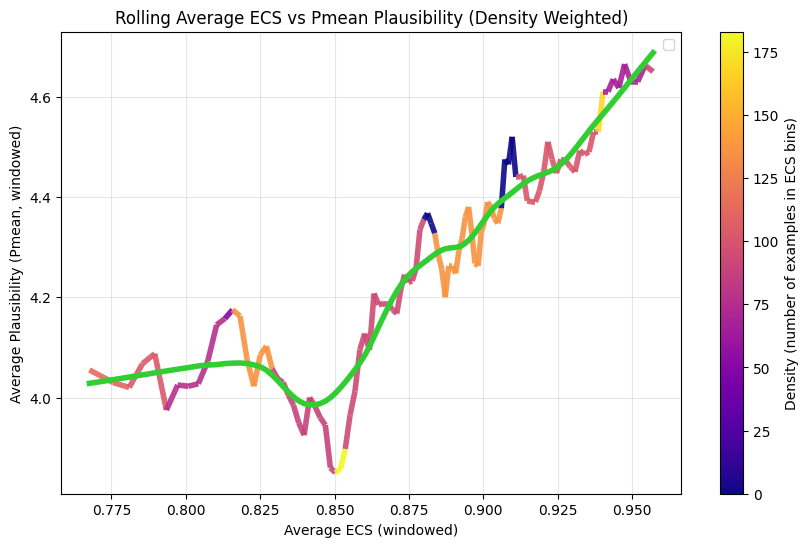

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths (UPDATED)
# -----------------------------
plaus_file = "esnli_qwen_plausibility_scores.csv"  # <-- UPDATED
ecs_file   = "qwen_esnli_rationales_with_ecs.csv"

# -----------------------------
# Load data (UPDATED COLUMN)
# -----------------------------
plaus_df = pd.read_csv(plaus_file)[["id", "Pmean"]]  # <-- USE Pmean
ecs_df   = pd.read_csv(ecs_file)[["id", "ECS"]]

# Merge into one dataset
df = plaus_df.merge(ecs_df, on="id", how="inner")
df = df.sort_values("ECS").reset_index(drop=True)

# Ensure numeric
df["Pmean"] = pd.to_numeric(df["Pmean"], errors="coerce")  # <-- UPDATED
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop missing rows
df = df.dropna(subset=["Pmean", "ECS"])

print(f"🔗 Final merged dataset: {len(df)} rows")

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.03
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 100
step_size = 5

avg_ecs_list = []
avg_plaus_list = []
window_density = []

# -----------------------------
# Compute rolling averages (UPDATED)
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_plaus_list.append(window["Pmean"].mean())  # <-- UPDATED

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()

    overlapping_bins = bin_stats[
        (bin_stats["bin_mid"] >= ecs_min) &
        (bin_stats["bin_mid"] <= ecs_max)
    ]

    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_plaus_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average ECS (windowed)")
ax.set_ylabel("Average Plausibility (Pmean, windowed)")  # <-- UPDATED LABEL
ax.set_title("Rolling Average ECS vs Pmean Plausibility (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# LOWESS smoothing
# -----------------------------
density_threshold = np.percentile(window_density, 0)  # keep all data
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
plaus_high = np.array(avg_plaus_list)[mask]

smooth = lowess(plaus_high, ecs_high, frac=0.20, return_sorted=True)

smooth_ecs  = smooth[:, 0]
smooth_plaus = smooth[:, 1]

ax.plot(smooth_ecs, smooth_plaus, color="#32CD32", linewidth=4)

ax.legend()

plt.show()

**Mistral**

In [43]:
import pandas as pd

# -----------------------------
# Your cleaning function
# -----------------------------
def clean_rationale(text):
    """
    Removes boilerplate such as 'Chain of Thought:' and 
    everything after 'Final Answer:'.
    """
    if not isinstance(text, str):
        return ""

    text = text.replace("Chain of Thought:", "").replace("CoT:", "").strip()

    # Remove everything after common final answer markers
    for tag in ["Final Answer:", "Answer:", "Conclusion:"]:
        if tag in text:
            text = text.split(tag)[0].strip()

    return text


# -----------------------------
# Load input CSV
# -----------------------------
INPUT_FILE = "esnli_mistral_rationales_filtered.csv"
OUTPUT_FILE = "esnli_mistral_rationales_filtered_cleaned.csv"

df = pd.read_csv(INPUT_FILE)

print(f"Loaded {len(df)} rows.")

# Columns that need cleaning
cols_to_clean = [
    "rationale_original",
    "rationale_lexical",
    "rationale_syntactic",
    "rationale_pragmatic"
]

# Validate they exist
missing = [c for c in cols_to_clean if c not in df.columns]
assert len(missing) == 0, f"❌ Missing columns: {missing}"

# -----------------------------
# Create cleaned versions
# -----------------------------
for col in cols_to_clean:
    df[col + "_cleaned"] = df[col].apply(clean_rationale)

# -----------------------------
# Remove original columns
# -----------------------------
df = df.drop(columns=cols_to_clean)

# -----------------------------
# Save cleaned dataset
# -----------------------------
df.to_csv(OUTPUT_FILE, index=False)

print(f"✅ Success! Cleaned file saved as: {OUTPUT_FILE}")
print("👉 Only `_cleaned` rationale columns remain.")

Loaded 623 rows.
✅ Success! Cleaned file saved as: esnli_mistral_rationales_filtered_cleaned.csv
👉 Only `_cleaned` rationale columns remain.


In [48]:
import os
import pandas as pd
from vertexai.generative_models import GenerativeModel
import vertexai
import time
import csv
from tqdm import tqdm
import re


# ---------------------------
# 1. GOOGLE AUTHENTICATION 
# ---------------------------
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"
assert os.path.exists(SERVICE_ACCOUNT_PATH), f"❌ JSON file not found: {SERVICE_ACCOUNT_PATH}"
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH
print("✅ Google service account loaded.")


# ---------------------------
# 2. INITIALIZE GEMINI
# ---------------------------
vertexai.init(project="llm-reasoning-475315", location="us-central1")
model = GenerativeModel("gemini-2.5-flash")
print("✅ Gemini model initialized.")


# ---------------------------
# 3. LOAD DATA
# ---------------------------
rationales_df = pd.read_csv("esnli_mistral_rationales_filtered_cleaned.csv")
perturb_df = pd.read_csv("esnli_800_with_perturbations.csv")

# Keep only rows where we have rationales
perturb_df = perturb_df[perturb_df["id"].isin(rationales_df["id"])]

# Merge both datasets
merged = pd.merge(rationales_df, perturb_df, on="id", how="inner")
print("📌 Final merged dataset:", merged.shape)


# ---------------------------
# 4. PROMPT TEMPLATE
# ---------------------------
JUDGE_PROMPT = """

You are an expert evaluator of Natural Language Inference (NLI) explanations.

Your task is to judge the **plausibility and correctness of the MODEL RATIONALE** 
given the PREMISE, HYPOTHESIS, and the GOLD LABEL.

A plausible rationale is one that:
1. Uses ONLY information from the Premise (no external facts or assumptions).
2. Correctly explains why the GOLD LABEL logically follows.
3. Contains no contradictions, logical fallacies, or hallucinated details.
4. Is relevant and sufficient for justifying the label.

Ignore:
- writing style
- length
- verbosity
- grammar
These should NOT affect the score.

### SCORING RUBRIC (1–5):
5 = Excellent  
    - Fully correct reasoning.
    - Uses only premise information.
    - Explicitly supports the gold label with valid logical steps.

4 = Good  
    - Mostly correct and grounded.
    - Minor missing detail OR slight redundancy, but the justification is sound.

3 = Weak but Acceptable  
    - Partially correct reasoning.
    - Some vagueness OR a small incorrect assumption, but it still roughly supports the label.

2 = Flawed  
    - Significant logical gaps OR an incorrect justification.
    - Uses irrelevant or unsupported claims.
    - Does NOT adequately justify the gold label.

1 = Incorrect / Implausible  
    - Wrong reasoning OR contradicts the label.
    - Hallucinates facts not present in the premise.
    - Explanation is logically invalid.

### INPUT:
Premise: {premise}
Hypothesis: {hypothesis}
Gold Label: {label}
Model Rationale: {rationale}

### OUTPUT:
Output ONLY the integer score (1–5).

"""


# ---------------------------
# 5. SCORING FUNCTION (FIXED)
# ---------------------------
def score_rationale(premise, hypothesis, label, rationale):
    """Send one rationale to Gemini and extract plausibility score."""
    prompt = JUDGE_PROMPT.format(
        premise=premise,
        hypothesis=hypothesis,
        label=label,
        rationale=rationale
    )

    try:
        resp = model.generate_content(prompt)
        text = resp.text.strip()

        # Regex to extract 1..5 safely
        match = re.search(r"\b([1-5])\b", text)
        if match:
            return int(match.group(1))

        return None

    except Exception as e:
        tqdm.write(f"❌ Error for example: {e}")
        return None


# ---------------------------
# 6. PREPARE OUTPUT CSV
# ---------------------------
output_path = "esnli_mistral_plausibility_scores.csv"
write_header = not os.path.exists(output_path)

with open(output_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    # Write header if file doesn't exist
    if write_header:
        writer.writerow([
            "id",
            "plaus_original",
            "plaus_lexical",
            "plaus_syntactic",
            "plaus_pragmatic"
        ])
        print("📝 Created new output file with header.")


    # ---------------------------
    # 7. tqdm SCORING LOOP
    # ---------------------------
    for idx, row in tqdm(merged.iterrows(), total=len(merged), desc="Scoring Rationales"):

        ex_id = row["id"]
        premise = row["Premise"]
        gold_label = row["gold_label"]

        # Hypotheses
        hyp_orig  = row["Hypothesis"]
        hyp_pert1 = row["perturbation_1_lexical"]
        hyp_pert2 = row["perturbation_2_syntactic"]
        hyp_pert3 = row["perturbation_3_pragmatic"]

        # Rationales
        rat_orig  = row["rationale_original_cleaned"]
        rat_pert1 = row["rationale_lexical_cleaned"]
        rat_pert2 = row["rationale_syntactic_cleaned"]
        rat_pert3 = row["rationale_pragmatic_cleaned"]

        # Score each rationale
        s0 = score_rationale(premise, hyp_orig,  gold_label, rat_orig)
        s1 = score_rationale(premise, hyp_pert1, gold_label, rat_pert1)
        s2 = score_rationale(premise, hyp_pert2, gold_label, rat_pert2)
        s3 = score_rationale(premise, hyp_pert3, gold_label, rat_pert3)

        # Write row immediately
        writer.writerow([ex_id, s0, s1, s2, s3])

        # --------------------------------------
        # 🔥 FORCE IMMEDIATE FLUSH TO DISK
        # --------------------------------------
        f.flush()
        os.fsync(f.fileno())
        # --------------------------------------

        # Optional small delay
        time.sleep(0.25)

print("🎉 DONE! All plausibility scores saved row-by-row with guaranteed flushing.")

/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


✅ Google service account loaded.
✅ Gemini model initialized.
📌 Final merged dataset: (623, 12)


Scoring Rationales: 100%|███████████████████| 623/623 [4:18:05<00:00, 24.86s/it]

🎉 DONE! All plausibility scores saved row-by-row with guaranteed flushing.


In [49]:
import pandas as pd

# -----------------------------
# File paths
# -----------------------------
INPUT_FILE = "esnli_mistral_plausibility_scores.csv"
OUTPUT_FILE = "esnli_mistral_plausibility_scores.csv"   # overwrite same file
# If you prefer a new file:
# OUTPUT_FILE = "esnli_gemini_plausibility_scores_with_pmean.csv"

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(INPUT_FILE)

# Columns containing plausibility scores
plaus_cols = ["plaus_original", "plaus_lexical", "plaus_syntactic", "plaus_pragmatic"]

# Ensure all required columns exist
missing = [c for c in plaus_cols if c not in df.columns]
assert len(missing) == 0, f"❌ Missing columns: {missing}"

# Convert to numeric (in case some values are strings)
df[plaus_cols] = df[plaus_cols].apply(pd.to_numeric, errors="coerce")

# -----------------------------
# Compute Pmean for each row
# -----------------------------
df["Pmean"] = df[plaus_cols].mean(axis=1)

# -----------------------------
# Save updated CSV
# -----------------------------
df.to_csv(OUTPUT_FILE, index=False)

print(f"✅ Successfully added Pmean column!\nSaved to: {OUTPUT_FILE}")

✅ Successfully added Pmean column!
Saved to: esnli_mistral_plausibility_scores.csv


🔗 Final merged dataset: 623 rows


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_20264/2486888951.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby("ecs_bin")["id"].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_20264/2486888951.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby("ecs_bin")["ECS"].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_20264/2486888951.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.leg

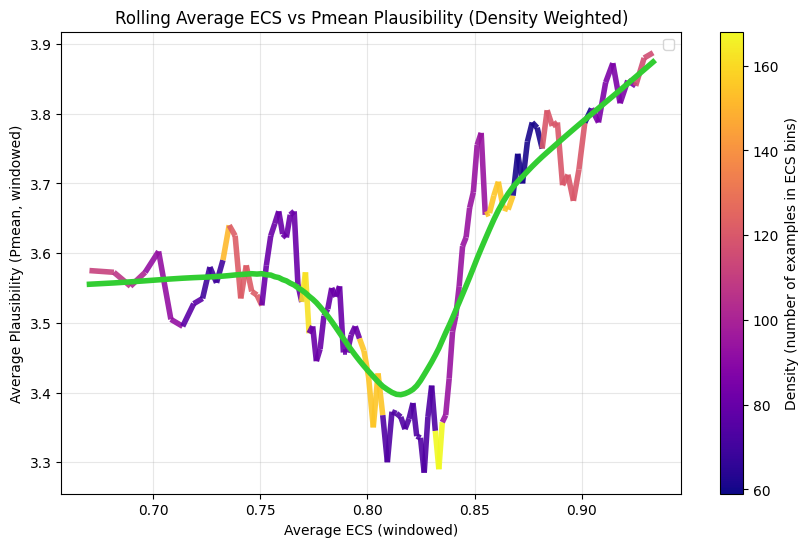

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths (UPDATED)
# -----------------------------
plaus_file = "esnli_mistral_plausibility_scores.csv"  # <-- UPDATED
ecs_file   = "esnli_mistral_rationales_with_ecs.csv"
# -----------------------------
# Load data (UPDATED COLUMN)
# -----------------------------
plaus_df = pd.read_csv(plaus_file)[["id", "Pmean"]]  # <-- USE Pmean
ecs_df   = pd.read_csv(ecs_file)[["id", "ECS"]]

# Merge into one dataset
df = plaus_df.merge(ecs_df, on="id", how="inner")
df = df.sort_values("ECS").reset_index(drop=True)

# Ensure numeric
df["Pmean"] = pd.to_numeric(df["Pmean"], errors="coerce")  # <-- UPDATED
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop missing rows
df = df.dropna(subset=["Pmean", "ECS"])

print(f"🔗 Final merged dataset: {len(df)} rows")

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.03
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 100
step_size = 5

avg_ecs_list = []
avg_plaus_list = []
window_density = []

# -----------------------------
# Compute rolling averages (UPDATED)
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_plaus_list.append(window["Pmean"].mean())  # <-- UPDATED

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()

    overlapping_bins = bin_stats[
        (bin_stats["bin_mid"] >= ecs_min) &
        (bin_stats["bin_mid"] <= ecs_max)
    ]

    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_plaus_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average ECS (windowed)")
ax.set_ylabel("Average Plausibility (Pmean, windowed)")  # <-- UPDATED LABEL
ax.set_title("Rolling Average ECS vs Pmean Plausibility (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# LOWESS smoothing
# -----------------------------
density_threshold = np.percentile(window_density, 0)  # keep all data
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
plaus_high = np.array(avg_plaus_list)[mask]

smooth = lowess(plaus_high, ecs_high, frac=0.40, return_sorted=True)

smooth_ecs  = smooth[:, 0]
smooth_plaus = smooth[:, 1]

ax.plot(smooth_ecs, smooth_plaus, color="#32CD32", linewidth=4)

ax.legend()

plt.show()

In [30]:
import pandas as pd

# Load the CSV
file_path = "esnli_gemini_plausibility_scores.csv"
df = pd.read_csv(file_path)

# Drop rows 2 through 632 (1-based indexing)
# Pandas uses 0-based indexing, so rows 1 to 631
df_cleaned = df.drop(index=range(1, 632))

# Reset index (optional but recommended)
df_cleaned.reset_index(drop=True, inplace=True)

# Save back to CSV (overwrite the file)
df_cleaned.to_csv(file_path, index=False)

print("Rows 2 through 632 have been deleted successfully.")


Rows 2 through 632 have been deleted successfully.


**Accuracy**

In [151]:
import pandas as pd

def compute_row_accuracy(
    pred_csv="esnli_gemini_final_answers.csv",
    gold_csv="esnli_800_with_perturbations.csv",
    output_csv="esnli_gemini_accuracy.csv"
):
    """
    Loads prediction CSV + gold label CSV, merges on id,
    compares each predicted answer to gold_label (case-insensitive),
    and computes per-row mean accuracy across the 4 rationale versions.
    """

    # Load files
    preds = pd.read_csv(pred_csv)
    gold = pd.read_csv(gold_csv)

    # Normalize gold labels to lowercase
    gold["gold_label"] = gold["gold_label"].str.lower()

    # Merge on id
    df = preds.merge(gold[["id", "gold_label"]], on="id", how="inner")

    # Prediction columns
    pred_cols = [
        "rationale_original_final",
        "rationale_pert1_final",
        "rationale_pert2_final",
        "rationale_pert3_final"
    ]

    # Normalize predicted answers to lowercase
    for col in pred_cols:
        df[col] = df[col].str.lower()

    # Compute correctness (1 = correct, 0 = incorrect)
    for col in pred_cols:
        df[col + "_correct"] = (df[col] == df["gold_label"]).astype(int)

    # Mean accuracy across the four versions
    df["row_accuracy"] = df[[c + "_correct" for c in pred_cols]].mean(axis=1)

    # Output columns
    output_cols = ["id"] + pred_cols + ["gold_label", "row_accuracy"]
    df_output = df[output_cols]

    # Save file
    df_output.to_csv(output_csv, index=False)

    return df_output

# Run the updated function
df_accuracy = compute_row_accuracy()
df_accuracy.head()

,id,rationale_original_final,rationale_pert1_final,rationale_pert2_final,rationale_pert3_final,gold_label,row_accuracy
0,1,contradiction,contradiction,contradiction,contradiction,contradiction,1.0
1,2,contradiction,contradiction,contradiction,contradiction,contradiction,1.0
2,6,neutral,neutral,neutral,neutral,contradiction,0.0
3,7,entailment,entailment,entailment,entailment,entailment,1.0
4,8,entailment,entailment,entailment,entailment,entailment,1.0


**Llama**

In [160]:
import pandas as pd

def compute_row_accuracy(
    pred_csv="esnli_llama_final_answers.csv",
    gold_csv="esnli_800_with_perturbations.csv",
    output_csv="esnli_llama_accuracy.csv"
):
    """
    Loads prediction CSV + gold label CSV, merges on id,
    compares each predicted answer to gold_label (case-insensitive),
    and computes per-row mean accuracy across the 4 rationale versions.
    """

    # Load files
    preds = pd.read_csv(pred_csv)
    gold = pd.read_csv(gold_csv)

    # Normalize gold labels to lowercase
    gold["gold_label"] = gold["gold_label"].str.lower()

    # Merge on id
    df = preds.merge(gold[["id", "gold_label"]], on="id", how="inner")

    # Prediction columns
    pred_cols = [
        "rationale_original_final",
        "rationale_lexical_final",
        "rationale_syntactic_final",
        "rationale_pragmatic_final"
    ]

    # Normalize predicted answers to lowercase
    for col in pred_cols:
        df[col] = df[col].str.lower()

    # Compute correctness (1 = correct, 0 = incorrect)
    for col in pred_cols:
        df[col + "_correct"] = (df[col] == df["gold_label"]).astype(int)

    # Mean accuracy across the four versions
    df["row_accuracy"] = df[[c + "_correct" for c in pred_cols]].mean(axis=1)

    # Output columns
    output_cols = ["id"] + pred_cols + ["gold_label", "row_accuracy"]
    df_output = df[output_cols]

    # Save file
    df_output.to_csv(output_csv, index=False)

    return df_output

# Run the updated function
df_accuracy = compute_row_accuracy()
df_accuracy.head()

,id,rationale_original_final,rationale_lexical_final,rationale_syntactic_final,rationale_pragmatic_final,gold_label,row_accuracy
0,1,neutral,neutral,neutral,neutral,contradiction,0.00
1,2,neutral,neutral,neutral,neutral,contradiction,0.00
2,6,neutral,neutral,neutral,neutral,contradiction,0.00
3,7,entailment,neutral,entailment,entailment,entailment,0.75
4,8,entailment,entailment,entailment,entailment,entailment,1.00


**Mistral**

In [174]:
import pandas as pd

def compute_row_accuracy(
    pred_csv="esnli_mistral_final_answers.csv",
    gold_csv="esnli_800_with_perturbations.csv",
    output_csv="esnli_mistral_accuracy.csv"
):
    """
    Loads prediction CSV + gold label CSV, merges on id,
    compares each predicted answer to gold_label (case-insensitive),
    and computes per-row mean accuracy across the 4 rationale versions.
    """

    # Load files
    preds = pd.read_csv(pred_csv)
    gold = pd.read_csv(gold_csv)

    # Normalize gold labels to lowercase
    gold["gold_label"] = gold["gold_label"].str.lower()

    # Merge on id
    df = preds.merge(gold[["id", "gold_label"]], on="id", how="inner")

    # Prediction columns
    pred_cols = [
        "rationale_original_final",
        "rationale_lexical_final",
        "rationale_syntactic_final",
        "rationale_pragmatic_final"
    ]

    # Normalize predicted answers to lowercase
    for col in pred_cols:
        df[col] = df[col].str.lower()

    # Compute correctness (1 = correct, 0 = incorrect)
    for col in pred_cols:
        df[col + "_correct"] = (df[col] == df["gold_label"]).astype(int)

    # Mean accuracy across the four versions
    df["row_accuracy"] = df[[c + "_correct" for c in pred_cols]].mean(axis=1)

    # Output columns
    output_cols = ["id"] + pred_cols + ["gold_label", "row_accuracy"]
    df_output = df[output_cols]

    # Save file
    df_output.to_csv(output_csv, index=False)

    return df_output

# Run the updated function
df_accuracy = compute_row_accuracy()
df_accuracy.head()

,id,rationale_original_final,rationale_lexical_final,rationale_syntactic_final,rationale_pragmatic_final,gold_label,row_accuracy
0,1,neutral,neutral,neutral,neutral,contradiction,0.0
1,2,neutral,neutral,neutral,neutral,contradiction,0.0
2,6,entailment,neutral,neutral,neutral,contradiction,0.0
3,7,entailment,entailment,entailment,entailment,entailment,1.0
4,8,entailment,entailment,entailment,entailment,entailment,1.0


**Qwen2.5**

In [178]:
import pandas as pd

def compute_row_accuracy(
    pred_csv="qwen_esnli_final_answers.csv",
    gold_csv="esnli_800_with_perturbations.csv",
    output_csv="esnli_qwen_accuracy.csv"
):
    """
    Loads prediction CSV + gold label CSV, merges on id,
    compares each predicted answer to gold_label (case-insensitive),
    and computes per-row mean accuracy across the 4 rationale versions.
    """

    # Load files
    preds = pd.read_csv(pred_csv)
    gold = pd.read_csv(gold_csv)

    # Normalize gold labels to lowercase
    gold["gold_label"] = gold["gold_label"].str.lower()

    # Merge on id
    df = preds.merge(gold[["id", "gold_label"]], on="id", how="inner")

    # Prediction columns
    pred_cols = [
        "rationale_original_final",
        "rationale_perturbation_1_lexical_final",
        "rationale_perturbation_2_syntactic_final",
        "rationale_perturbation_3_pragmatic_final"
    ]

    # Normalize predicted answers to lowercase
    for col in pred_cols:
        df[col] = df[col].str.lower()

    # Compute correctness (1 = correct, 0 = incorrect)
    for col in pred_cols:
        df[col + "_correct"] = (df[col] == df["gold_label"]).astype(int)

    # Mean accuracy across the four versions
    df["row_accuracy"] = df[[c + "_correct" for c in pred_cols]].mean(axis=1)

    # Output columns
    output_cols = ["id"] + pred_cols + ["gold_label", "row_accuracy"]
    df_output = df[output_cols]

    # Save file
    df_output.to_csv(output_csv, index=False)

    return df_output

# Run the updated function
df_accuracy = compute_row_accuracy()
df_accuracy.head()

,id,rationale_original_final,rationale_perturbation_1_lexical_final,rationale_perturbation_2_syntactic_final,rationale_perturbation_3_pragmatic_final,gold_label,row_accuracy
0,1,contradiction,neutral,contradiction,neutral,contradiction,0.5
1,2,contradiction,contradiction,contradiction,contradiction,contradiction,1.0
2,6,neutral,neutral,neutral,neutral,contradiction,0.0
3,7,entailment,entailment,entailment,entailment,entailment,1.0
4,8,entailment,entailment,entailment,entailment,entailment,1.0


**Plausibility-Accuracy Gemini**

Pearson correlation between row_accuracy and Pmean: 0.9870


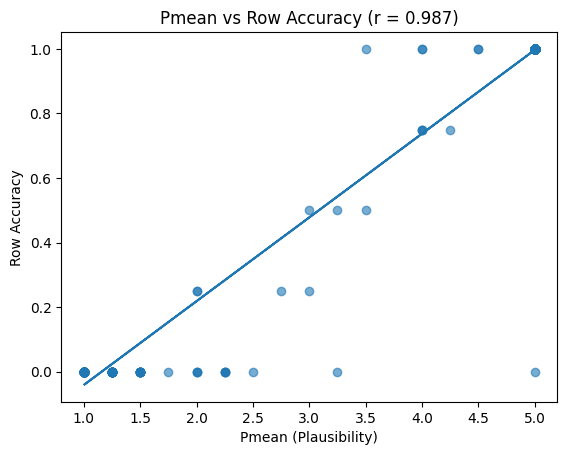

In [183]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV files
accuracy_path = "esnli_gemini_accuracy.csv"
plausibility_path = "esnli_gemini_plausibility_scores.csv"

df_accuracy = pd.read_csv(accuracy_path)
df_plausibility = pd.read_csv(plausibility_path)

# Merge on the unique id
df_merged = pd.merge(
    df_accuracy[['id', 'row_accuracy']],
    df_plausibility[['id', 'Pmean']],
    on='id',
    how='inner'
)

# Drop any rows with missing values (safety)
df_merged = df_merged.dropna(subset=['row_accuracy', 'Pmean'])

# Compute correlation
correlation = df_merged['row_accuracy'].corr(df_merged['Pmean'])

print(f"Pearson correlation between row_accuracy and Pmean: {correlation:.4f}")

# ---- Plot ----
plt.figure()
plt.scatter(df_merged['Pmean'], df_merged['row_accuracy'], alpha=0.6)

# Best-fit line
m, b = np.polyfit(df_merged['Pmean'], df_merged['row_accuracy'], 1)
plt.plot(df_merged['Pmean'], m * df_merged['Pmean'] + b)

plt.xlabel("Pmean (Plausibility)")
plt.ylabel("Row Accuracy")
plt.title(f"Pmean vs Row Accuracy (r = {correlation:.3f})")

plt.show()


**Plausibility-Accuracy Llama**

Pearson correlation between row_accuracy and Pmean: 0.9421


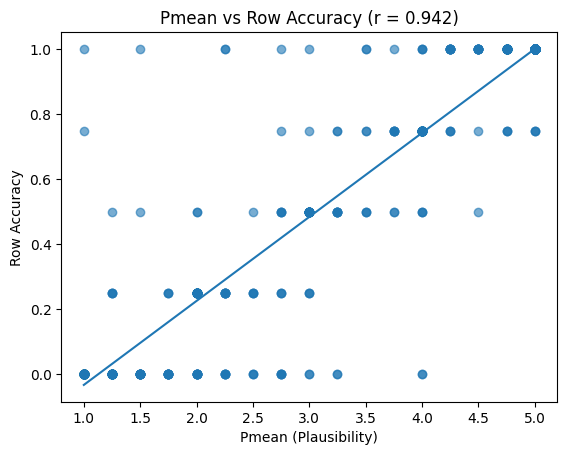

In [185]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV files
accuracy_path = "esnli_llama_accuracy.csv"
plausibility_path = "esnli_llama_plausibility_scores.csv"

df_accuracy = pd.read_csv(accuracy_path)
df_plausibility = pd.read_csv(plausibility_path)

# Merge on the unique id
df_merged = pd.merge(
    df_accuracy[['id', 'row_accuracy']],
    df_plausibility[['id', 'Pmean']],
    on='id',
    how='inner'
)

# Drop any rows with missing values (safety)
df_merged = df_merged.dropna(subset=['row_accuracy', 'Pmean'])

# Compute correlation
correlation = df_merged['row_accuracy'].corr(df_merged['Pmean'])

print(f"Pearson correlation between row_accuracy and Pmean: {correlation:.4f}")

# ---- Plot ----
plt.figure()
plt.scatter(df_merged['Pmean'], df_merged['row_accuracy'], alpha=0.6)

# Best-fit line
m, b = np.polyfit(df_merged['Pmean'], df_merged['row_accuracy'], 1)
plt.plot(df_merged['Pmean'], m * df_merged['Pmean'] + b)

plt.xlabel("Pmean (Plausibility)")
plt.ylabel("Row Accuracy")
plt.title(f"Pmean vs Row Accuracy (r = {correlation:.3f})")

plt.show()


**Plausibility-Accuracy Mistral**

Pearson correlation between row_accuracy and Pmean: 0.8606


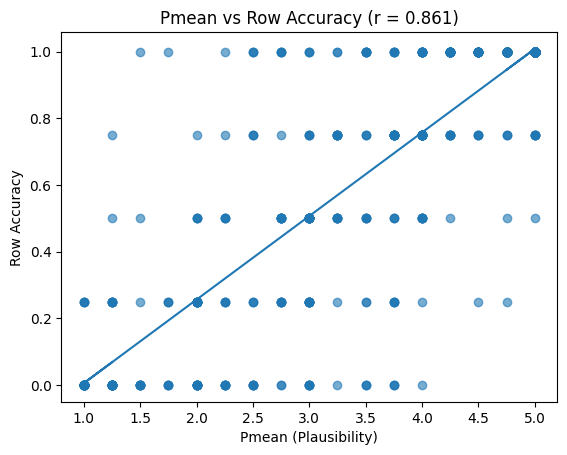

In [187]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV files
accuracy_path = "esnli_mistral_accuracy.csv"
plausibility_path = "esnli_mistral_plausibility_scores.csv"

df_accuracy = pd.read_csv(accuracy_path)
df_plausibility = pd.read_csv(plausibility_path)

# Merge on the unique id
df_merged = pd.merge(
    df_accuracy[['id', 'row_accuracy']],
    df_plausibility[['id', 'Pmean']],
    on='id',
    how='inner'
)

# Drop any rows with missing values (safety)
df_merged = df_merged.dropna(subset=['row_accuracy', 'Pmean'])

# Compute correlation
correlation = df_merged['row_accuracy'].corr(df_merged['Pmean'])

print(f"Pearson correlation between row_accuracy and Pmean: {correlation:.4f}")

# ---- Plot ----
plt.figure()
plt.scatter(df_merged['Pmean'], df_merged['row_accuracy'], alpha=0.6)

# Best-fit line
m, b = np.polyfit(df_merged['Pmean'], df_merged['row_accuracy'], 1)
plt.plot(df_merged['Pmean'], m * df_merged['Pmean'] + b)

plt.xlabel("Pmean (Plausibility)")
plt.ylabel("Row Accuracy")
plt.title(f"Pmean vs Row Accuracy (r = {correlation:.3f})")

plt.show()


**Plausibility-Accuracy Qwen**

Pearson correlation between row_accuracy and Pmean: 0.9478


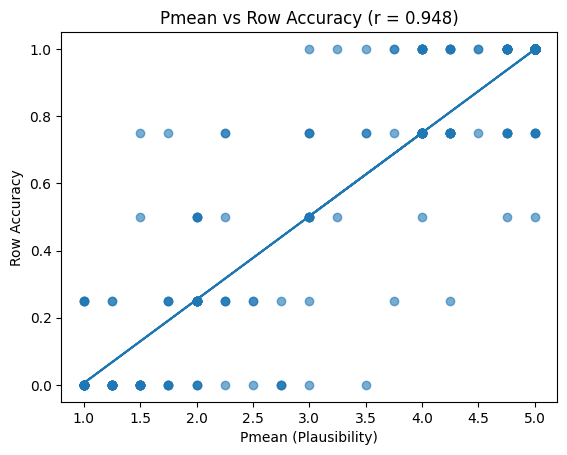

In [189]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV files
accuracy_path = "esnli_qwen_accuracy.csv"
plausibility_path = "esnli_qwen_plausibility_scores.csv"

df_accuracy = pd.read_csv(accuracy_path)
df_plausibility = pd.read_csv(plausibility_path)

# Merge on the unique id
df_merged = pd.merge(
    df_accuracy[['id', 'row_accuracy']],
    df_plausibility[['id', 'Pmean']],
    on='id',
    how='inner'
)

# Drop any rows with missing values (safety)
df_merged = df_merged.dropna(subset=['row_accuracy', 'Pmean'])

# Compute correlation
correlation = df_merged['row_accuracy'].corr(df_merged['Pmean'])

print(f"Pearson correlation between row_accuracy and Pmean: {correlation:.4f}")

# ---- Plot ----
plt.figure()
plt.scatter(df_merged['Pmean'], df_merged['row_accuracy'], alpha=0.6)

# Best-fit line
m, b = np.polyfit(df_merged['Pmean'], df_merged['row_accuracy'], 1)
plt.plot(df_merged['Pmean'], m * df_merged['Pmean'] + b)

plt.xlabel("Pmean (Plausibility)")
plt.ylabel("Row Accuracy")
plt.title(f"Pmean vs Row Accuracy (r = {correlation:.3f})")

plt.show()


Final merged dataset: 627 rows


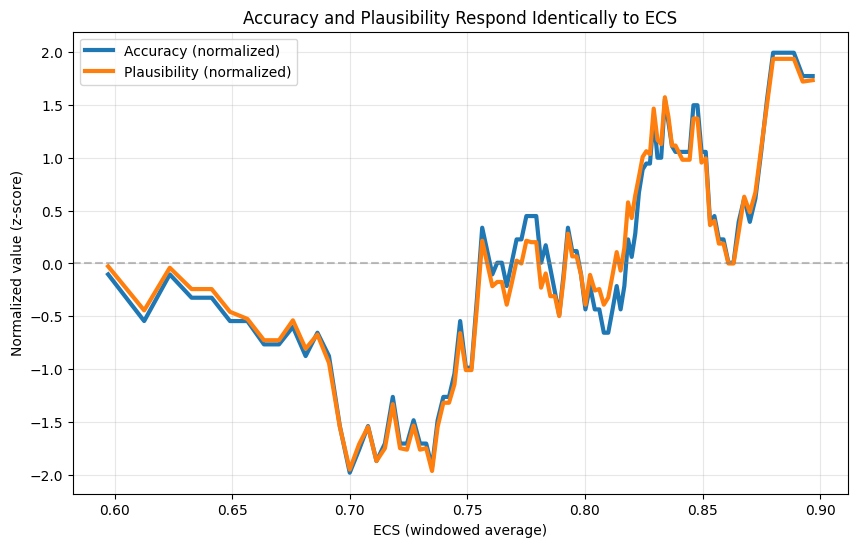

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
accuracy_file = "esnli_gemini_accuracy.csv"
plaus_file    = "esnli_gemini_plausibility_scores.csv"
ecs_file      = "esnli_gemini_rationales_with_ecs.csv"

# -----------------------------
# Load data
# -----------------------------
acc_df   = pd.read_csv(accuracy_file)[["id", "row_accuracy"]]
plaus_df = pd.read_csv(plaus_file)[["id", "Pmean"]]
ecs_df   = pd.read_csv(ecs_file)[["id", "ECS"]]

acc_df = acc_df.rename(columns={"row_accuracy": "accuracy"})

# Merge everything
df = acc_df.merge(plaus_df, on="id", how="inner") \
           .merge(ecs_df, on="id", how="inner")

# Ensure numeric + clean
for col in ["accuracy", "Pmean", "ECS"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()
df = df.sort_values("ECS").reset_index(drop=True)

print(f"Final merged dataset: {len(df)} rows")

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 100
step_size = 5

ecs_avg = []
acc_avg = []
plaus_avg = []

for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    ecs_avg.append(window["ECS"].mean())
    acc_avg.append(window["accuracy"].mean())
    plaus_avg.append(window["Pmean"].mean())

ecs_avg = np.array(ecs_avg)
acc_avg = np.array(acc_avg)
plaus_avg = np.array(plaus_avg)

# -----------------------------
# Normalize (Z-score)
# -----------------------------
def zscore(x):
    return (x - np.mean(x)) / np.std(x)

acc_norm   = zscore(acc_avg)
plaus_norm = zscore(plaus_avg)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    ecs_avg,
    acc_norm,
    label="Accuracy (normalized)",
    linewidth=3
)

plt.plot(
    ecs_avg,
    plaus_norm,
    label="Plausibility (normalized)",
    linewidth=3
)

plt.axhline(0, color="gray", linestyle="--", alpha=0.5)

plt.xlabel("ECS (windowed average)")
plt.ylabel("Normalized value (z-score)")
plt.title("Accuracy and Plausibility Respond Identically to ECS")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


Final merged dataset: 627 rows


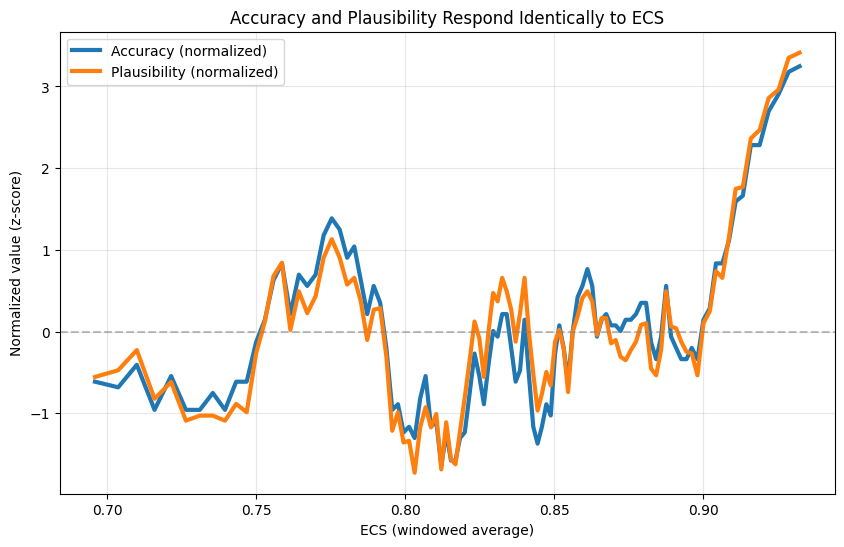

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# File paths
# -----------------------------
accuracy_file = "esnli_llama_accuracy.csv"
plaus_file    = "esnli_llama_plausibility_scores.csv"
ecs_file      = "esnli_llama_rationales_with_ecs.csv"

# -----------------------------
# Load data
# -----------------------------
acc_df   = pd.read_csv(accuracy_file)[["id", "row_accuracy"]]
plaus_df = pd.read_csv(plaus_file)[["id", "Pmean"]]
ecs_df   = pd.read_csv(ecs_file)[["id", "ECS"]]

acc_df = acc_df.rename(columns={"row_accuracy": "accuracy"})

# Merge everything
df = acc_df.merge(plaus_df, on="id", how="inner") \
           .merge(ecs_df, on="id", how="inner")

# Ensure numeric + clean
for col in ["accuracy", "Pmean", "ECS"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()
df = df.sort_values("ECS").reset_index(drop=True)

print(f"Final merged dataset: {len(df)} rows")

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 100
step_size = 5

ecs_avg = []
acc_avg = []
plaus_avg = []

for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    ecs_avg.append(window["ECS"].mean())
    acc_avg.append(window["accuracy"].mean())
    plaus_avg.append(window["Pmean"].mean())

ecs_avg = np.array(ecs_avg)
acc_avg = np.array(acc_avg)
plaus_avg = np.array(plaus_avg)

# -----------------------------
# Normalize (Z-score)
# -----------------------------
def zscore(x):
    return (x - np.mean(x)) / np.std(x)

acc_norm   = zscore(acc_avg)
plaus_norm = zscore(plaus_avg)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    ecs_avg,
    acc_norm,
    label="Accuracy (normalized)",
    linewidth=3
)

plt.plot(
    ecs_avg,
    plaus_norm,
    label="Plausibility (normalized)",
    linewidth=3
)

plt.axhline(0, color="gray", linestyle="--", alpha=0.5)

plt.xlabel("ECS (windowed average)")
plt.ylabel("Normalized value (z-score)")
plt.title("Accuracy and Plausibility Respond Identically to ECS")
plt.legend()
plt.grid(alpha=0.3)

plt.show()



Final merged dataset: 623 rows


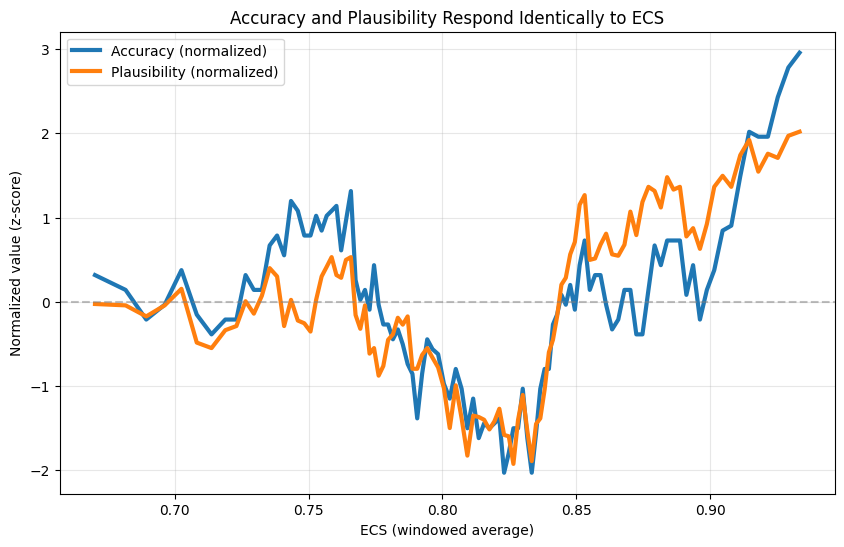

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# File paths
# -----------------------------
accuracy_path = "esnli_mistral_accuracy.csv"
plaus_file    = "esnli_mistral_plausibility_scores.csv"
ecs_file      = "esnli_mistral_rationales_with_ecs.csv"

# -----------------------------
# Load data
# -----------------------------
acc_df   = pd.read_csv(accuracy_file)[["id", "row_accuracy"]]
plaus_df = pd.read_csv(plaus_file)[["id", "Pmean"]]
ecs_df   = pd.read_csv(ecs_file)[["id", "ECS"]]

acc_df = acc_df.rename(columns={"row_accuracy": "accuracy"})

# Merge everything
df = acc_df.merge(plaus_df, on="id", how="inner") \
           .merge(ecs_df, on="id", how="inner")

# Ensure numeric + clean
for col in ["accuracy", "Pmean", "ECS"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()
df = df.sort_values("ECS").reset_index(drop=True)

print(f"Final merged dataset: {len(df)} rows")

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 100
step_size = 5

ecs_avg = []
acc_avg = []
plaus_avg = []

for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    ecs_avg.append(window["ECS"].mean())
    acc_avg.append(window["accuracy"].mean())
    plaus_avg.append(window["Pmean"].mean())

ecs_avg = np.array(ecs_avg)
acc_avg = np.array(acc_avg)
plaus_avg = np.array(plaus_avg)

# -----------------------------
# Normalize (Z-score)
# -----------------------------
def zscore(x):
    return (x - np.mean(x)) / np.std(x)

acc_norm   = zscore(acc_avg)
plaus_norm = zscore(plaus_avg)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    ecs_avg,
    acc_norm,
    label="Accuracy (normalized)",
    linewidth=3
)

plt.plot(
    ecs_avg,
    plaus_norm,
    label="Plausibility (normalized)",
    linewidth=3
)

plt.axhline(0, color="gray", linestyle="--", alpha=0.5)

plt.xlabel("ECS (windowed average)")
plt.ylabel("Normalized value (z-score)")
plt.title("Accuracy and Plausibility Respond Identically to ECS")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Final merged dataset: 627 rows


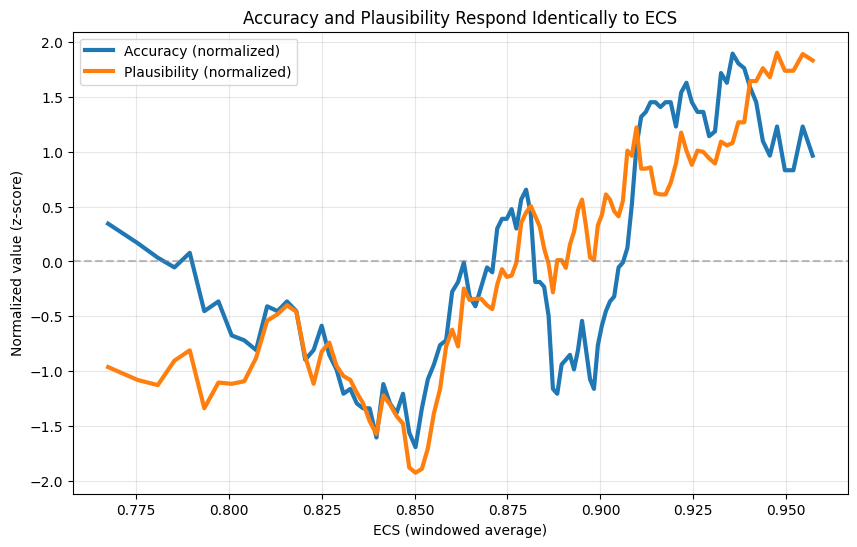

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# File paths
# -----------------------------
accuracy_path = "esnli_qwen_accuracy.csv"
plaus_file    = "esnli_qwen_plausibility_scores.csv"
ecs_file      = "qwen_esnli_rationales_with_ecs.csv"

# -----------------------------
# Load data
# -----------------------------
acc_df   = pd.read_csv(accuracy_file)[["id", "row_accuracy"]]
plaus_df = pd.read_csv(plaus_file)[["id", "Pmean"]]
ecs_df   = pd.read_csv(ecs_file)[["id", "ECS"]]

acc_df = acc_df.rename(columns={"row_accuracy": "accuracy"})

# Merge everything
df = acc_df.merge(plaus_df, on="id", how="inner") \
           .merge(ecs_df, on="id", how="inner")

# Ensure numeric + clean
for col in ["accuracy", "Pmean", "ECS"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()
df = df.sort_values("ECS").reset_index(drop=True)

print(f"Final merged dataset: {len(df)} rows")

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 100
step_size = 5

ecs_avg = []
acc_avg = []
plaus_avg = []

for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    ecs_avg.append(window["ECS"].mean())
    acc_avg.append(window["accuracy"].mean())
    plaus_avg.append(window["Pmean"].mean())

ecs_avg = np.array(ecs_avg)
acc_avg = np.array(acc_avg)
plaus_avg = np.array(plaus_avg)

# -----------------------------
# Normalize (Z-score)
# -----------------------------
def zscore(x):
    return (x - np.mean(x)) / np.std(x)

acc_norm   = zscore(acc_avg)
plaus_norm = zscore(plaus_avg)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    ecs_avg,
    acc_norm,
    label="Accuracy (normalized)",
    linewidth=3
)

plt.plot(
    ecs_avg,
    plaus_norm,
    label="Plausibility (normalized)",
    linewidth=3
)

plt.axhline(0, color="gray", linestyle="--", alpha=0.5)

plt.xlabel("ECS (windowed average)")
plt.ylabel("Normalized value (z-score)")
plt.title("Accuracy and Plausibility Respond Identically to ECS")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


In [205]:
import pandas as pd

# File paths
plaus_file = "esnli_gemini_plausibility_scores.csv"
ecs_file   = "esnli_gemini_rationales_with_ecs.csv"

# Load CSV files
plaus_df = pd.read_csv(plaus_file)
ecs_df   = pd.read_csv(ecs_file)

# Compute averages
pmean_avg = plaus_df["Pmean"].mean()
ecs_avg   = ecs_df["ECS"].mean()

# Print results
print(f"Average Pmean: {pmean_avg}")
print(f"Average ECS:   {ecs_avg}")


Average Pmean: 4.23444976076555
Average ECS:   0.7761954344850646


In [20]:
import pandas as pd

# File paths

plaus_file    = "esnli_llama_plausibility_scores.csv"
ecs_file      = "esnli_llama_rationales_with_ecs.csv"
# Load CSV files
plaus_df = pd.read_csv(plaus_file)
ecs_df   = pd.read_csv(ecs_file)

# Compute averages
pmean_avg = plaus_df["Pmean"].mean()
ecs_avg   = ecs_df["ECS"].mean()

# Print results
print(f"Average Pmean: {pmean_avg}")
print(f"Average ECS:   {ecs_avg}")


Average Pmean: 3.543859649122807
Average ECS:   0.8271333962750207


In [22]:
import pandas as pd

# File paths

plaus_file    = "esnli_mistral_plausibility_scores.csv"
ecs_file      = "esnli_mistral_rationales_with_ecs.csv"
# Load CSV files
plaus_df = pd.read_csv(plaus_file)
ecs_df   = pd.read_csv(ecs_file)

# Compute averages
pmean_avg = plaus_df["Pmean"].mean()
ecs_avg   = ecs_df["ECS"].mean()

# Print results
print(f"Average Pmean: {pmean_avg}")
print(f"Average ECS:   {ecs_avg}")

Average Pmean: 3.6191813804173356
Average ECS:   0.8110742886406717


In [24]:
import pandas as pd

# File paths

plaus_file    = "esnli_qwen_plausibility_scores.csv"
ecs_file      = "qwen_esnli_rationales_with_ecs.csv"
# Load CSV files
plaus_df = pd.read_csv(plaus_file)
ecs_df   = pd.read_csv(ecs_file)

# Compute averages
pmean_avg = plaus_df["Pmean"].mean()
ecs_avg   = ecs_df["ECS"].mean()

# Print results
print(f"Average Pmean: {pmean_avg}")
print(f"Average ECS:   {ecs_avg}")

Average Pmean: 4.285087719298246
Average ECS:   0.8745281920114267


**plausibility on gsm8k**

In [ ]:
import os
import pandas as pd
from vertexai.generative_models import GenerativeModel
import vertexai
import time
import csv
from tqdm import tqdm
import re


# ---------------------------
# 1. GOOGLE AUTHENTICATION 
# ---------------------------
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"
assert os.path.exists(SERVICE_ACCOUNT_PATH), f"❌ JSON file not found: {SERVICE_ACCOUNT_PATH}"
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH
print("✅ Google service account loaded.")


# ---------------------------
# 2. INITIALIZE GEMINI
# ---------------------------
vertexai.init(project="llm-reasoning-475315", location="us-central1")
model = GenerativeModel("gemini-2.5-flash")
print("✅ Gemini model initialized.")


# ---------------------------
# 3. LOAD DATA
# ---------------------------
rationales_df = pd.read_csv("esnli_gemini_rationales_filtered_cleaned.csv")
perturb_df = pd.read_csv("esnli_800_with_perturbations.csv")

# Keep only rows where we have rationales
perturb_df = perturb_df[perturb_df["id"].isin(rationales_df["id"])]

# Merge both datasets
merged = pd.merge(rationales_df, perturb_df, on="id", how="inner")
print("📌 Final merged dataset:", merged.shape)


# ---------------------------
# 4. PROMPT TEMPLATE
# ---------------------------
JUDGE_PROMPT = """

You are an expert evaluator of Natural Language Inference (NLI) explanations.

Your task is to judge the **plausibility and correctness of the MODEL RATIONALE** 
given the PREMISE, HYPOTHESIS, and the GOLD LABEL.

A plausible rationale is one that:
1. Uses ONLY information from the Premise (no external facts or assumptions).
2. Correctly explains why the GOLD LABEL logically follows.
3. Contains no contradictions, logical fallacies, or hallucinated details.
4. Is relevant and sufficient for justifying the label.

Ignore:
- writing style
- length
- verbosity
- grammar
These should NOT affect the score.

### SCORING RUBRIC (1–5):
5 = Excellent  
    - Fully correct reasoning.
    - Uses only premise information.
    - Explicitly supports the gold label with valid logical steps.

4 = Good  
    - Mostly correct and grounded.
    - Minor missing detail OR slight redundancy, but the justification is sound.

3 = Weak but Acceptable  
    - Partially correct reasoning.
    - Some vagueness OR a small incorrect assumption, but it still roughly supports the label.

2 = Flawed  
    - Significant logical gaps OR an incorrect justification.
    - Uses irrelevant or unsupported claims.
    - Does NOT adequately justify the gold label.

1 = Incorrect / Implausible  
    - Wrong reasoning OR contradicts the label.
    - Hallucinates facts not present in the premise.
    - Explanation is logically invalid.

### INPUT:
Premise: {premise}
Hypothesis: {hypothesis}
Gold Label: {label}
Model Rationale: {rationale}

### OUTPUT:
Output ONLY the integer score (1–5).

"""


# ---------------------------
# 5. SCORING FUNCTION (FIXED)
# ---------------------------
def score_rationale(premise, hypothesis, label, rationale):
    """Send one rationale to Gemini and extract plausibility score."""
    prompt = JUDGE_PROMPT.format(
        premise=premise,
        hypothesis=hypothesis,
        label=label,
        rationale=rationale
    )

    try:
        resp = model.generate_content(prompt)
        text = resp.text.strip()

        # Regex to extract 1..5 safely
        match = re.search(r"\b([1-5])\b", text)
        if match:
            return int(match.group(1))

        return None

    except Exception as e:
        tqdm.write(f"❌ Error for example: {e}")
        return None


# ---------------------------
# 6. PREPARE OUTPUT CSV
# ---------------------------
output_path = "esnli_gemini_plausibility_scores.csv"
write_header = not os.path.exists(output_path)

with open(output_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    # Write header if file doesn't exist
    if write_header:
        writer.writerow([
            "id",
            "plaus_original",
            "plaus_pert1",
            "plaus_pert2",
            "plaus_pert3"
        ])
        print("📝 Created new output file with header.")


    # ---------------------------
    # 7. tqdm SCORING LOOP
    # ---------------------------
    for idx, row in tqdm(merged.iterrows(), total=len(merged), desc="Scoring Rationales"):

        ex_id = row["id"]
        premise = row["Premise"]
        gold_label = row["gold_label"]  # correct gold label column

        # Hypotheses
        hyp_orig  = row["Hypothesis"]
        hyp_pert1 = row["perturbation_1_lexical"]
        hyp_pert2 = row["perturbation_2_syntactic"]
        hyp_pert3 = row["perturbation_3_pragmatic"]

        # Rationales
        rat_orig  = row["rationale_original_cleaned"]
        rat_pert1 = row["rationale_pert1_cleaned"]
        rat_pert2 = row["rationale_pert2_cleaned"]
        rat_pert3 = row["rationale_pert3_cleaned"]

        # Score each rationale (now robust)
        s0 = score_rationale(premise, hyp_orig,  gold_label, rat_orig)
        s1 = score_rationale(premise, hyp_pert1, gold_label, rat_pert1)
        s2 = score_rationale(premise, hyp_pert2, gold_label, rat_pert2)
        s3 = score_rationale(premise, hyp_pert3, gold_label, rat_pert3)

        # Save immediately
        writer.writerow([ex_id, s0, s1, s2, s3])

        # Optional rate limit protection
        time.sleep(0.25)

print("🎉 DONE! All plausibility scores saved row-by-row.")


**new ratings** 

In [10]:
import os
import json
import time
import re
import pandas as pd
from tqdm import tqdm

import vertexai
from vertexai.generative_models import GenerativeModel, GenerationConfig

# ---------------------------
# 1. GOOGLE AUTHENTICATION
# ---------------------------
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"

if not os.path.exists(SERVICE_ACCOUNT_PATH):
    if "GOOGLE_APPLICATION_CREDENTIALS" not in os.environ:
        raise FileNotFoundError(f"❌ JSON file not found: {SERVICE_ACCOUNT_PATH}")
else:
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH
    print("✅ Google service account loaded.")

# ---------------------------
# 2. INITIALIZE GEMINI
# ---------------------------
vertexai.init(project="llm-reasoning-475315", location="us-central1")
model = GenerativeModel("gemini-2.0-flash") 
print("✅ Gemini model initialized.")

# ---------------------------
# 3. INPUT / OUTPUT
# ---------------------------
INPUT_CSV = "gsm8k/gsm8k_llama3_CoT_responses_filtered_no_final.csv"
OUTPUT_CSV = "gsm8k/gsm8k_llama3_CoT_plausibility_scores_only.csv" # Changed filename to reflect cleaner output
BAD_OUTPUT_LOG = "gsm8k/gemini_bad_outputs.log"

COT_COLS = ["cot_original", "cot_lexical", "cot_syntactic", "cot_contextual"]

# ---------------------------
# 4. RUBRIC + PROMPTS
# ---------------------------
RUBRIC = """
You are judging the *plausibility* of a GSM8K-style solution rationale (chain-of-thought).
The final answer may be missing. DO NOT grade based on getting the right final number.
Grade whether the reasoning steps are coherent, consistent, and mathematically appropriate.

Key criteria:
1) Problem-faithful setup: uses only given quantities/relationships; no invented facts.
2) Logical flow: each step follows from the previous; no leaps or non sequiturs.
3) Math validity: operations match the story; arithmetic/algebra is consistent.
4) Internal consistency: quantities keep the same meaning; no contradictions/double-counting.
5) Solution sufficiency: steps meaningfully progress toward the asked quantity.

Refined Scoring Rubric (1–5):
- 5: Clear, faithful setup; coherent; math fits; consistent; no invented facts.
- 4: Mostly coherent; minor ambiguity or small/local arithmetic slip; no major invention.
- 3: Notable gap or questionable step; repairable with moderate edits.
- 2: Major logical flaw or unsupported assumptions; low chance of correct solution.
- 1: Incoherent/irrelevant/minimal effort.

Return STRICT JSON only (no markdown) with exactly:
{
  "score": <integer 1..5>
}
"""

# Double curly braces {{ }} for JSON so .format() doesn't break
SHORT_PROMPT = """
Return STRICT JSON only with exactly:
{{
  "score": <integer 1..5>
}}
No other text.
Rationale:
\"\"\"{rationale}\"\"\"
"""

# ---------------------------
# 5. RESPONSE TEXT ASSEMBLY
# ---------------------------
def get_full_text_from_response(resp) -> str:
    try:
        t = resp.text
        if isinstance(t, str) and t.strip():
            candidate_text = t
        else:
            candidate_text = ""
    except Exception:
        candidate_text = ""

    try:
        if hasattr(resp, "candidates") and resp.candidates:
            parts = resp.candidates[0].content.parts
            joined = "".join([getattr(p, "text", "") for p in parts if getattr(p, "text", None) is not None])
            if joined.strip():
                return joined
    except Exception:
        pass

    return candidate_text

def strip_code_fences(text: str) -> str:
    text = str(text).strip()
    text = re.sub(r"^```(?:json)?\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s*```$", "", text)
    return text.strip()

def extract_json_object(text: str) -> dict:
    t = strip_code_fences(text)
    try:
        return json.loads(t)
    except Exception:
        pass
    
    start = t.find("{")
    end = t.rfind("}")
    if start != -1 and end != -1 and end > start:
        try:
            return json.loads(t[start:end+1])
        except Exception:
            pass

    raise ValueError("No complete JSON object found.")

def log_bad_output(row_id, cot_col, raw_text, err, finish_reason=None):
    os.makedirs(os.path.dirname(BAD_OUTPUT_LOG), exist_ok=True)
    with open(BAD_OUTPUT_LOG, "a", encoding="utf-8") as f:
        f.write("\n" + "="*80 + "\n")
        f.write(f"id={row_id} col={cot_col}\n")
        f.write(f"error={repr(err)}\n")
        if finish_reason is not None:
            f.write(f"finish_reason={finish_reason}\n")
        f.write("RAW OUTPUT:\n")
        f.write(raw_text if raw_text is not None else "None")
        f.write("\n")

def looks_incomplete_json(text: str) -> bool:
    t = strip_code_fences(text)
    return t.startswith("{") and ("}" not in t)

# ---------------------------
# 6. GRADER
# ---------------------------
def generate_text(prompt: str, gen_config: GenerationConfig, stream: bool) -> tuple[str, str]:
    if not stream:
        resp = model.generate_content(prompt, generation_config=gen_config)
        txt = get_full_text_from_response(resp)
        finish_reason = None
        try:
            if resp.candidates:
                finish_reason = str(resp.candidates[0].finish_reason)
        except Exception:
            finish_reason = None
        return txt, finish_reason

    chunks = []
    finish_reason = None
    resp_stream = model.generate_content(prompt, generation_config=gen_config, stream=True)
    for chunk in resp_stream:
        try:
            chunks.append(chunk.text)
        except Exception:
            pass
        try:
            if chunk.candidates:
                finish_reason = str(chunk.candidates[0].finish_reason)
        except Exception:
            pass
    return "".join(chunks), finish_reason

def grade_rationale(rationale_text: str, row_id=None, cot_col=None,
                    max_retries: int = 8, debug_print: bool = True):
    if rationale_text is None or (isinstance(rationale_text, float) and pd.isna(rationale_text)):
        return None  # Return None for score if rationale missing

    rationale_text = str(rationale_text).strip()
    if not rationale_text:
        return None

    gen_config = GenerationConfig(
        temperature=0.0,
        top_p=1.0,
        max_output_tokens=1024, 
    )

    prompt = f"""{RUBRIC}

Rationale to grade:
\"\"\"{rationale_text}\"\"\"
"""

    last_err = None
    for attempt in range(max_retries):
        try:
            use_stream = (attempt >= 1)
            raw, finish_reason = generate_text(prompt, gen_config, stream=use_stream)

            if looks_incomplete_json(raw):
                raise ValueError(f"Incomplete JSON. finish_reason={finish_reason}")

            data = extract_json_object(raw)
            score = int(data["score"])
            
            if score < 1 or score > 5:
                raise ValueError(f"Score out of range: {score}")

            # Return ONLY the score now
            return score

        except Exception as e:
            last_err = e
            try:
                raw_to_log = raw
            except Exception:
                raw_to_log = None
            log_bad_output(row_id, cot_col, raw_to_log, e, finish_reason=locals().get("finish_reason"))

            if debug_print and attempt in (0, 1):
                excerpt = strip_code_fences(raw_to_log)[:400].replace("\n", "\\n") if raw_to_log else ""
                print(f"\n⚠️ Failure (id={row_id}, col={cot_col}, attempt={attempt+1}): {e}\nExcerpt: {excerpt}\n")

            try:
                prompt = SHORT_PROMPT.format(rationale=rationale_text)
            except Exception as format_err:
                print(f"CRITICAL FORMAT ERROR: {format_err}")
                raise format_err

            time.sleep(0.6 * (2 ** min(attempt, 4)))

    raise RuntimeError(f"Failed after retries. Last error: {last_err}")

# ---------------------------
# 7. LOAD + NORMALIZE COLUMNS
# ---------------------------
df = pd.read_csv(INPUT_CSV)

if "cot_syntaxtic" in df.columns and "cot_syntactic" not in df.columns:
    df = df.rename(columns={"cot_syntaxtic": "cot_syntactic"})
    print("✅ Renamed column cot_syntaxtic -> cot_syntactic")

required = ["id"] + COT_COLS
missing = [c for c in required if c not in df.columns]
assert not missing, f"❌ Missing required columns: {missing}"
print(f"✅ Loaded {len(df)} rows from {INPUT_CSV}")

# ---------------------------
# 8. GRADE + AGGREGATE
# ---------------------------
score_cols = {
    "cot_original": "plausibility_original",
    "cot_lexical": "plausibility_lexical",
    "cot_syntactic": "plausibility_syntactic",
    "cot_contextual": "plausibility_contextual",
}

# Initialize score columns only
for col in score_cols.values():
    if col not in df.columns:
        df[col] = None

# Main Loop
for i in tqdm(range(len(df)), desc="Grading rationales"):
    row_id = df.at[i, "id"]
    for cot_col in COT_COLS:
        score_col = score_cols[cot_col]
        
        if pd.notna(df.at[i, score_col]):
            continue

        score = grade_rationale(df.at[i, cot_col], row_id=row_id, cot_col=cot_col)

        # Assign ONLY the score
        df.at[i, score_col] = score

        time.sleep(0.10)
    
    # Save checkpoint every 20 rows
    if i % 20 == 0:
        df.to_csv(OUTPUT_CSV, index=False)

# Convert to numeric
for col in score_cols.values():
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Calculate Mean Plausibility (Row-wise)
df["mean_plausibility"] = df[list(score_cols.values())].mean(axis=1, skipna=True)

# ---------------------------
# 9. FINAL SAVE
# ---------------------------
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
df.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Saved results to: {OUTPUT_CSV}")
print(f"📝 Bad outputs logged to: {BAD_OUTPUT_LOG}")

/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


✅ Google service account loaded.
✅ Gemini model initialized.
✅ Loaded 366 rows from gsm8k/gsm8k_llama3_CoT_responses_filtered_no_final.csv


Grading rationales: 100%|█████████████████████| 366/366 [20:24<00:00,  3.35s/it]

✅ Saved results to: gsm8k/gsm8k_llama3_CoT_plausibility_scores_only.csv
📝 Bad outputs logged to: gsm8k/gemini_bad_outputs.log


**gsm8k llama3 plausibility**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# File paths
# -----------------------------
accuracy_path = "esnli_qwen_accuracy.csv"
plaus_file    = "esnli_qwen_plausibility_scores.csv"
ecs_file      = "gsm8k/gsm8k_llama3_with_ECS"

# -----------------------------
# Load data
# -----------------------------
acc_df   = pd.read_csv(accuracy_file)[["id", "row_accuracy"]]
plaus_df = pd.read_csv(plaus_file)[["id", "Pmean"]]
ecs_df   = pd.read_csv(ecs_file)[["id", "ECS"]]

acc_df = acc_df.rename(columns={"row_accuracy": "accuracy"})

# Merge everything
df = acc_df.merge(plaus_df, on="id", how="inner") \
           .merge(ecs_df, on="id", how="inner")

# Ensure numeric + clean
for col in ["accuracy", "Pmean", "ECS"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()
df = df.sort_values("ECS").reset_index(drop=True)

print(f"Final merged dataset: {len(df)} rows")

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 100
step_size = 5

ecs_avg = []
acc_avg = []
plaus_avg = []

for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    ecs_avg.append(window["ECS"].mean())
    acc_avg.append(window["accuracy"].mean())
    plaus_avg.append(window["Pmean"].mean())

ecs_avg = np.array(ecs_avg)
acc_avg = np.array(acc_avg)
plaus_avg = np.array(plaus_avg)

# -----------------------------
# Normalize (Z-score)
# -----------------------------
def zscore(x):
    return (x - np.mean(x)) / np.std(x)

acc_norm   = zscore(acc_avg)
plaus_norm = zscore(plaus_avg)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    ecs_avg,
    acc_norm,
    label="Accuracy (normalized)",
    linewidth=3
)

plt.plot(
    ecs_avg,
    plaus_norm,
    label="Plausibility (normalized)",
    linewidth=3
)

plt.axhline(0, color="gray", linestyle="--", alpha=0.5)

plt.xlabel("ECS (windowed average)")
plt.ylabel("Normalized value (z-score)")
plt.title("Accuracy and Plausibility Respond Identically to ECS")
plt.legend()
plt.grid(alpha=0.3)

plt.show()
